In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt 
plt.rcParams["font.family"] = "Arial"  # Set global font to Arial

### fit with percentage, with fixed A/B but unfixed A + B

In [2]:
from scipy.optimize import curve_fit

def adsorption_ratio2(x, f, k):
    """
    Model:  (f * k * x) / (1 + (1-f)* k * x)

    Parameters
    ----------
    x : array‑like
        Independent variable (e.g., R_sol or concentration).
    f, k : float
        Fit parameters:
        f – fraction of accessible sites (dimensionless)
        k – equilibrium constant

    Returns
    -------
    y : ndarray
        Model prediction at each x.
    """
    x = np.asarray(x, dtype=float)
    return (f * k * x) / (1 + (1-f)* k * x)
 
def fit_adsorption_ratio2(xdata, ydata, p0=(0.5, 1.0)):
    """
    Returns
    -------
    popt : ndarray  -- best‑fit [A, B, k]
    pcov : ndarray  -- parameter covariance matrix
    """
    x = np.asarray(xdata, dtype=float)
    y = np.asarray(ydata, dtype=float)

    # keep only finite pairs
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        raise ValueError("Not enough finite points to perform the fit.")

    popt, pcov = curve_fit(
        adsorption_ratio2,
        x[mask],
        y[mask],
        p0=p0,
        maxfev=5000
    )
    return popt, pcov


In [3]:
df = pd.read_csv("MOL_surface_adsorption_250427.csv", delimiter = ',')
unique_acid = df["Acid"].unique()

TFA
TFA


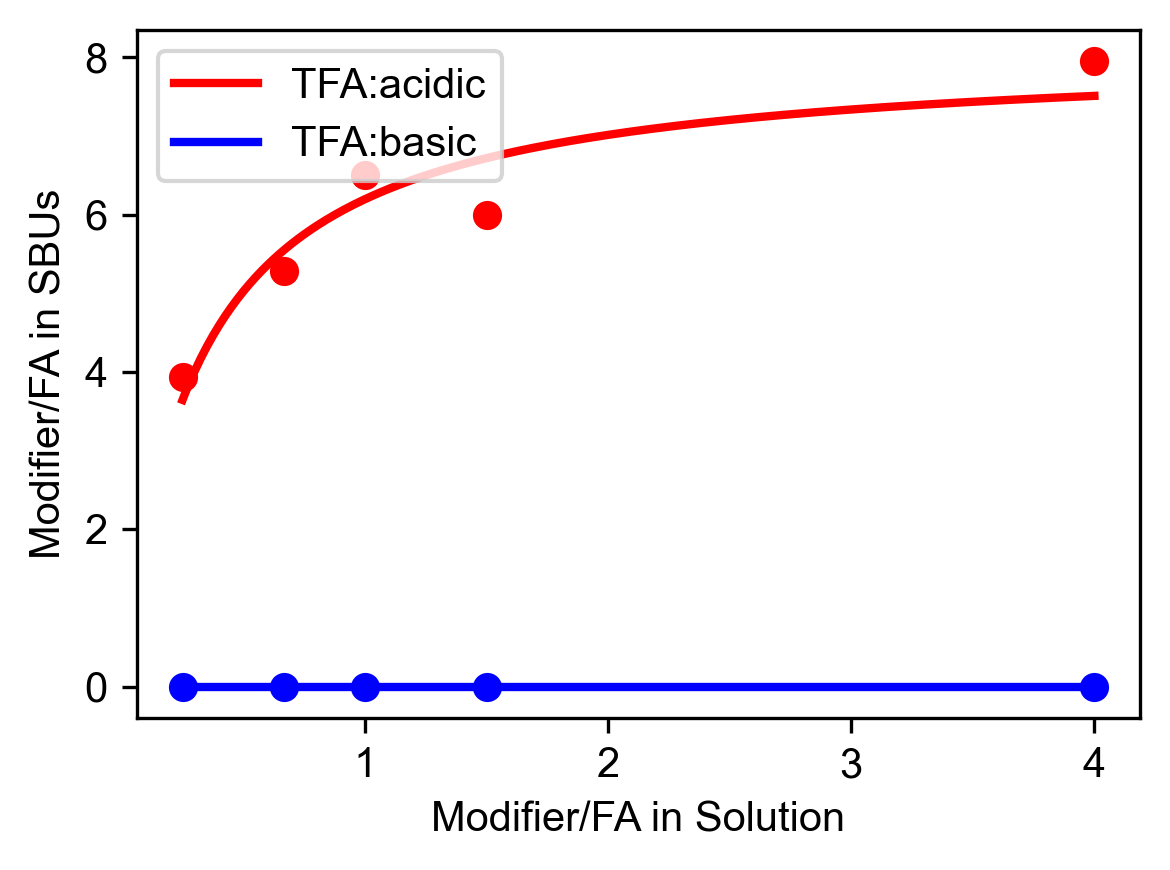

TA
TA


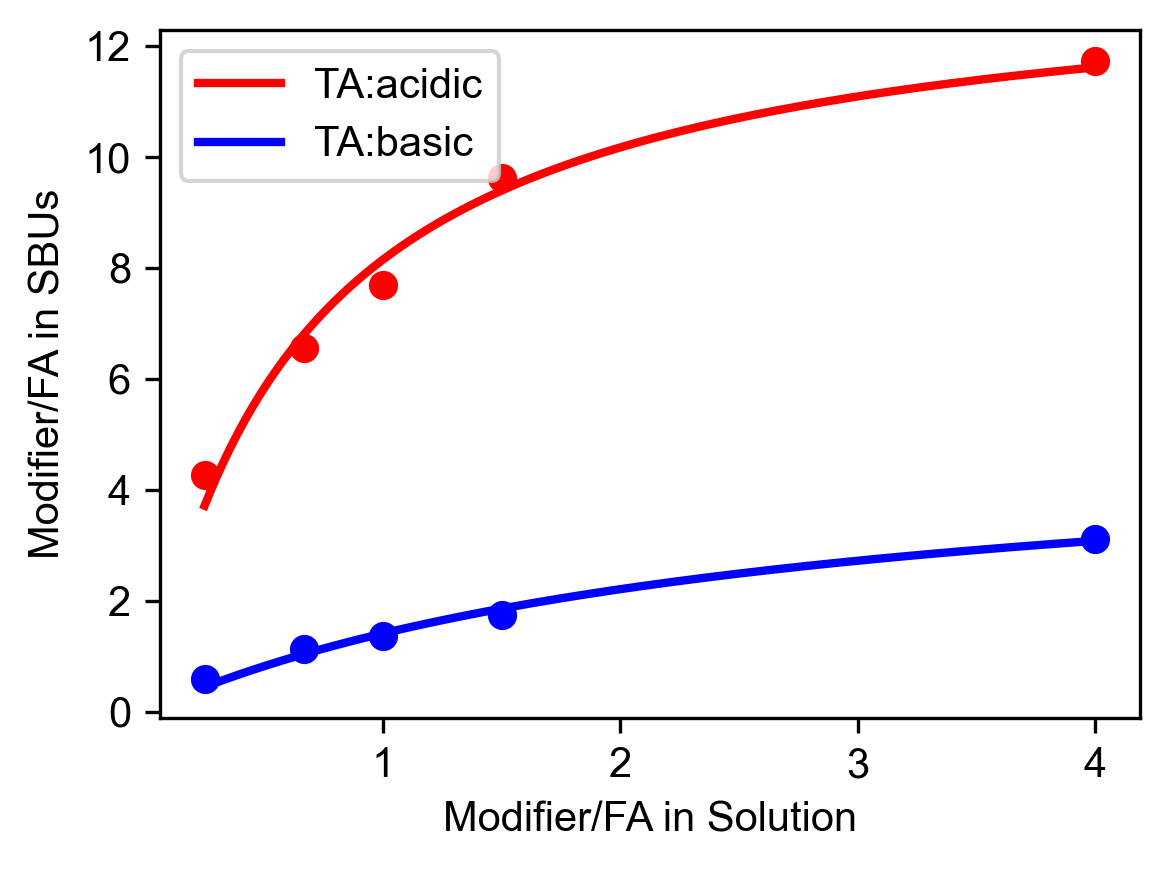

SA
SA


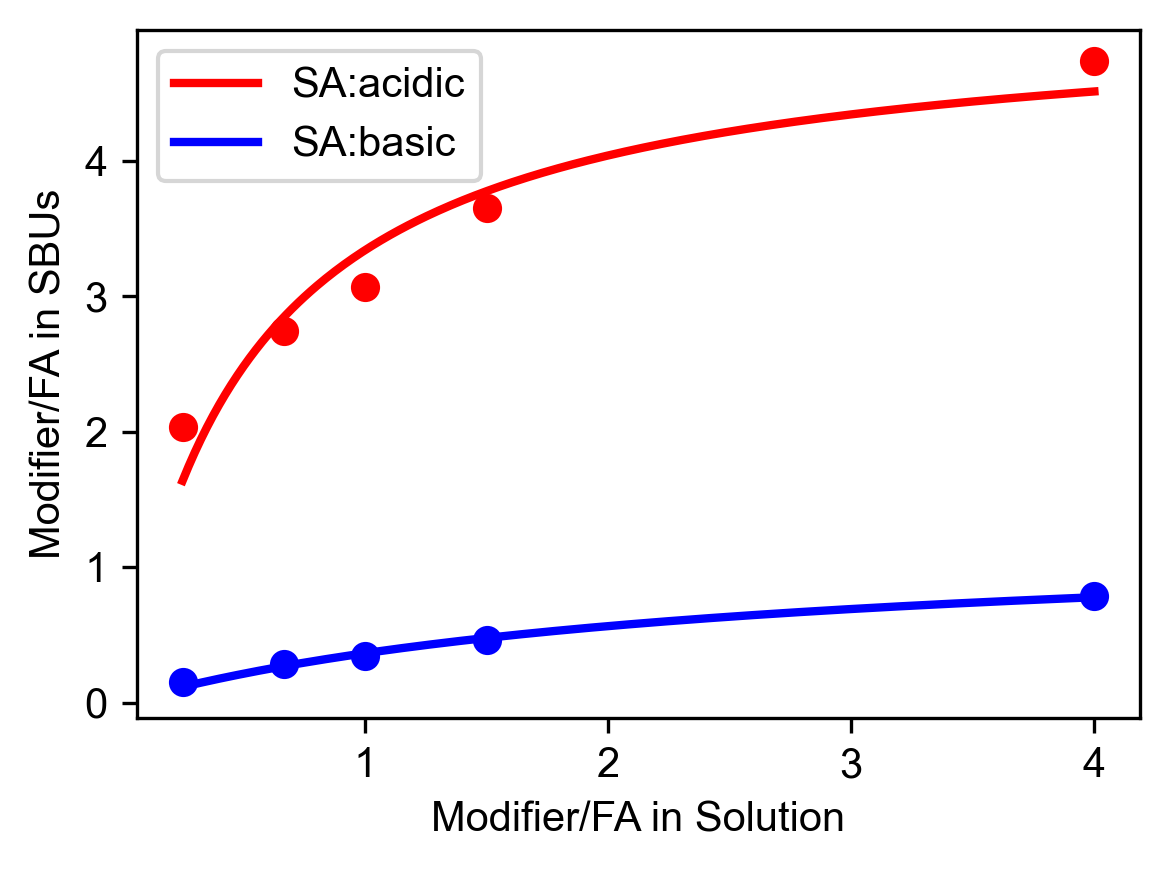

PA


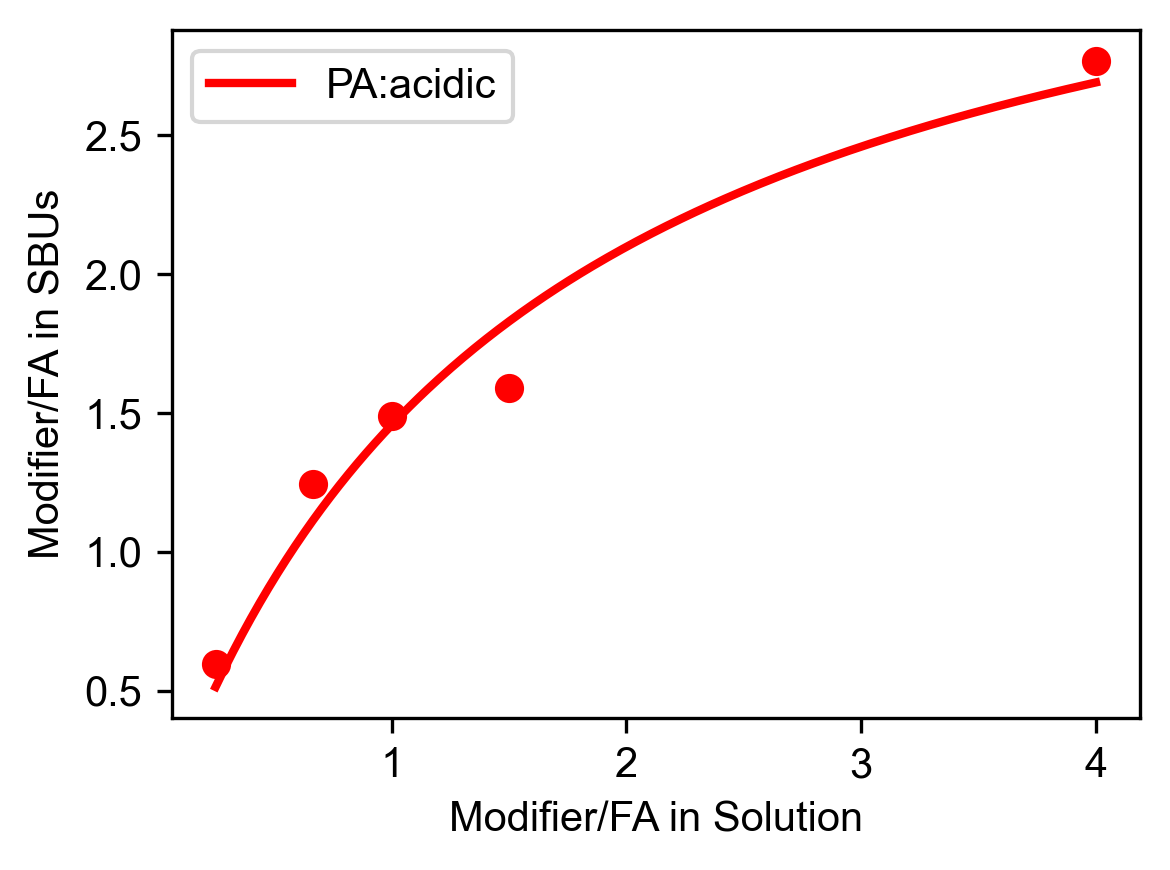

NFA
NFA


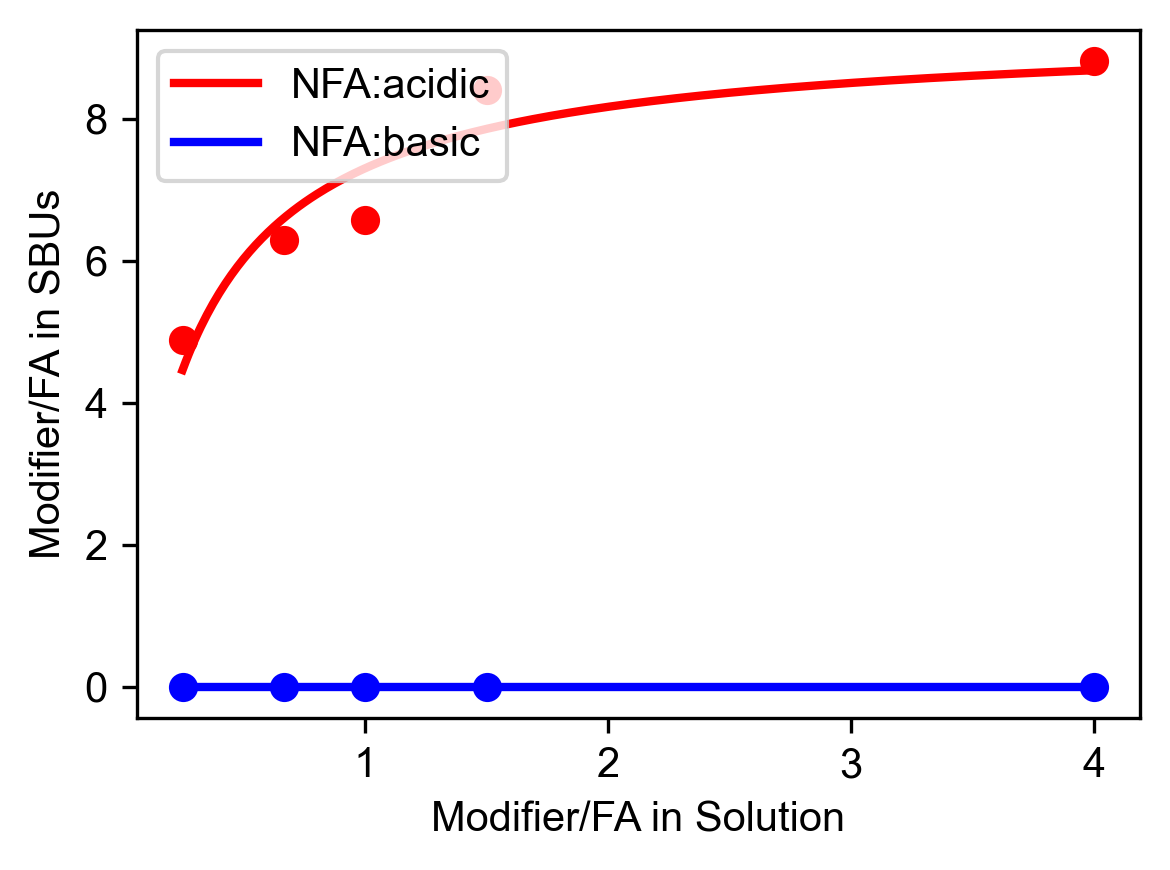

MA
MA


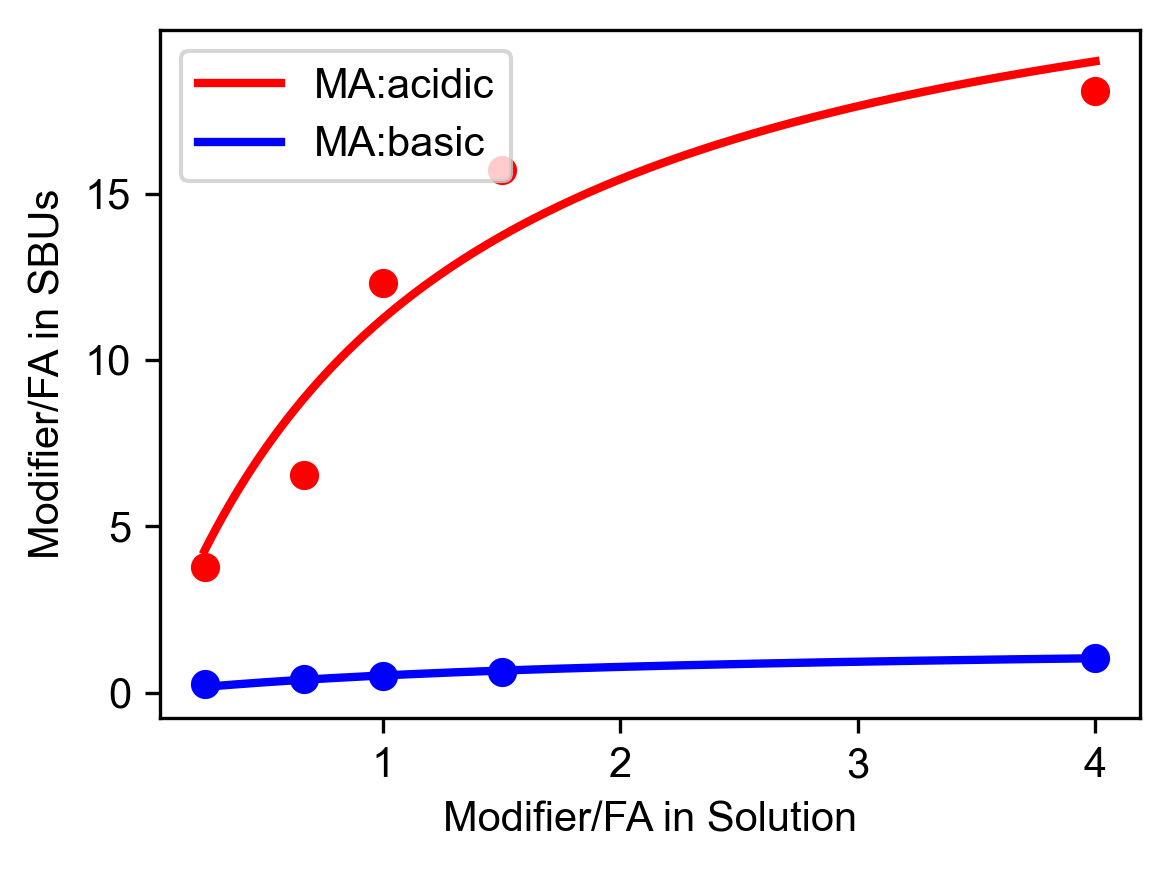

HPA
HPA


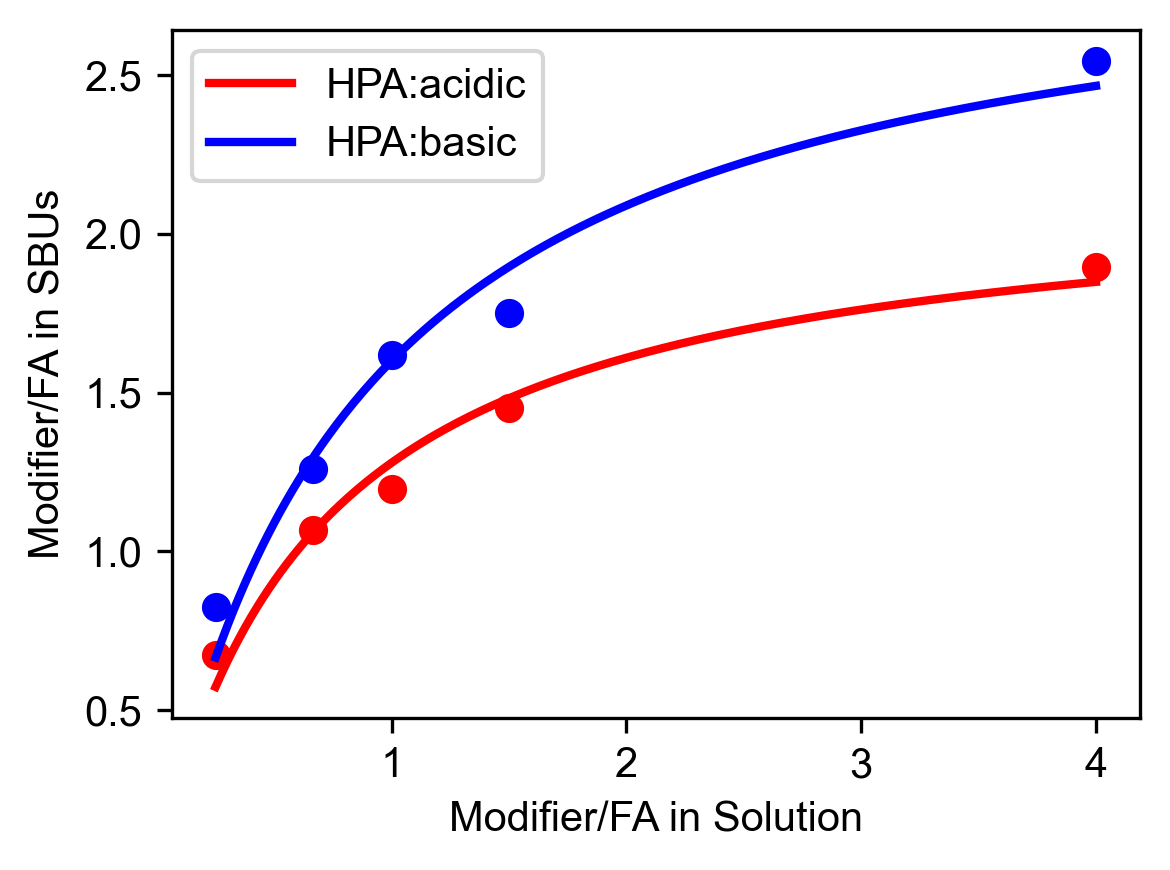

HAc
HAc


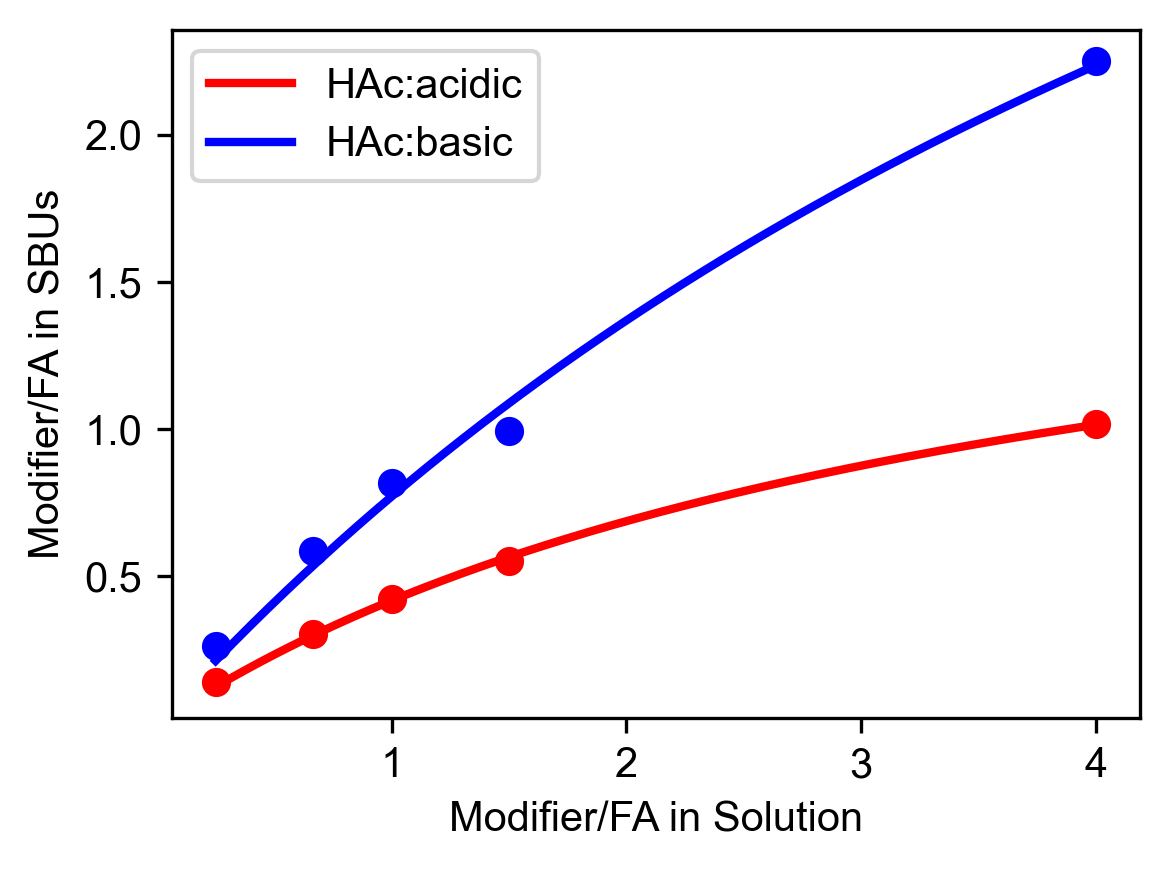

GA
GA


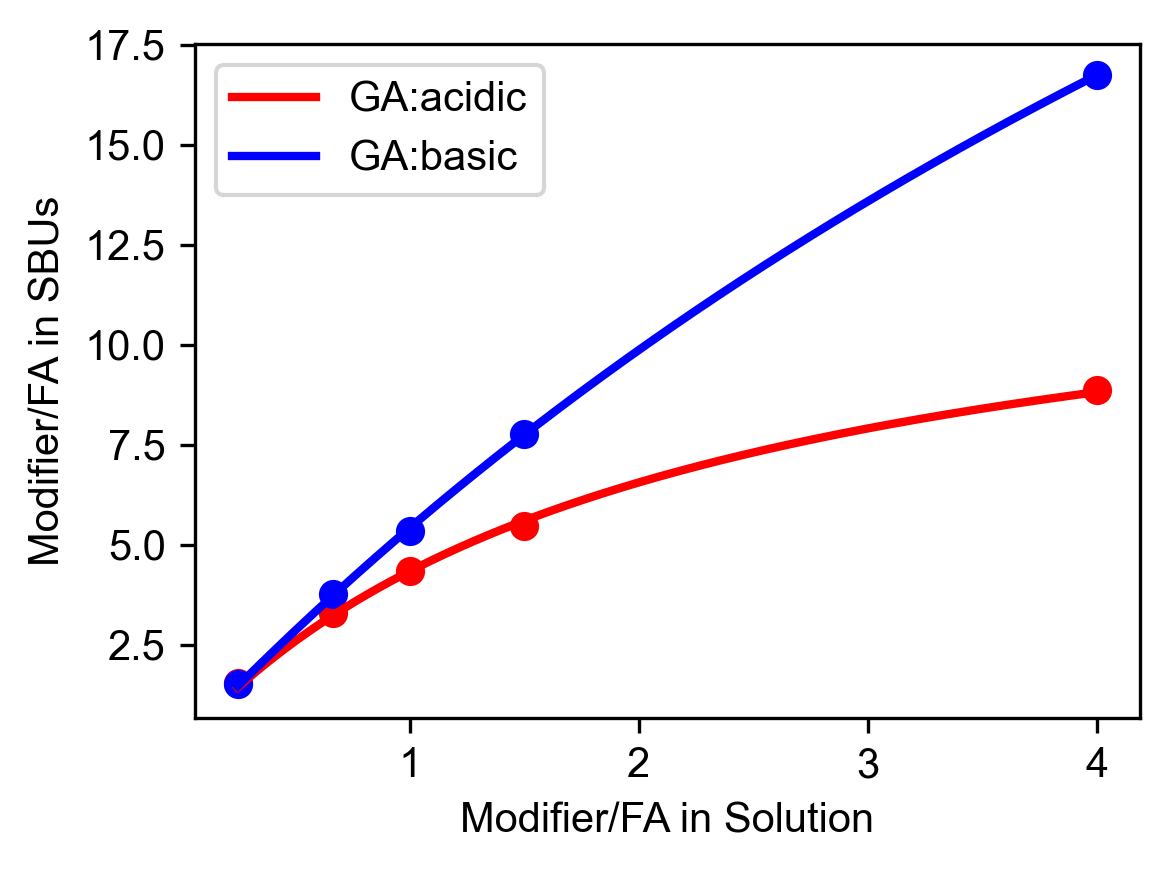

Boc-P
Boc-P


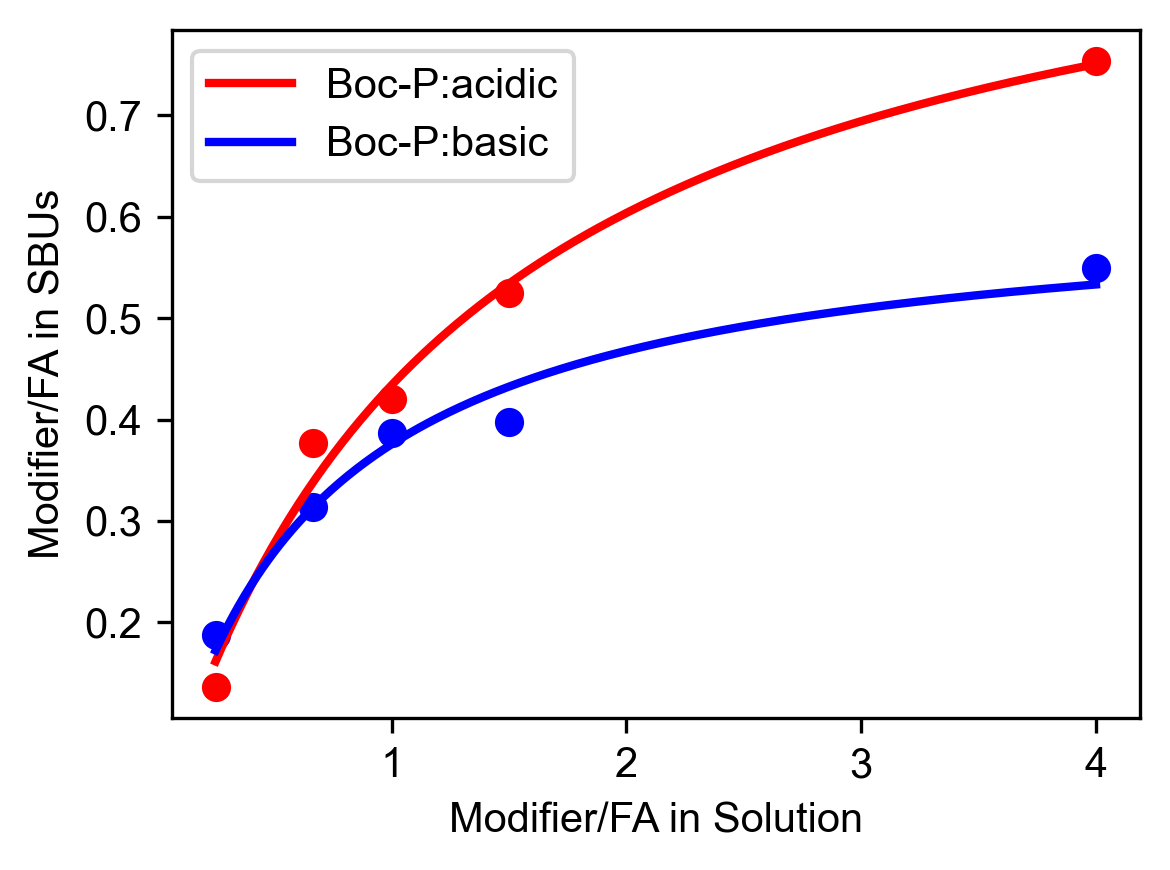

BA
BA


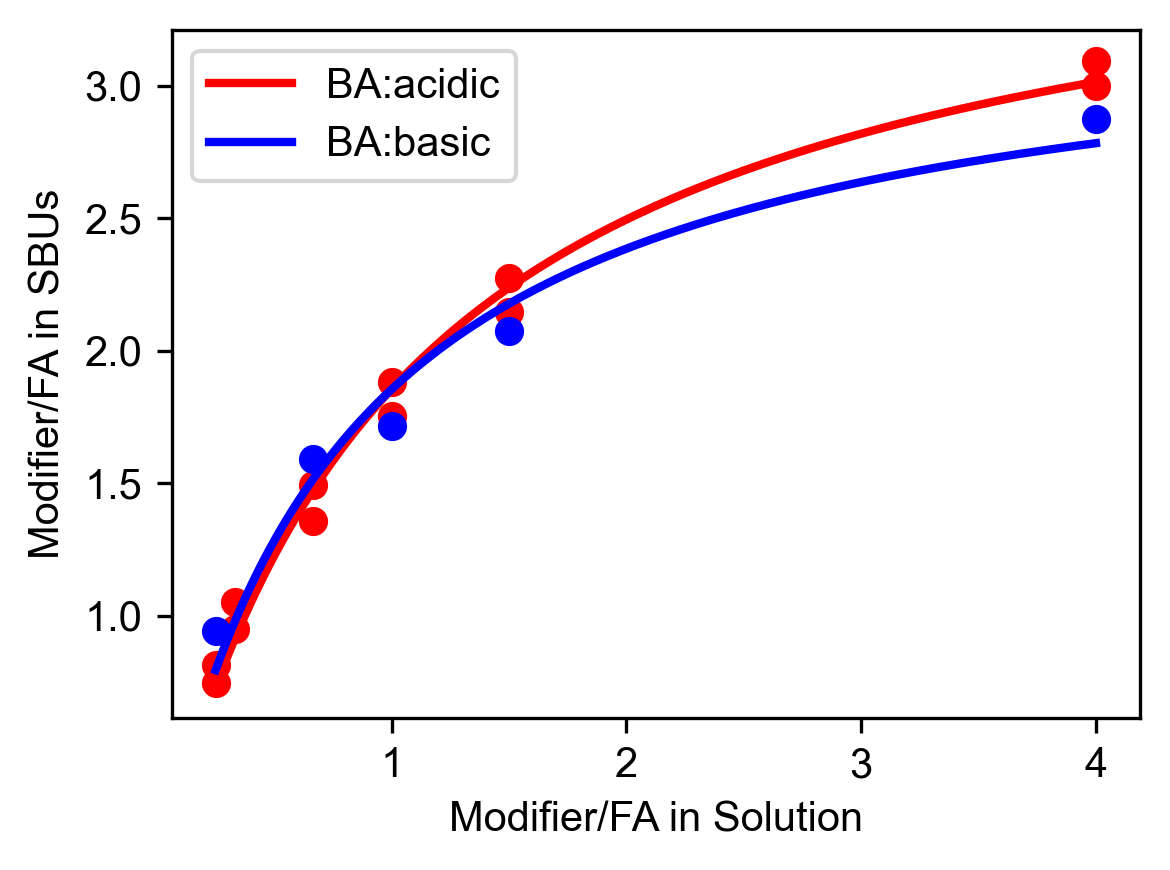

FBA
FBA


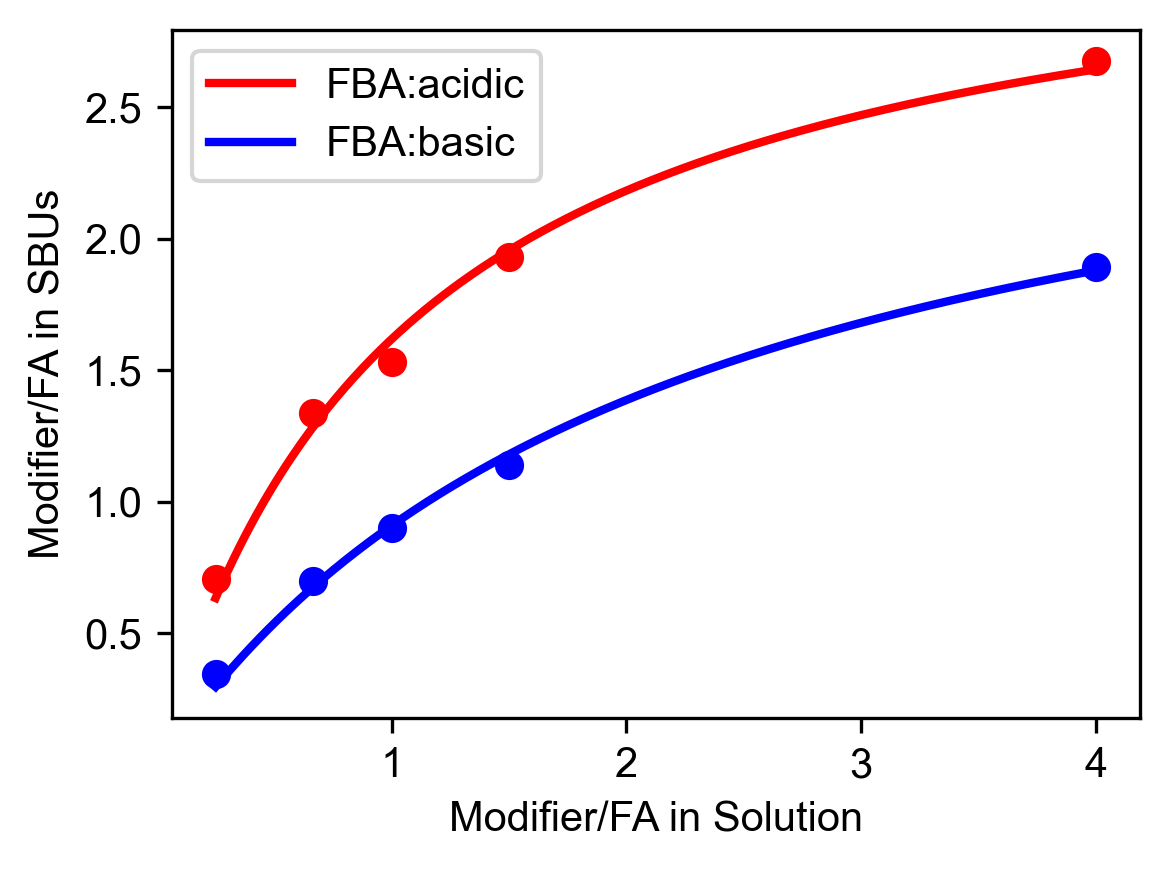

CA
CA


C:\Users\yibinjiang\AppData\Local\Temp\ipykernel_13844\2608818056.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


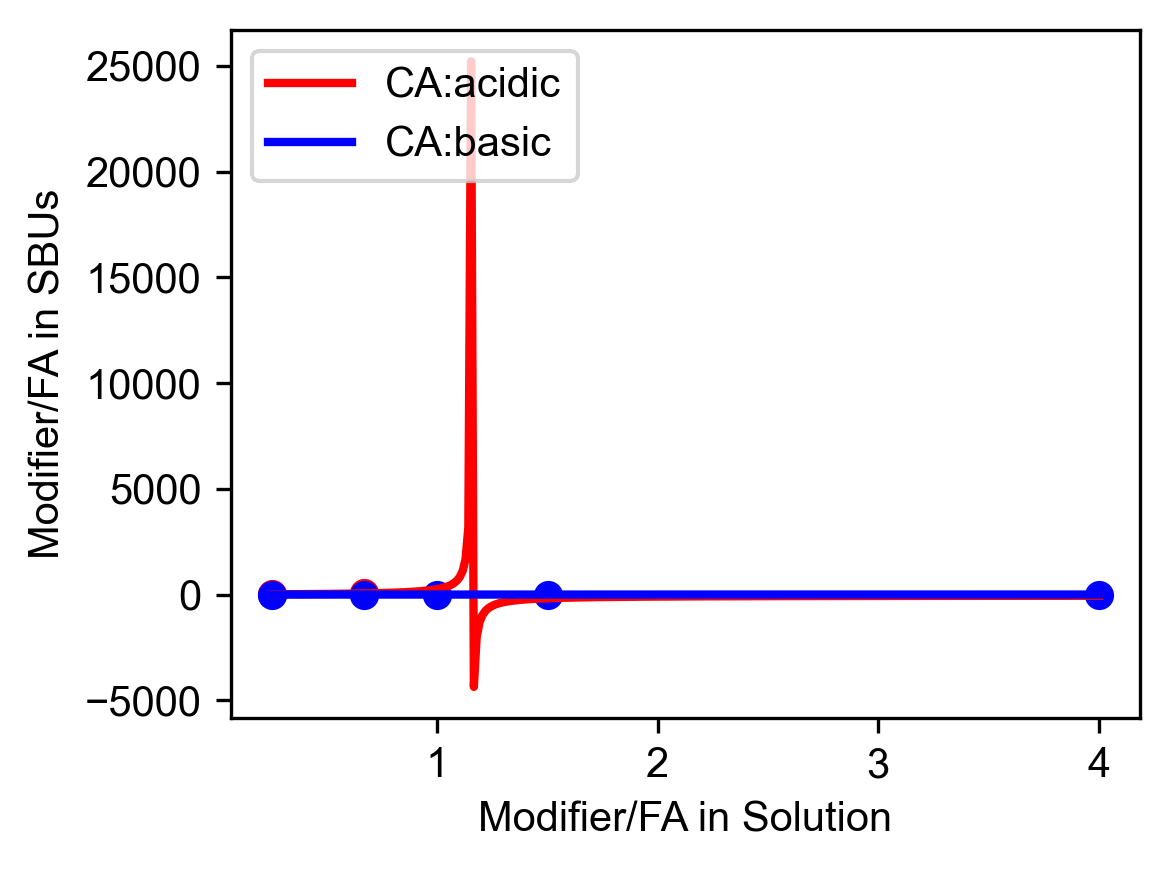

BMH


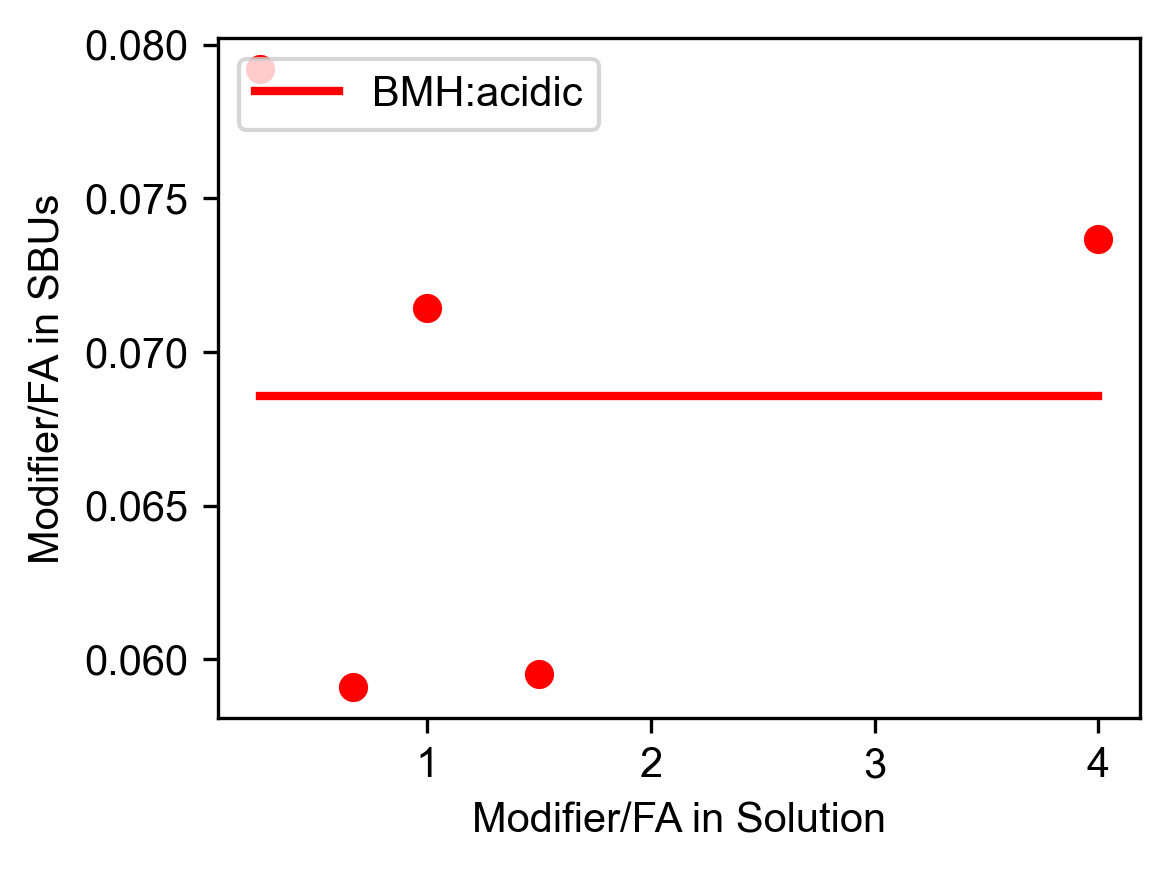

In [4]:
summary = []
color = ["red", "blue"]

for acid_temp in unique_acid:
    df_by_acid = df.loc[df["Acid"] == acid_temp]
    
    plt.rcParams['font.family'] = 'Arial'
    fig, ax = plt.subplots(figsize=(4, 3), dpi = 300)

    count = 0 
    for experiment_type in df_by_acid["Experiment"].unique():
        
        try:
            print(acid_temp)
            this_curve = df_by_acid.loc[df_by_acid["Experiment"] == experiment_type]
            
            x = this_curve["Acid conc (mM)"]/this_curve["FA conc (mM)"]
            y = this_curve["acid/SBU"]/this_curve["FA/SBU"]

            popt = fit_adsorption_ratio2(x.values,y.values)[0]
            A = (this_curve["acid/SBU"] + this_curve["FA/SBU"])*popt[0]
            B = (this_curve["acid/SBU"] + this_curve["FA/SBU"])*(1 - popt[0])
            
            # Generate smooth curve for plotting
            x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 300)
            y_fit = adsorption_ratio2(x_fit, *popt)

            summary.append({
                "Acid": acid_temp,
                "Experiment": experiment_type,
                "A": np.around(A.values, 2),
                "mean_A": np.around(A.values.mean(), 2),
                "std_A": np.around(A.values.std(), 2),
                
                "B": np.around(B.values, 2),
                "mean_B": np.around(B.values.mean(), 2),
                "std_B": np.around(B.values.std(), 2),
                
                "percentage": popt[0], #f: fraction of accessible sites
                "k": popt[1] #k: equilibrium constant
            })


            # -----------------------------
            # 4.  Plot
            # -----------------------------
            ax.plot(x_fit, y_fit, linewidth=2, label= acid_temp + ":" + experiment_type, c = color[count])
            ax.scatter(x, y, c = color[count])
            ax.set_xlabel(f'Modifier/FA in Solution')
            ax.set_ylabel(f'Modifier/FA in SBUs')
            ax.legend(loc='upper left')
            count = count + 1 
        except:
            print(acid_temp, experiment_type)
            count = count + 1
            
    plt.tight_layout()
    plt.show()
summary1 = pd.DataFrame(summary)

In [5]:
display(summary1)

,Acid,Experiment,A,mean_A,std_A,B,mean_B,std_B,percentage,k
0,TFA,acidic,"[3.03, 2.99, 2.94, 3.13, 3.08]",3.03,0.07,"[0.37, 0.37, 0.36, 0.39, 0.38]",0.38,0.01,8.898450e-01,2.986677e+01
1,TFA,basic,"[0.0, 0.0, 0.0, 0.0, 0.0]",0.00,0.00,"[3.46, 3.6, 3.58, 3.64, 3.74]",3.60,0.09,1.046124e-27,3.501839e-01
2,TA,acidic,"[2.61, 2.57, 2.59, 2.53, 2.55]",2.57,0.03,"[0.19, 0.19, 0.19, 0.19, 0.19]",0.19,0.00,9.312271e-01,2.197497e+01
3,TA,basic,"[2.34, 2.42, 2.49, 2.46, 2.42]",2.43,0.05,"[0.46, 0.48, 0.49, 0.48, 0.48]",0.48,0.01,8.357592e-01,2.331270e+00
4,SA,acidic,"[2.88, 2.88, 2.86, 2.94, 2.79]",2.87,0.05,"[0.56, 0.56, 0.56, 0.58, 0.55]",0.56,0.01,8.362885e-01,1.152656e+01
5,SA,basic,"[2.08, 2.11, 2.13, 2.07, 2.15]",2.11,0.03,"[1.67, 1.69, 1.7, 1.66, 1.72]",1.69,0.02,5.553972e-01,9.299314e-01
6,PA,acidic,"[1.78, 1.8, 1.85, 1.88, 1.69]",1.80,0.06,"[0.48, 0.48, 0.49, 0.5, 0.45]",0.48,0.02,7.893703e-01,3.021005e+00
7,NFA,acidic,"[3.72, 3.74, 3.56, 3.56, 3.61]",3.64,0.08,"[0.4, 0.4, 0.38, 0.38, 0.39]",0.39,0.01,9.026122e-01,3.812536e+01
8,NFA,basic,"[0.0, 0.0, 0.0, 0.0, 0.0]",0.00,0.00,"[3.42, 3.6, 3.5, 3.58, 3.6]",3.54,0.07,1.046124e-27,3.501839e-01
9,MA,acidic,"[2.2, 2.25, 2.05, 2.03, 2.3]",2.16,0.11,"[0.09, 0.09, 0.08, 0.08, 0.09]",0.09,0.00,9.609873e-01,2.150377e+01


In [6]:
# Save the summary DataFrame to a CSV file
summary1.to_csv('adsorption_summary.csv', index=False)
print(f"Summary data saved to 'adsorption_summary.csv'")

Summary data saved to 'adsorption_summary.csv'


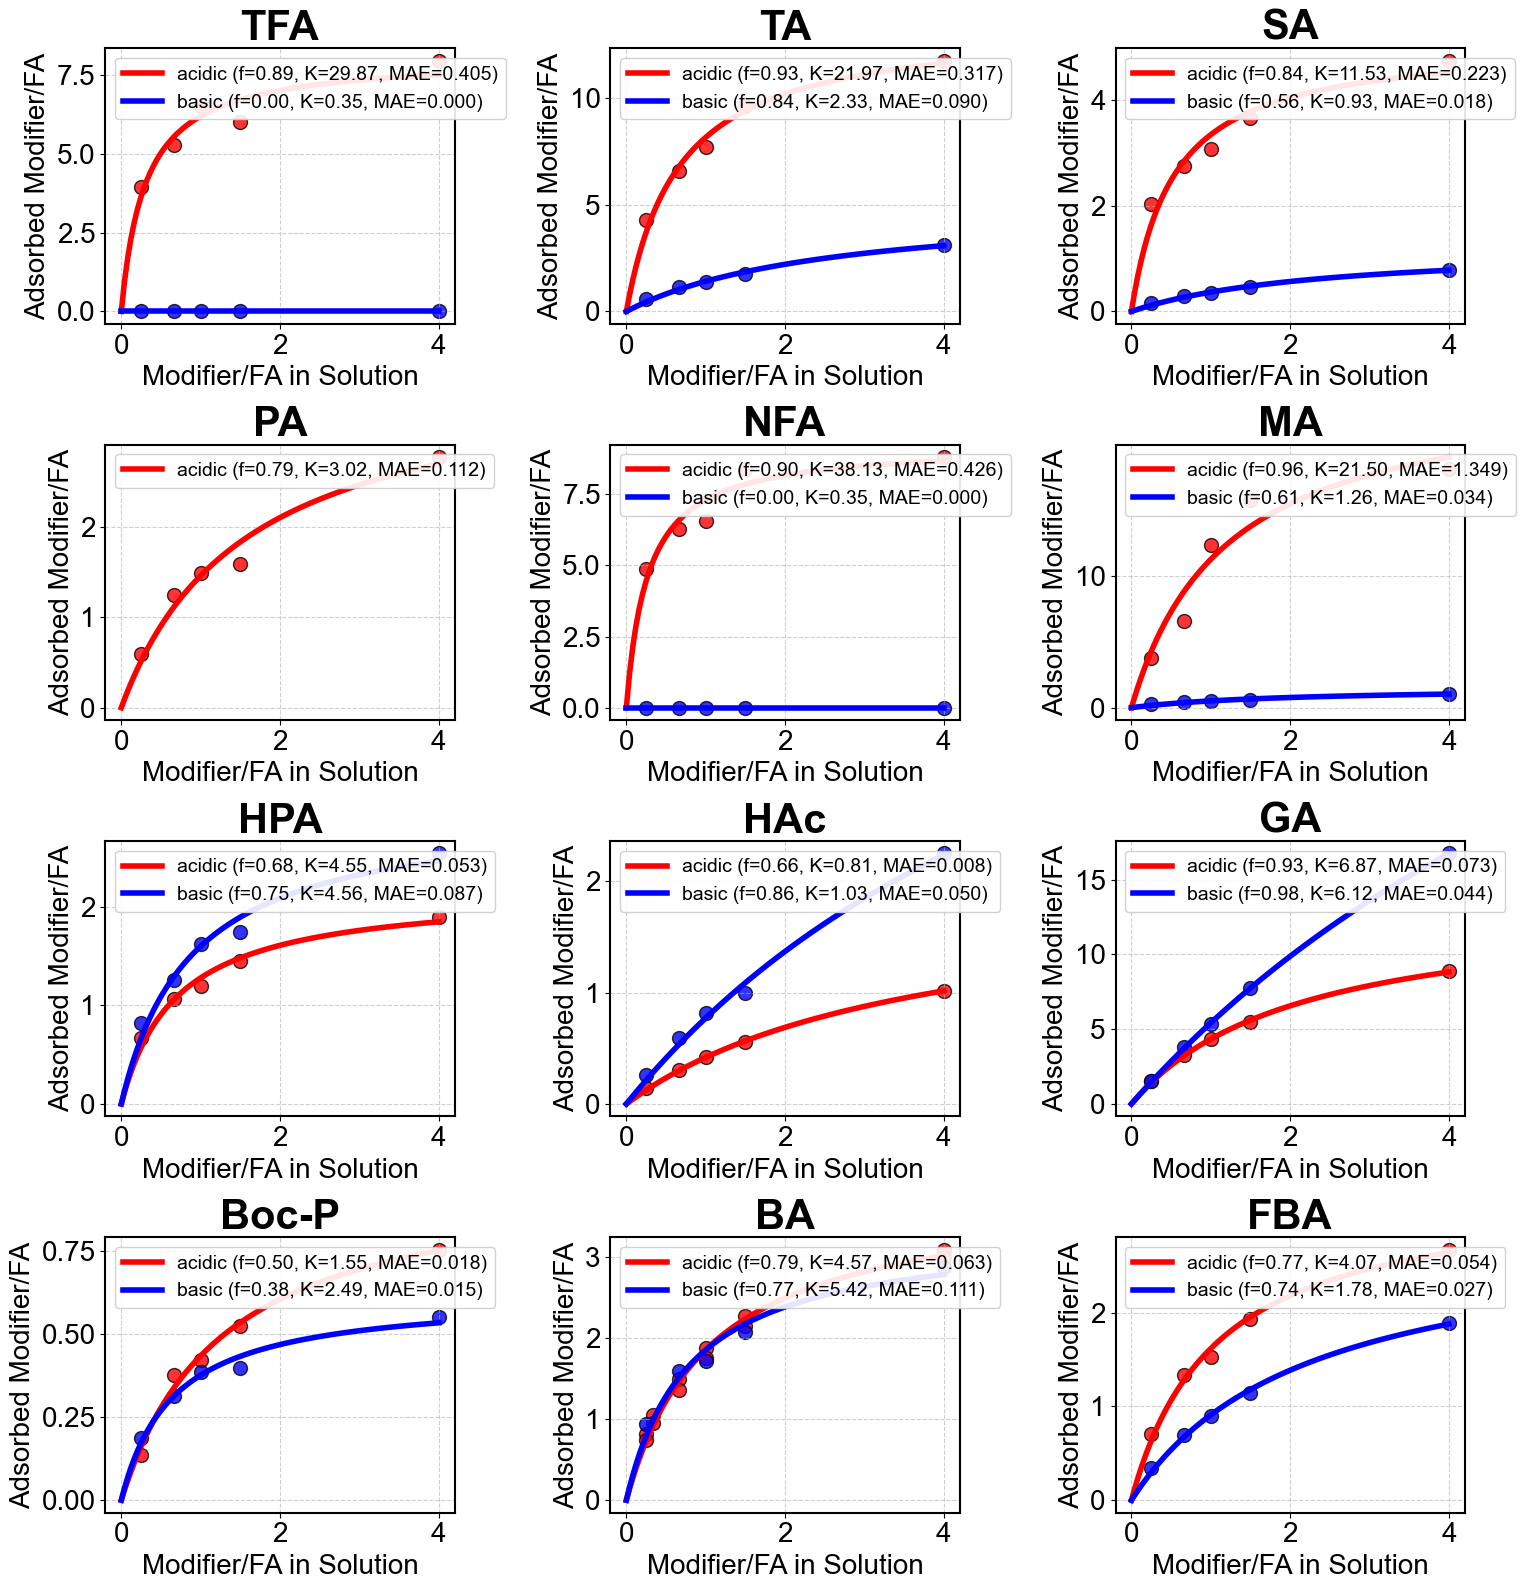

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Create a figure with a more compact layout - using less width for the subplots
fig = plt.figure(figsize=(30, 16))
# Create a grid with 4 rows and 6 columns, but only use the left half for these plots
# This leaves the right half of the figure available for other plots
gs = GridSpec(4, 6, figure=fig)


# Define color scheme for experiment types
experiment_colors = {'acidic': 'red', 'basic': 'blue'}
acids = df[df['Acid'] != 'CA']['Acid'].unique()
# Font sizes for publication-quality appearance
TITLE_SIZE = 30
LABEL_SIZE = 20
TICK_SIZE = 20
LEGEND_SIZE = 14

# Function to plot individual acid data
def plot_acid_data(ax, acid_name):
    acid_data = summary1[summary1['Acid'] == acid_name]
    
    for idx, row in acid_data.iterrows():
        experiment_type = row['Experiment']
        f = row['percentage']   # fraction of accessible sites
        k = row['k']            # equilibrium constant
        
        # Generate fitting curve
        x_fit = np.linspace(0, 4., 100)
        y_fit = adsorption_ratio2(x_fit, f, k)
        
        # Experimental data
        acid_df = df[(df['Acid'] == acid_name) & (df['Experiment'] == experiment_type)]
        x_points = acid_df['Acid conc (mM)'].values / acid_df['FA conc (mM)'].values
        y_points = acid_df['acid/SBU'].values / acid_df['FA/SBU'].values
        
        # Interpolate fitted values at experimental points
        y_pred = np.interp(x_points, x_fit, y_fit)
        
        # ---- Compute MAE ----
        mae = np.mean(np.abs(y_points - y_pred))
        
        # ---- Plot ----
        ax.plot(x_fit, y_fit, linewidth=4,
                label=f"{experiment_type} (f={f:.2f}, K={k:.2f}, MAE={mae:.3f})",
                color=experiment_colors[experiment_type])
        ax.scatter(x_points, y_points, color=experiment_colors[experiment_type],
                   alpha=0.8, s=100, edgecolors='black', linewidths=1)
    
    # ---- Styling ----
    ax.set_title(f"{acid_name}", fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Modifier/FA in Solution', fontsize=LABEL_SIZE)
    ax.set_ylabel('Adsorbed Modifier/FA', fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
    ax.legend(loc='upper left', fontsize=LEGEND_SIZE, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Border enhancement
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# Plot each acid in its own subplot
for i, acid in enumerate(acids[:12]):  # Limit to 12 acids to fit in the grid
    row = i // 3
    col = i % 3
    # Use only the left half of the grid (columns 0, 1, 2)
    ax = fig.add_subplot(gs[row, col])
    plot_acid_data(ax, acid)

plt.tight_layout()
plt.show()


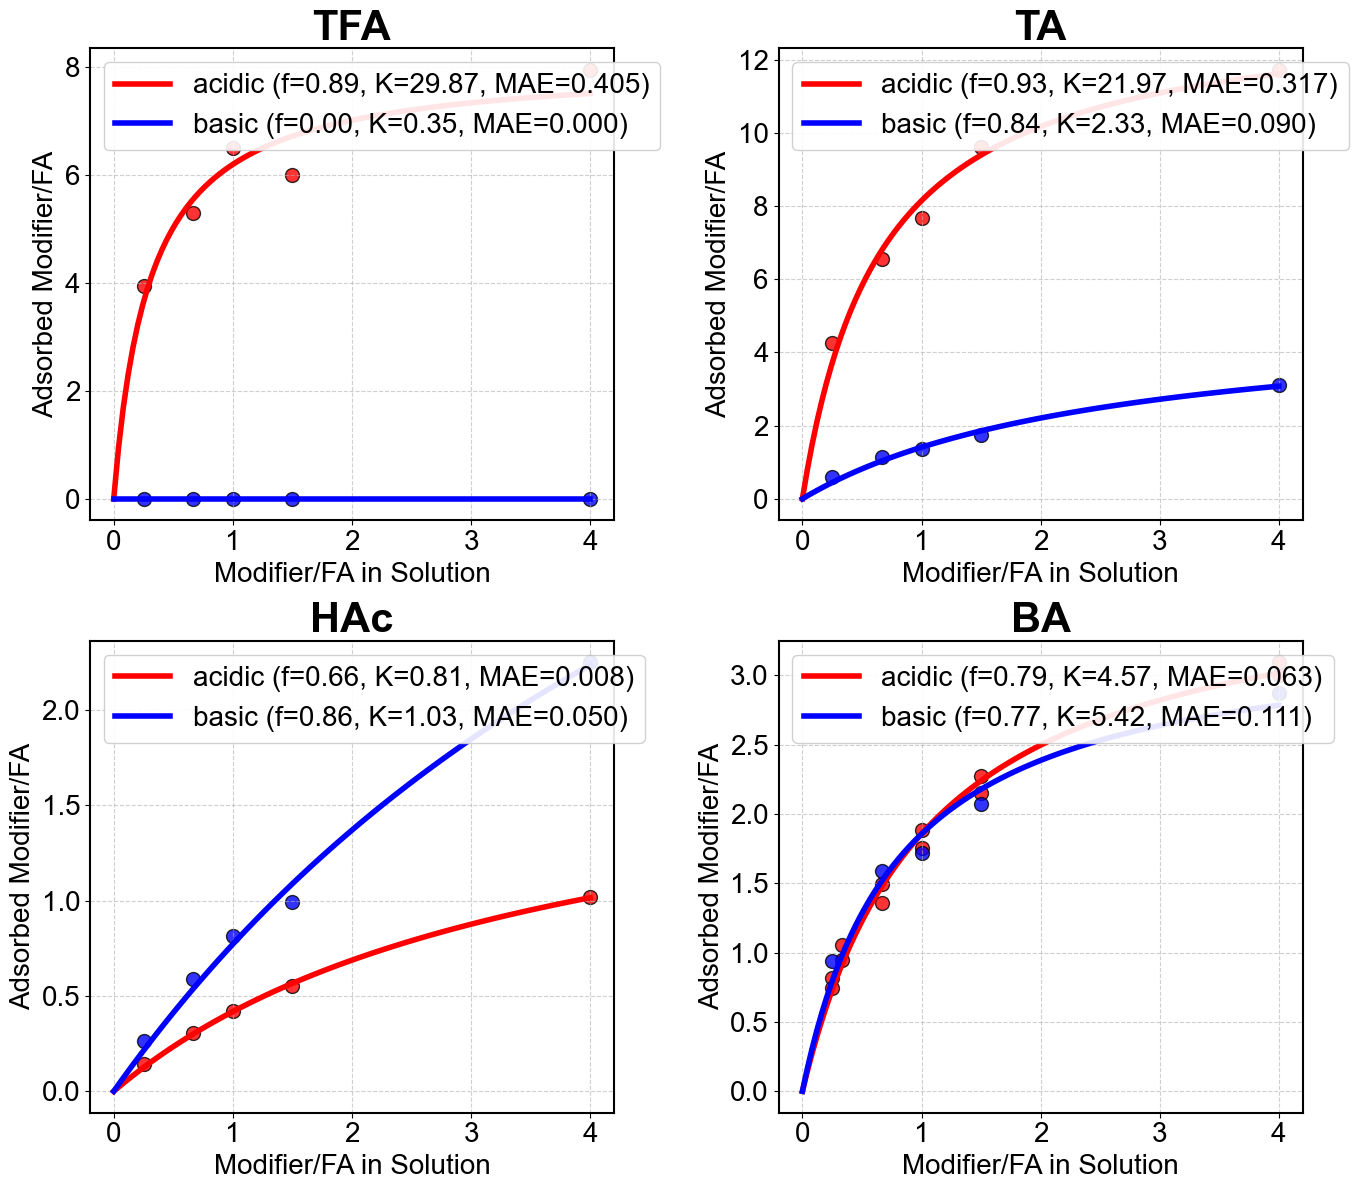

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Create a figure with a compact layout suitable for 2x2 subplots
fig = plt.figure(figsize=(14, 12))
gs = GridSpec(2, 2, figure=fig)

# Define acids to plot (fits a 2x2 grid perfectly)
acids = ["TFA", "TA", "HAc", "BA"]

# Define color scheme for experiment types
experiment_colors = {'acidic': 'red', 'basic': 'blue'}

# Font sizes for publication-quality appearance
TITLE_SIZE = 30
LABEL_SIZE = 20
TICK_SIZE = 20
LEGEND_SIZE = 20

# Function to plot individual acid data
def plot_acid_data(ax, acid_name):
    acid_data = summary1[summary1['Acid'] == acid_name]
    
    for idx, row in acid_data.iterrows():
        experiment_type = row['Experiment']
        f = row['percentage']   # fraction of accessible sites
        k = row['k']            # equilibrium constant
        
        # Generate fitting curve
        x_fit = np.linspace(0, 4., 100)
        y_fit = adsorption_ratio2(x_fit, f, k)
        
        # Experimental data
        acid_df = df[(df['Acid'] == acid_name) & (df['Experiment'] == experiment_type)]
        x_points = acid_df['Acid conc (mM)'].values / acid_df['FA conc (mM)'].values
        y_points = acid_df['acid/SBU'].values / acid_df['FA/SBU'].values
        
        # Interpolate fitted values at experimental points
        y_pred = np.interp(x_points, x_fit, y_fit)
        
        # ---- Compute MAE ----
        mae = np.mean(np.abs(y_points - y_pred))
        
        # ---- Plot ----
        ax.plot(x_fit, y_fit, linewidth=4,
                label=f"{experiment_type} (f={f:.2f}, K={k:.2f}, MAE={mae:.3f})",
                color=experiment_colors[experiment_type])
        ax.scatter(x_points, y_points, color=experiment_colors[experiment_type],
                   alpha=0.8, s=100, edgecolors='black', linewidths=1)
    
    # ---- Styling ----
    ax.set_title(f"{acid_name}", fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Modifier/FA in Solution', fontsize=LABEL_SIZE)
    ax.set_ylabel('Adsorbed Modifier/FA', fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
    ax.legend(loc='upper left', fontsize=LEGEND_SIZE, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Border enhancement
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# ---- Create 2x2 subplot layout ----
for i, acid in enumerate(acids):
    row = i // 2
    col = i % 2
    ax = fig.add_subplot(gs[row, col])
    plot_acid_data(ax, acid)

plt.tight_layout()
plt.show()


2. Fit the two independent curves

In [9]:
import numpy as np
from scipy.optimize import curve_fit

# ----------------------------------------------------------------------
# vectorised model for BOTH curves
# ----------------------------------------------------------------------
def _two_curve_model(xcat, n1, A, B, k):
    """
    xcat : concatenated x-data  (len = n1 + n2)
    n1   : length of first data block
    A, B, k : shared parameters
    """
    x1, x2 = xcat[:n1], xcat[n1:]

    ycat = np.empty_like(xcat, dtype=float)
    ycat[:n1]  = A / (k * x1 + 1) + B               # curve 1
    ycat[n1:]  = (k * x2 / (k * x2 + 1)) * A        # curve 2
    return ycat

# ----------------------------------------------------------------------
# public helper
# ----------------------------------------------------------------------
def fit_two_curves_shared(x1, y1, x2, y2, p0=(1., 0., 1.),
                          bounds=([0., 0., 0.], [np.inf, np.inf, np.inf])):
    """
    Simultaneous least‑squares fit with shared (A, B, k).

    Parameters
    ----------
    x1, y1 : 1‑D array‑like     data for curve 1
    x2, y2 : 1‑D array‑like     data for curve 2
    p0     : tuple              initial (A, B, k)
    bounds : 2‑tuple/list       ([Amin, Bmin, kmin], [Amax, Bmax, kmax])

    Returns
    -------
    popt : ndarray   best‑fit [A, B, k]
    pcov : ndarray   covariance matrix
    """

    # ­­­­­‑‑ clean NaN / Inf
    m1 = np.isfinite(x1) & np.isfinite(y1)
    m2 = np.isfinite(x2) & np.isfinite(y2)
    if m1.sum() + m2.sum() < 3:
        raise ValueError("Need at least three finite points total.")

    x1c, y1c = np.asarray(x1)[m1], np.asarray(y1)[m1]
    x2c, y2c = np.asarray(x2)[m2], np.asarray(y2)[m2]

    # ­­­­­‑‑ concatenate
    xcat  = np.concatenate([x1c,  x2c])
    ycat  = np.concatenate([y1c,  y2c])
    n1    = len(x1c)            # border index for the model

    # ­­­­­‑‑ wrapper with fixed n1 for curve_fit
    model = lambda x, A, B, k: _two_curve_model(x, n1, A, B, k)

    popt, pcov = curve_fit(model, xcat, ycat, p0=p0,
                           bounds=bounds, maxfev=5000)
    return popt, pcov


In [10]:
popt, pcov = fit_two_curves_shared(x, this_curve["FA/SBU"].values, x, this_curve["acid/SBU"].values,
                                   p0=(2., 0.5, 10.),
                                   bounds=([0, 0, 0], [6, 6, np.inf]))
print("A, B, k  =", popt)

A, B, k  = [0.24137575 1.86778417 1.18220144]


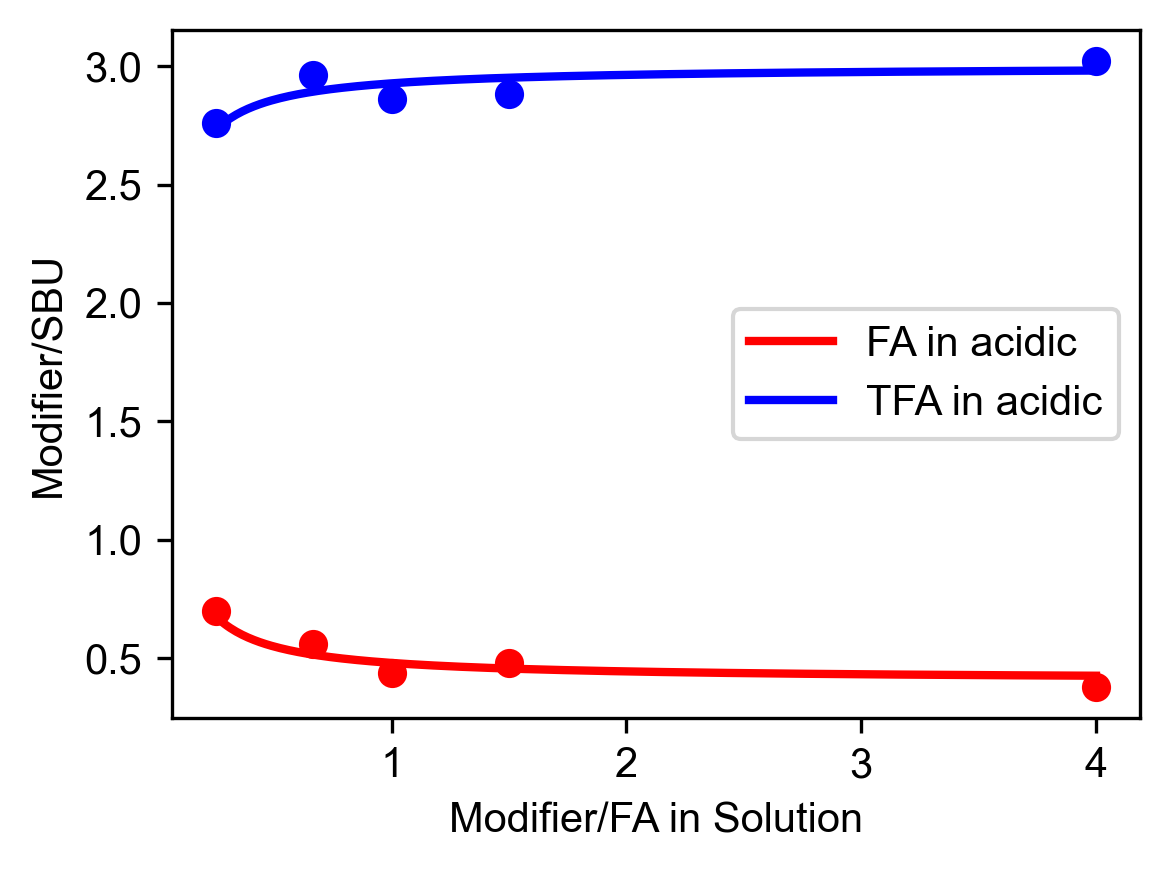

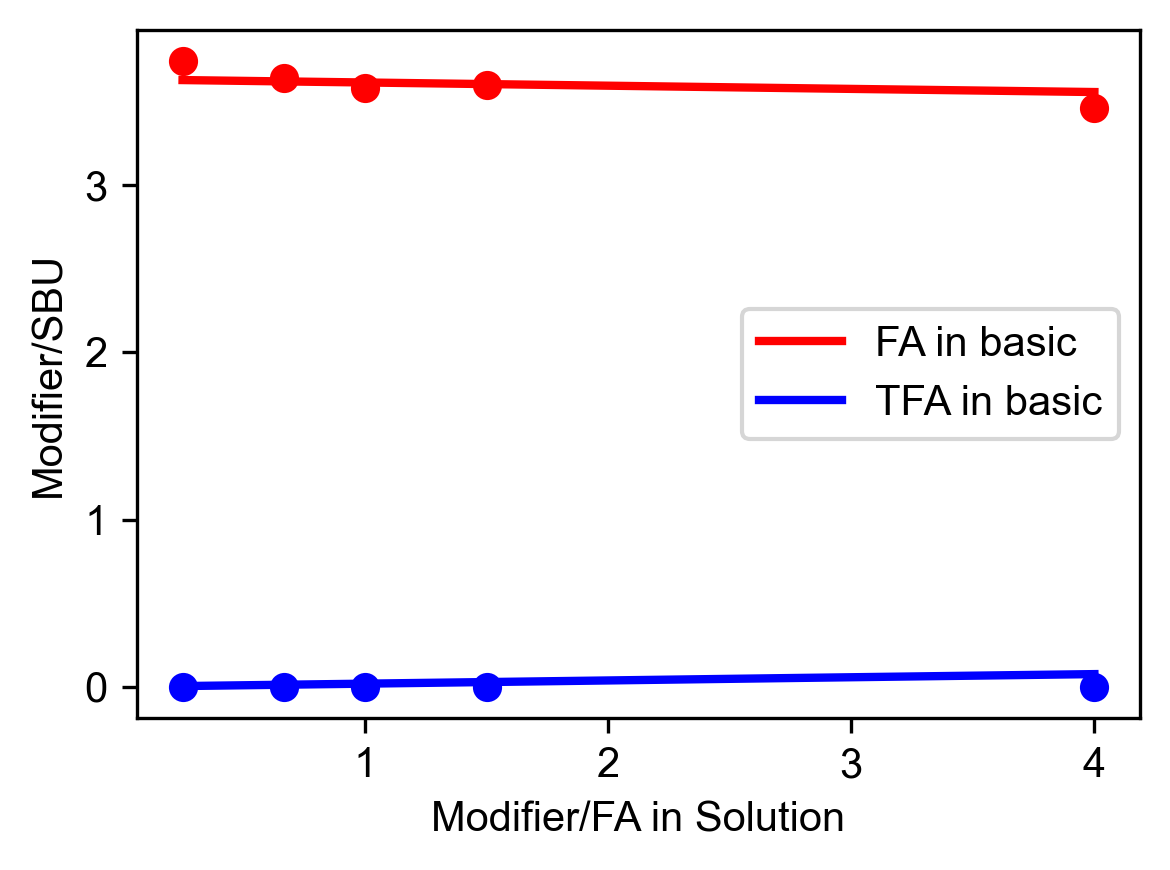

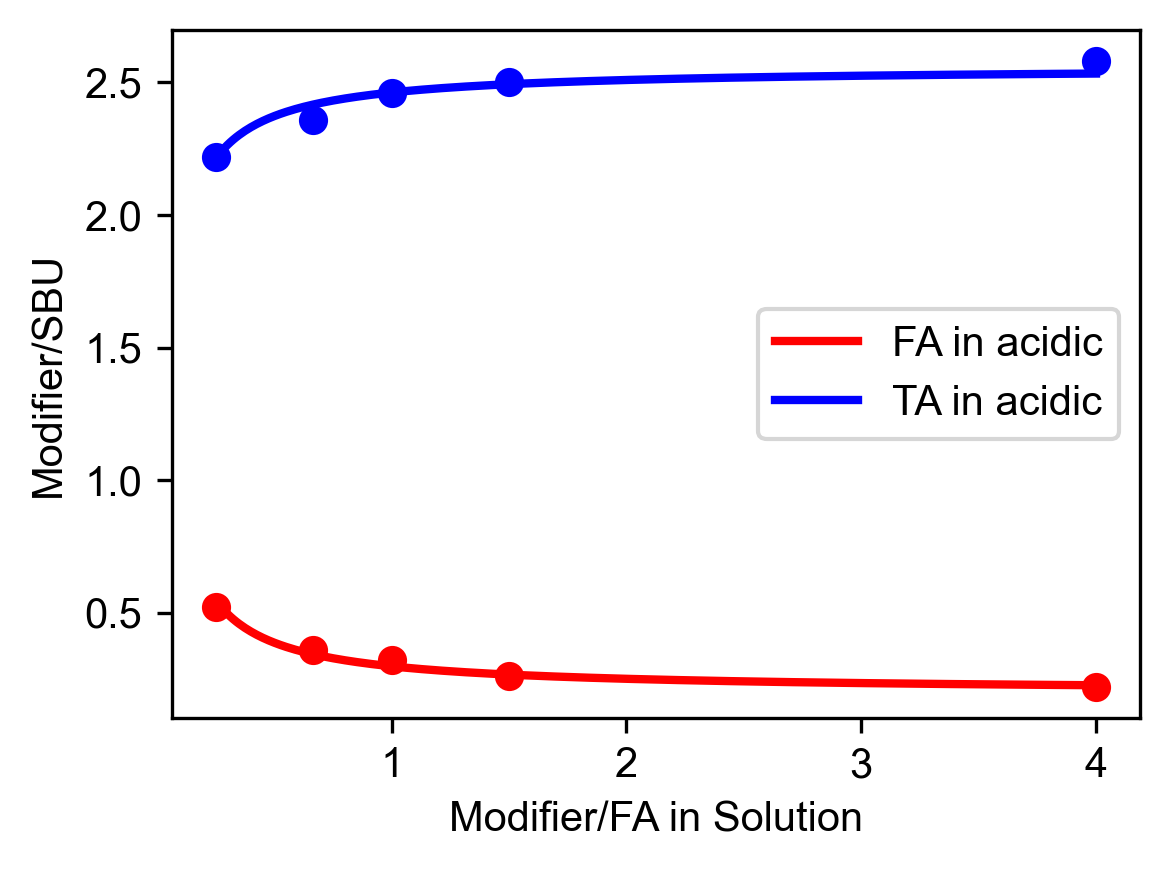

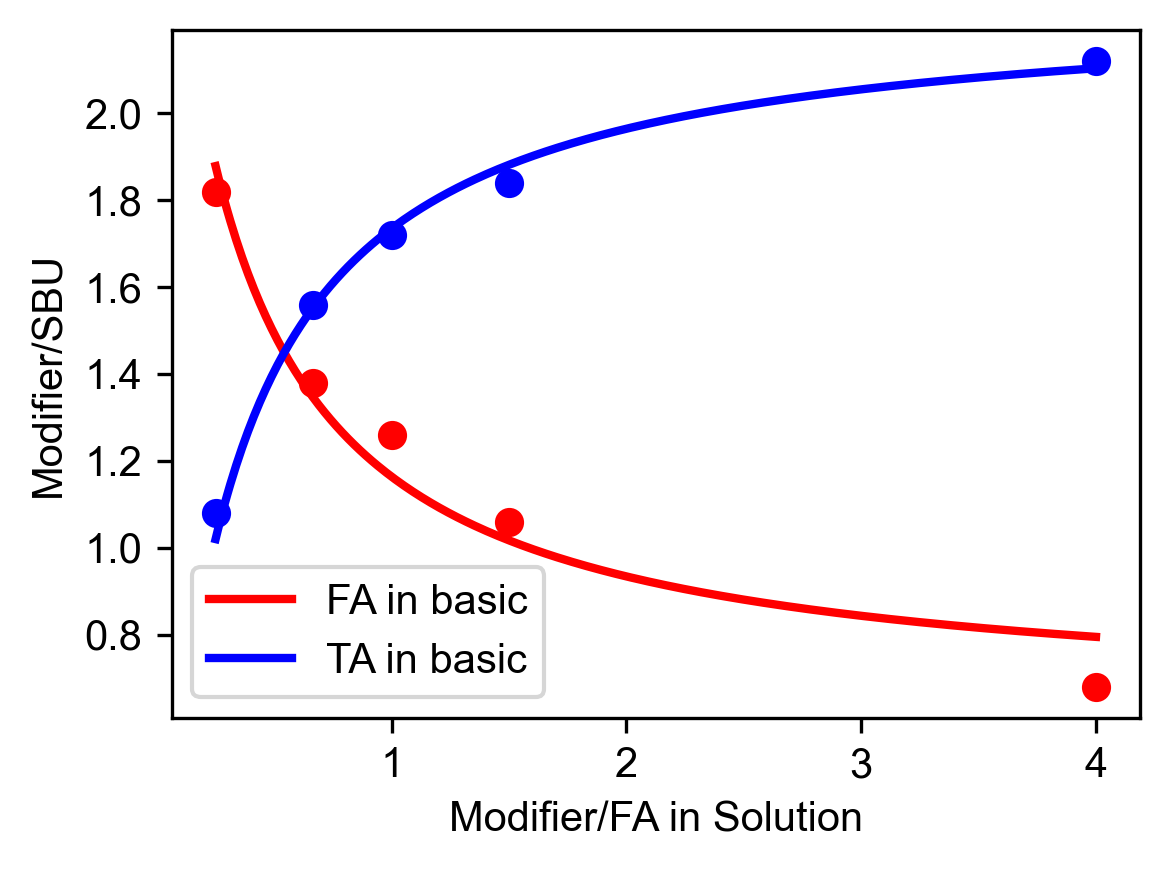

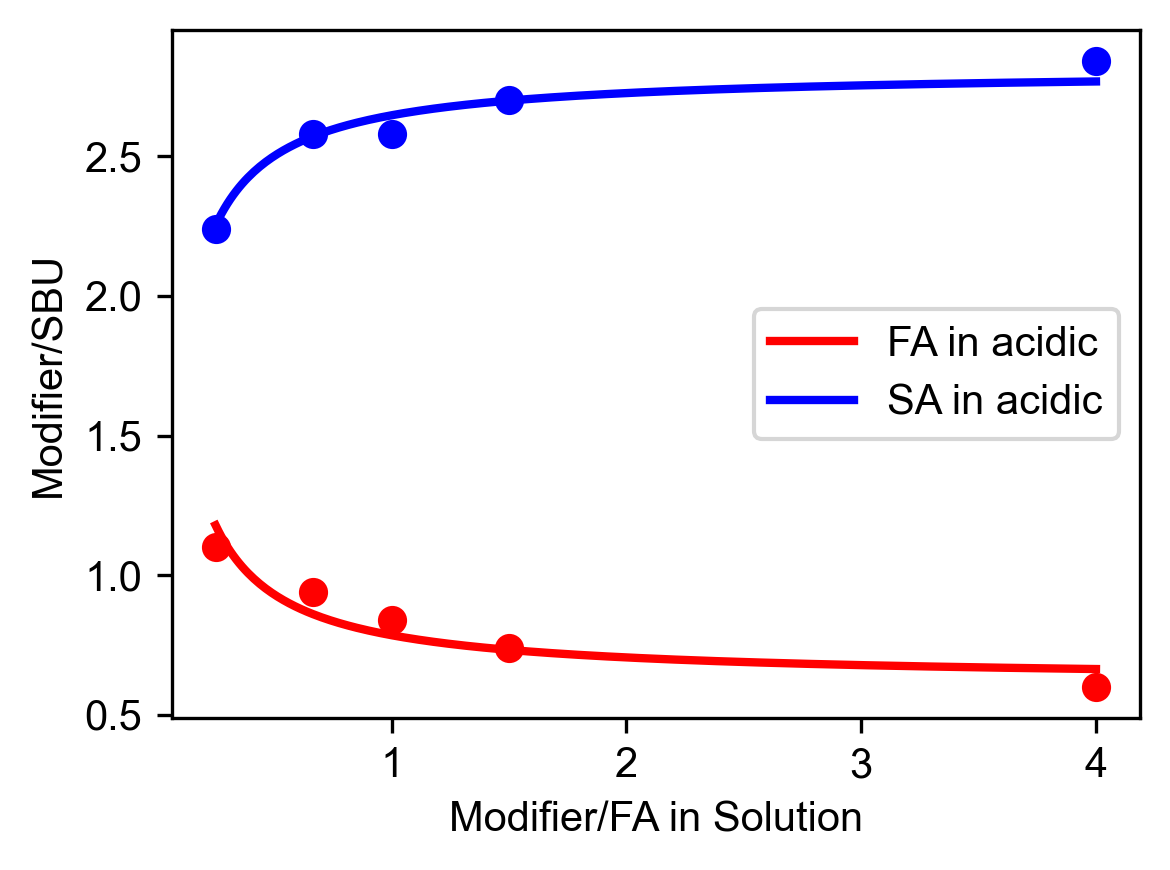

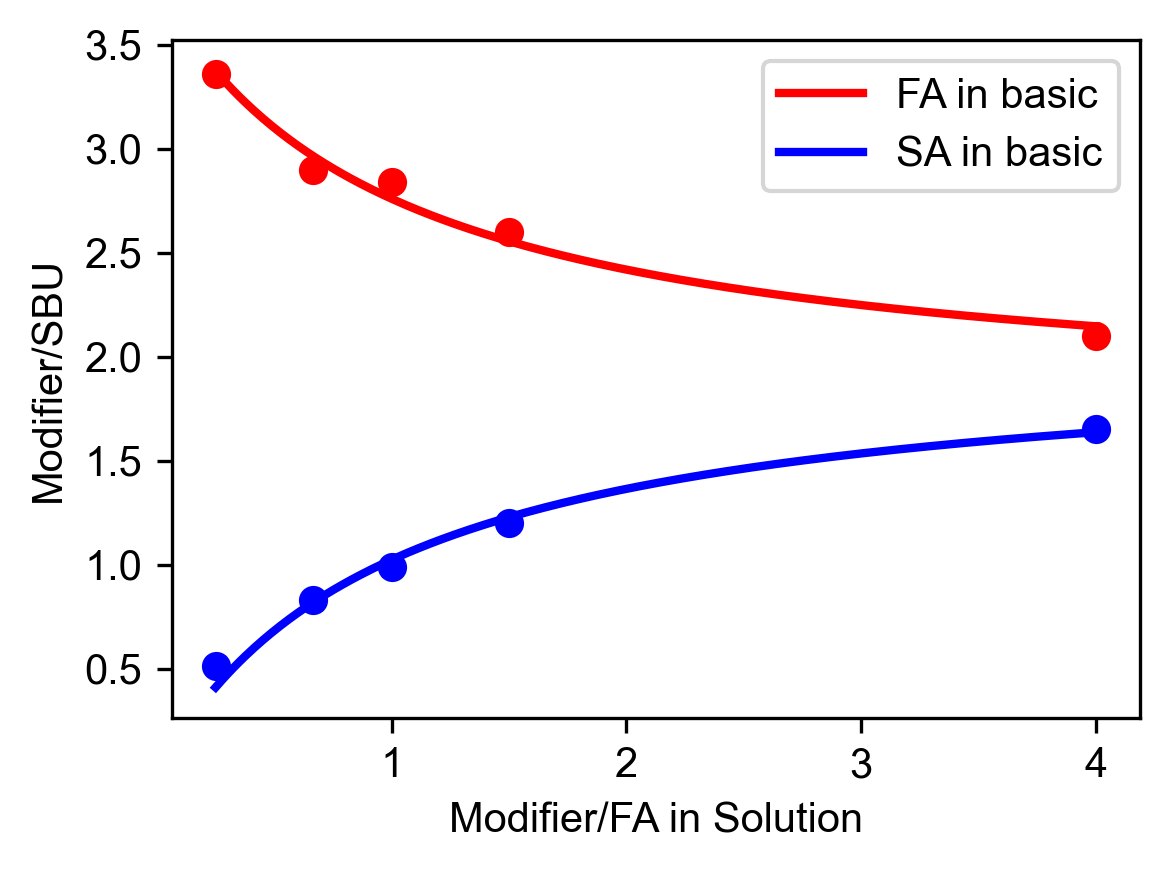

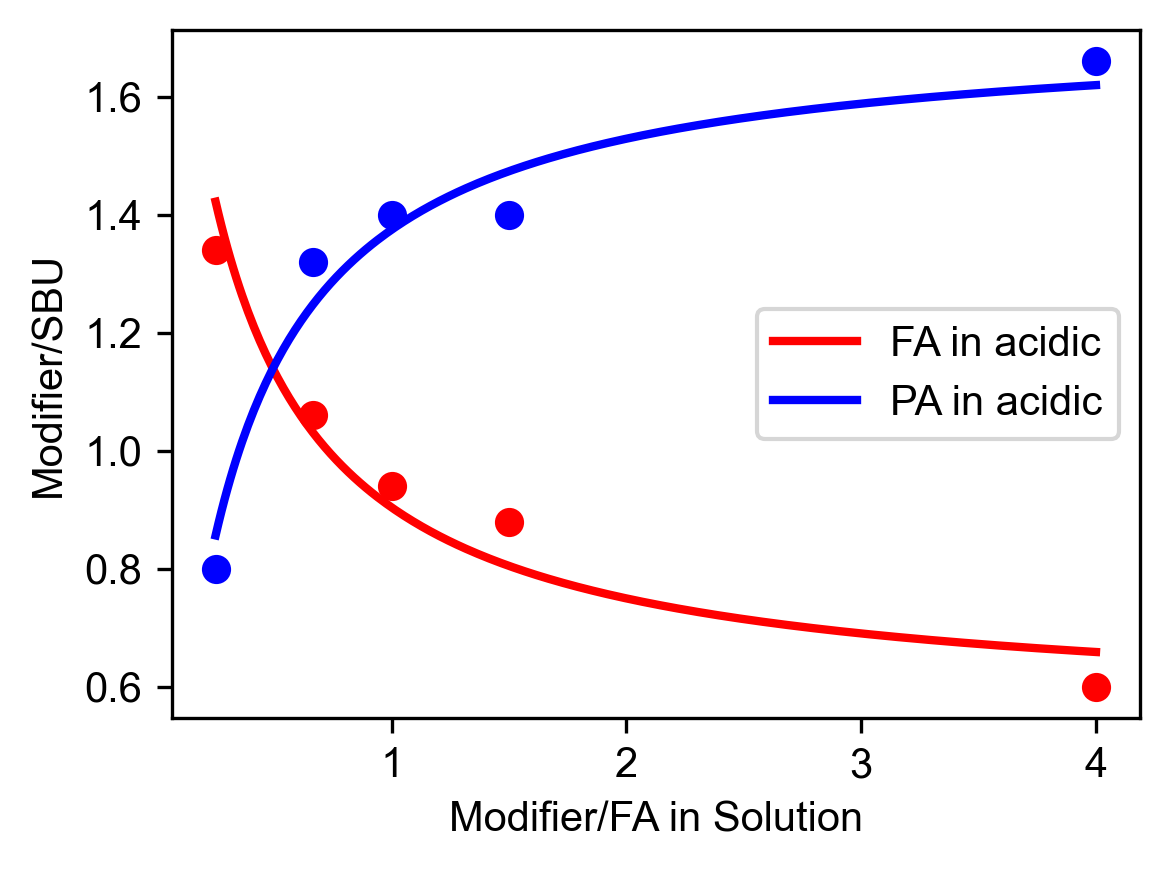

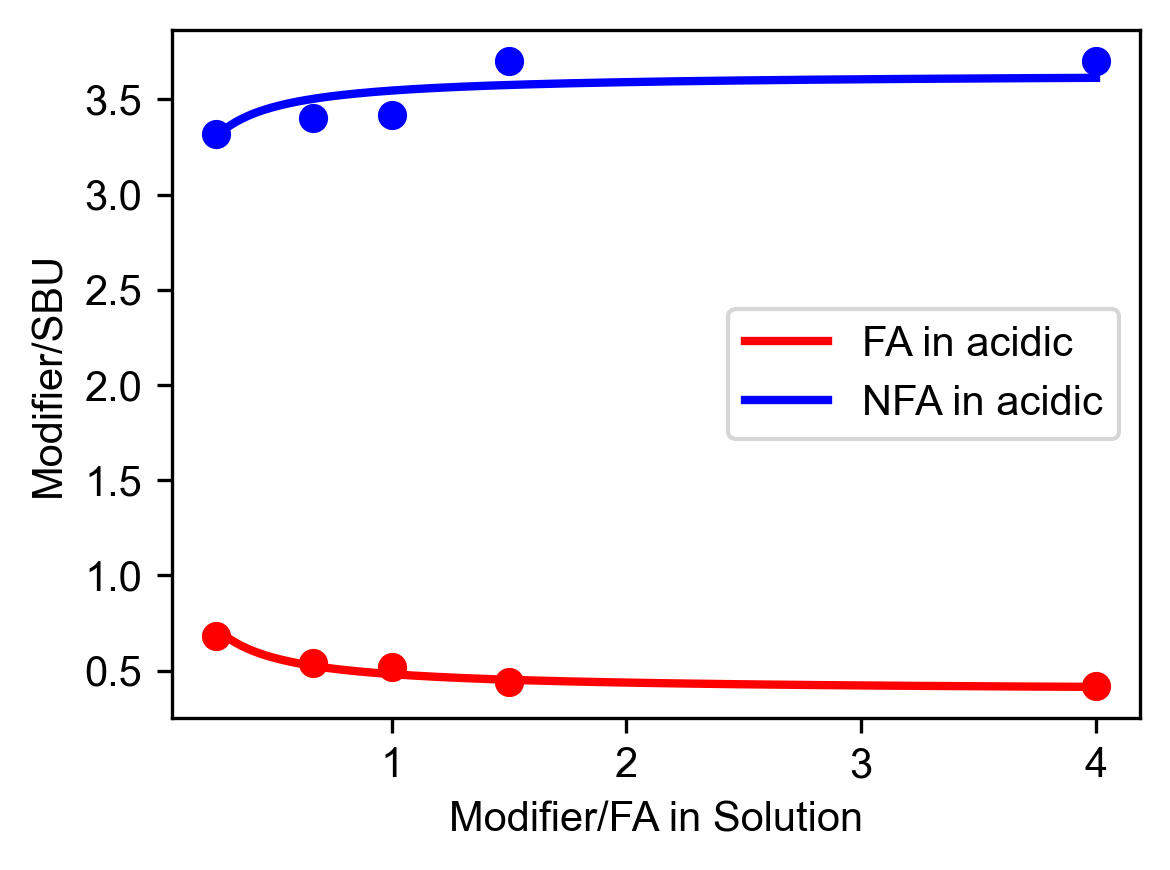

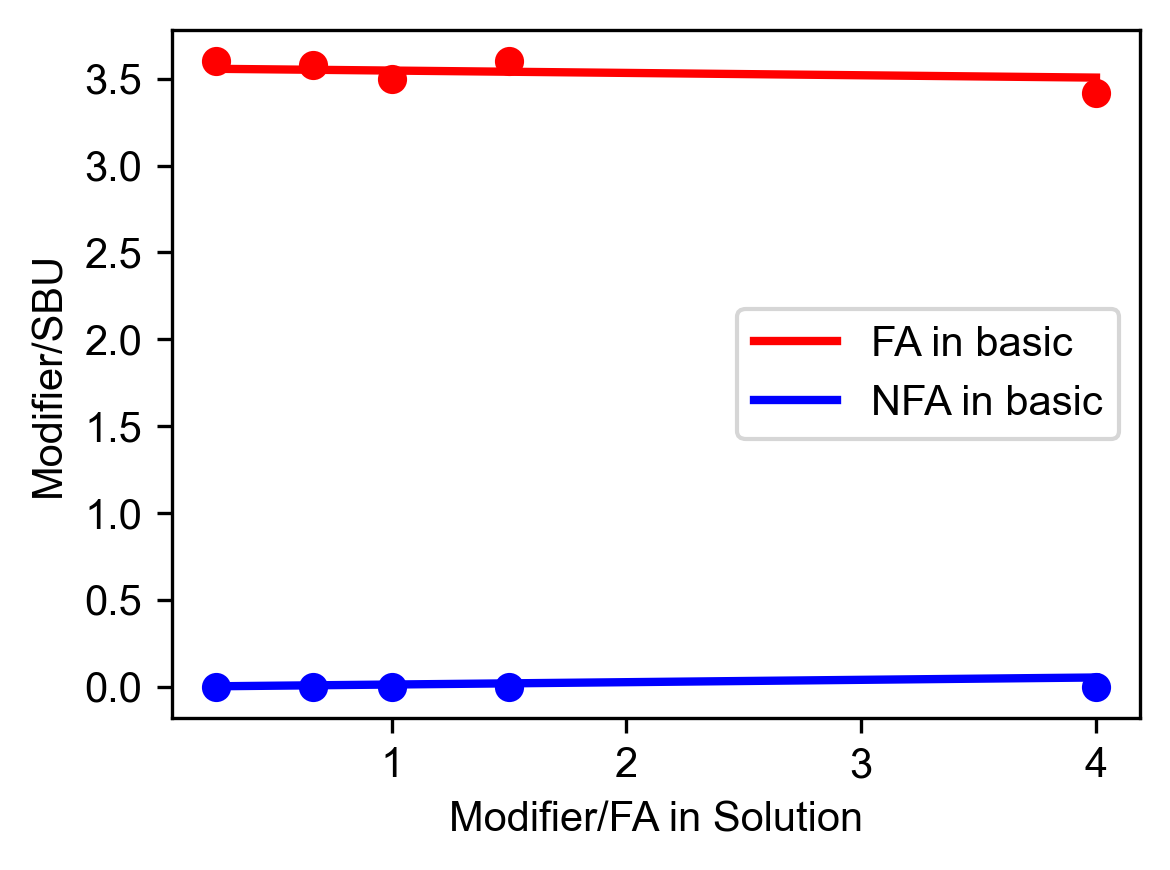

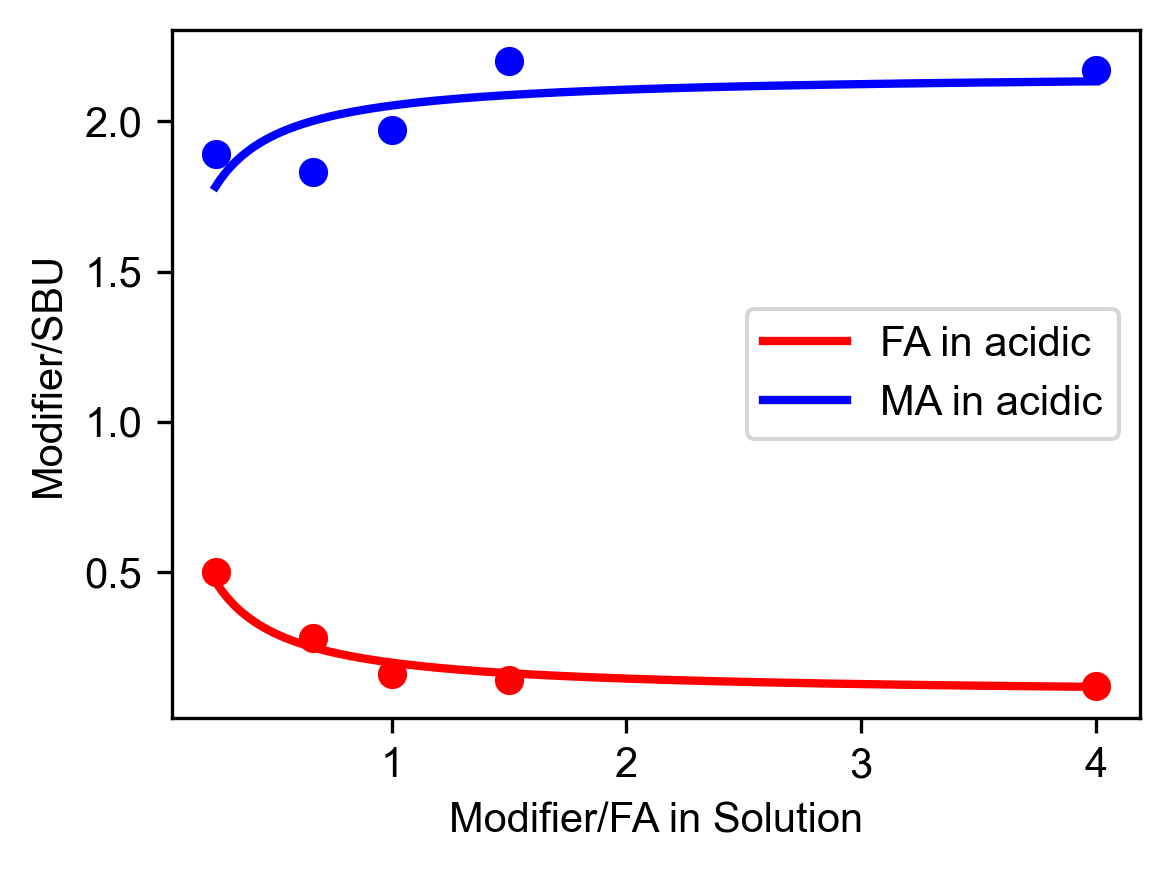

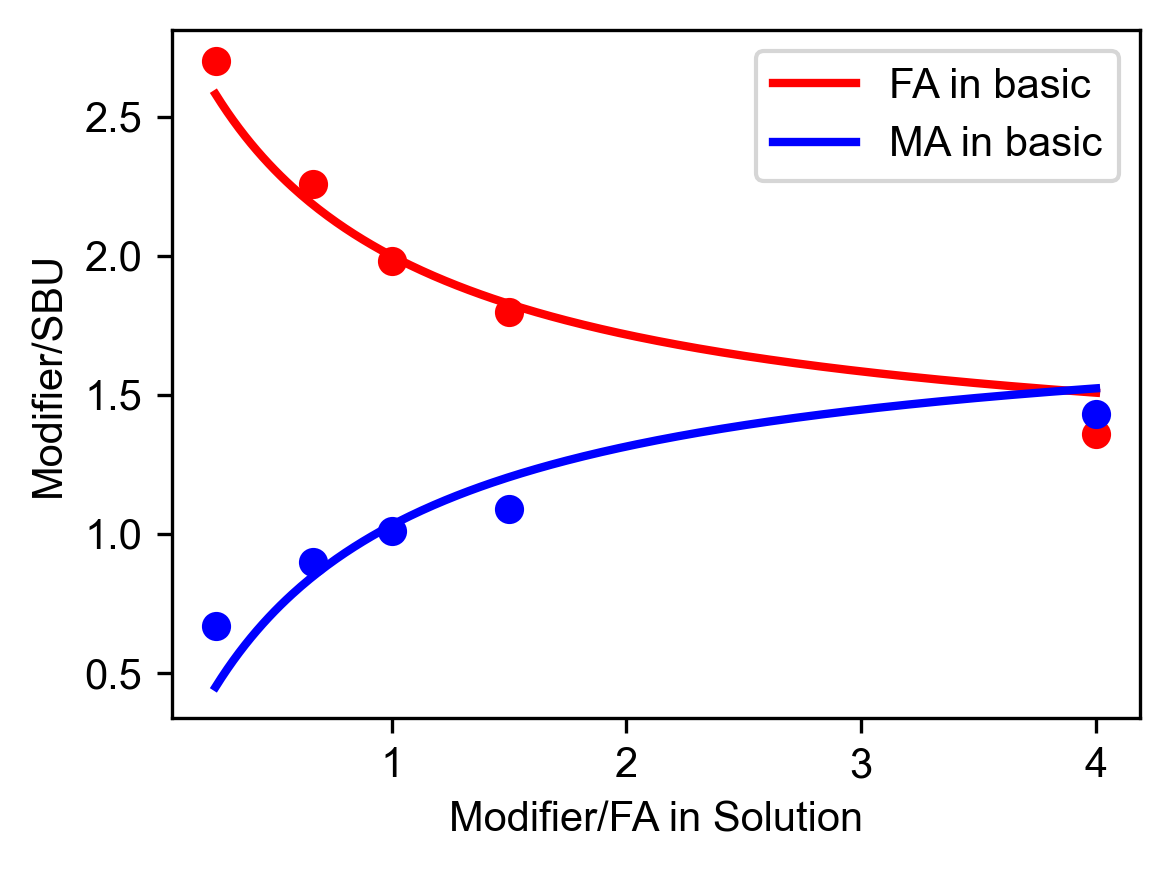

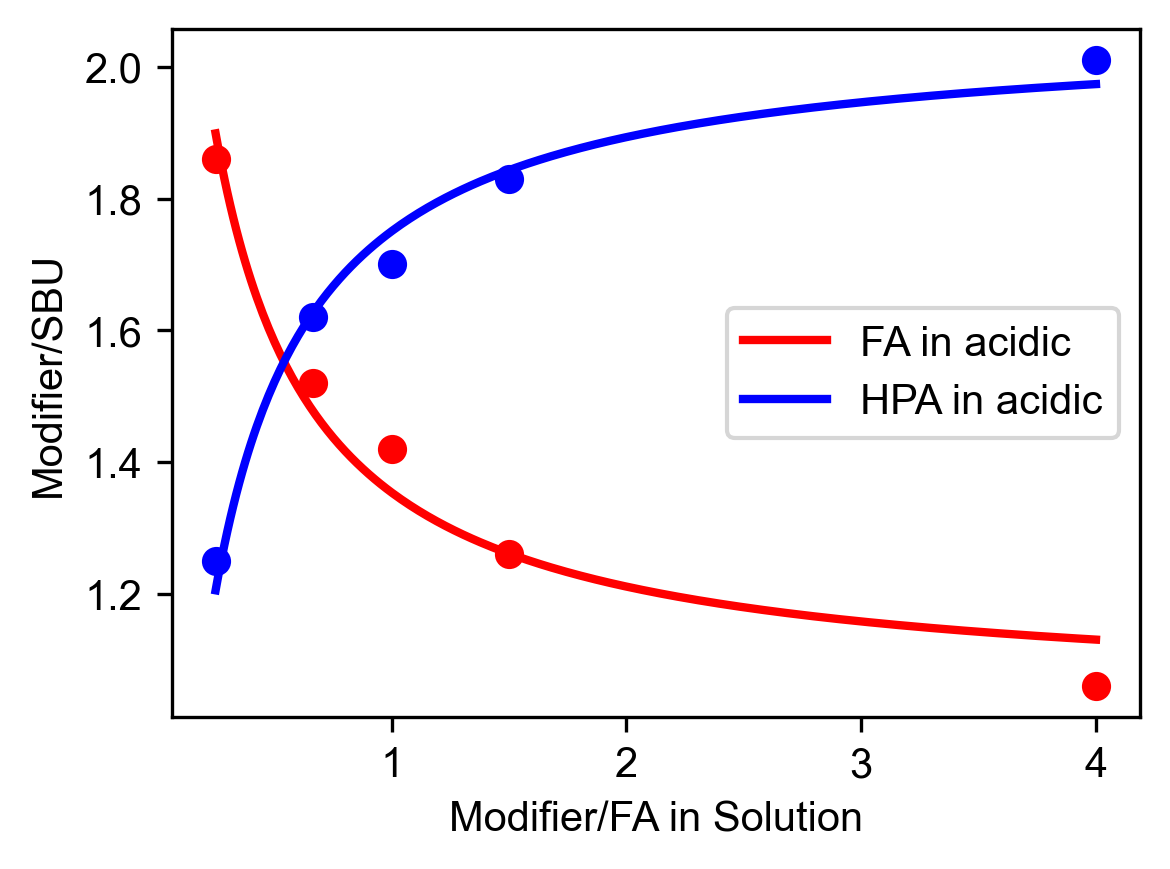

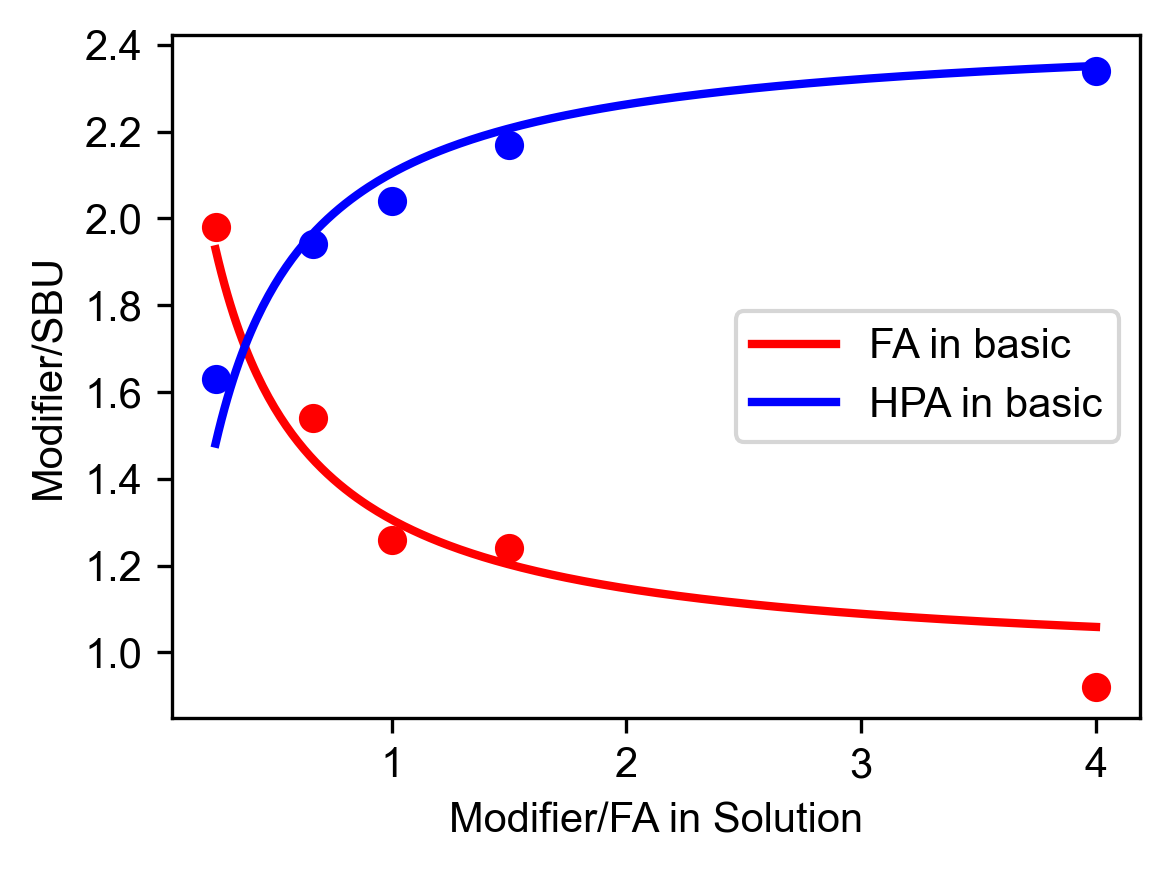

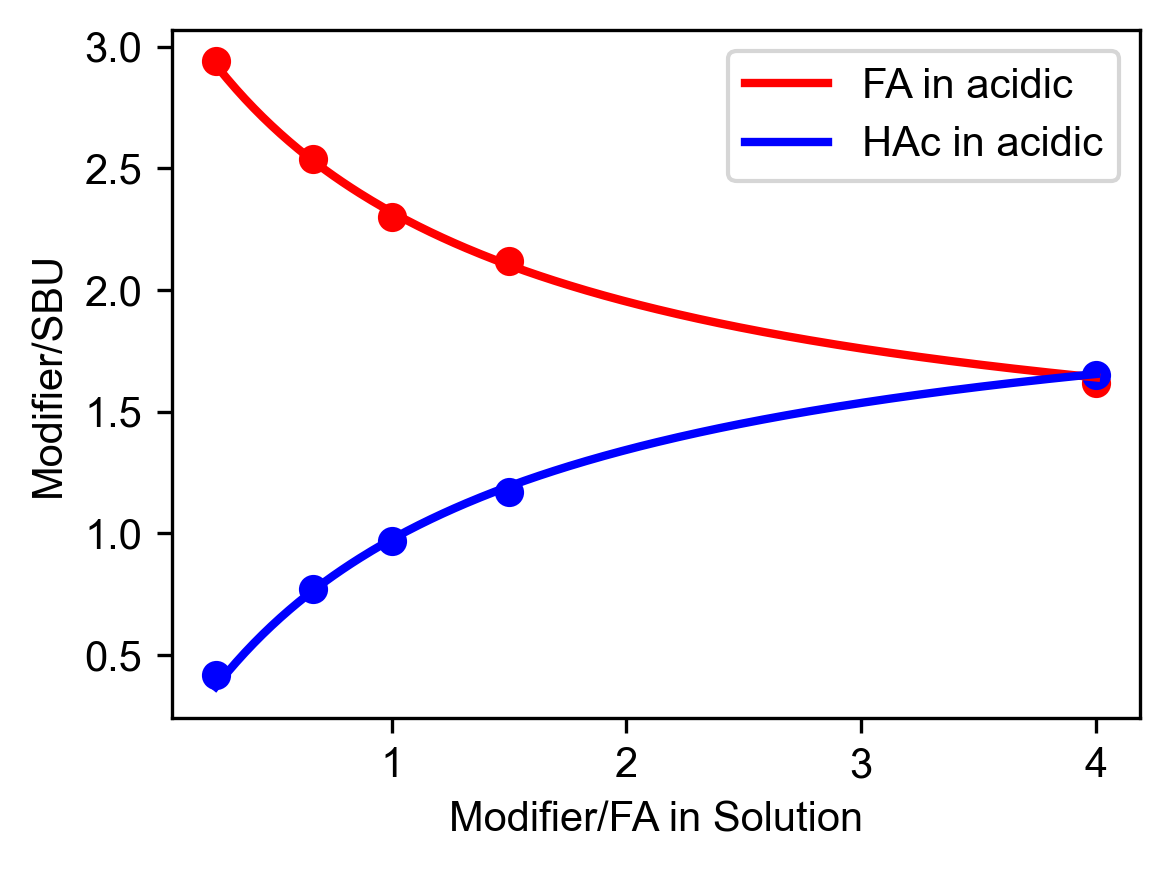

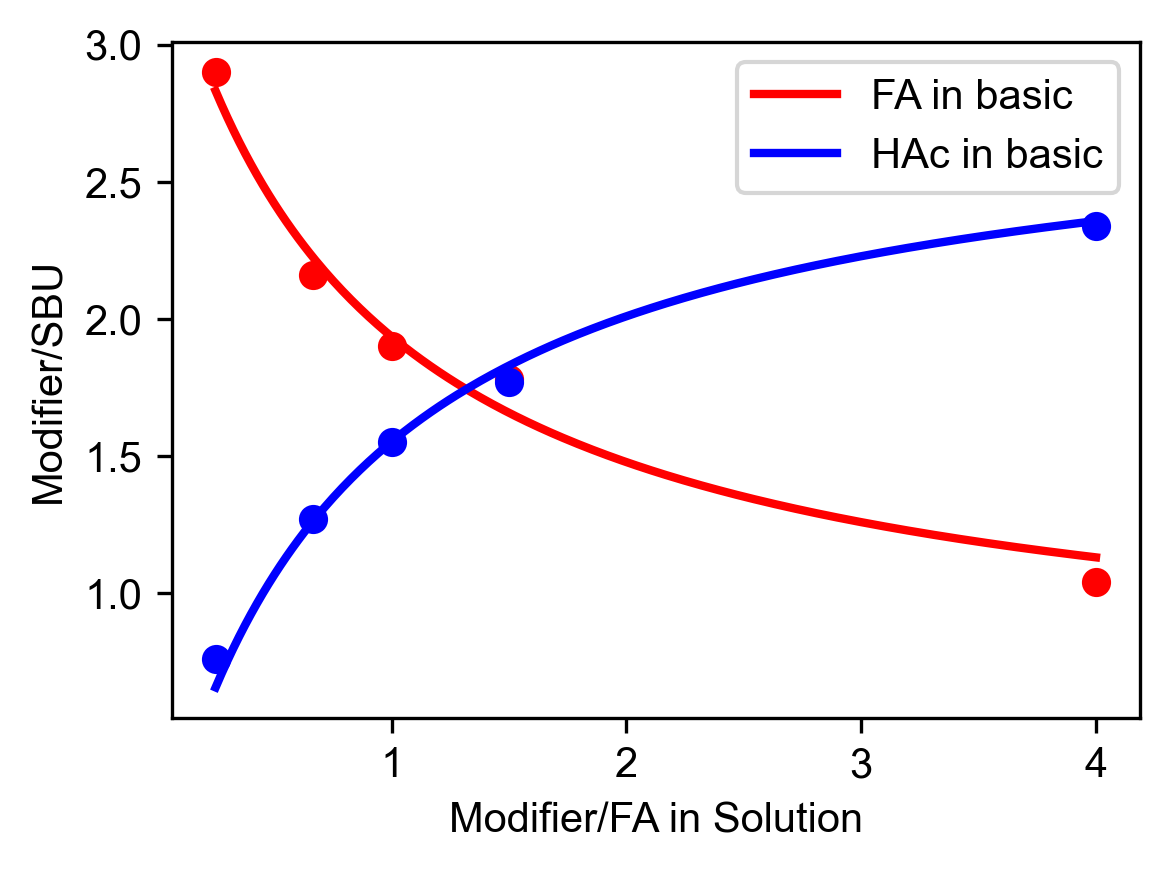

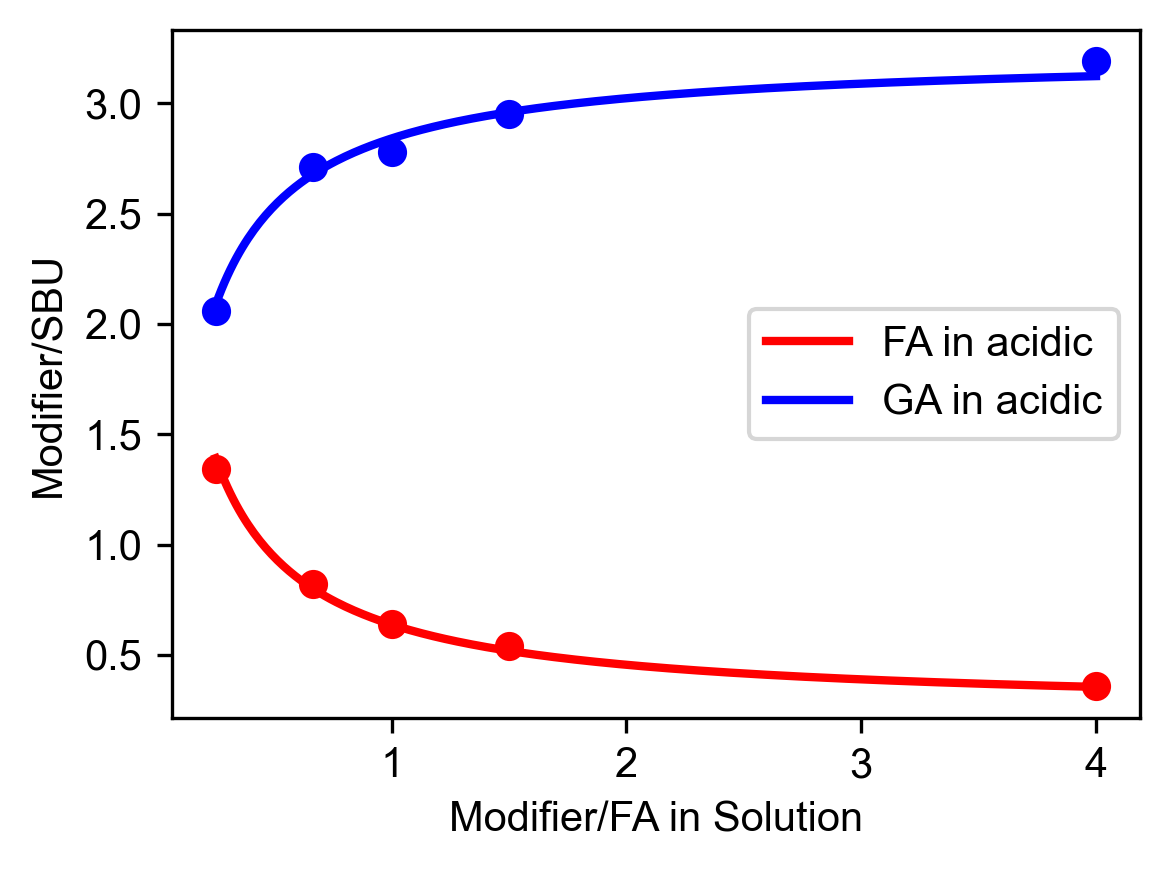

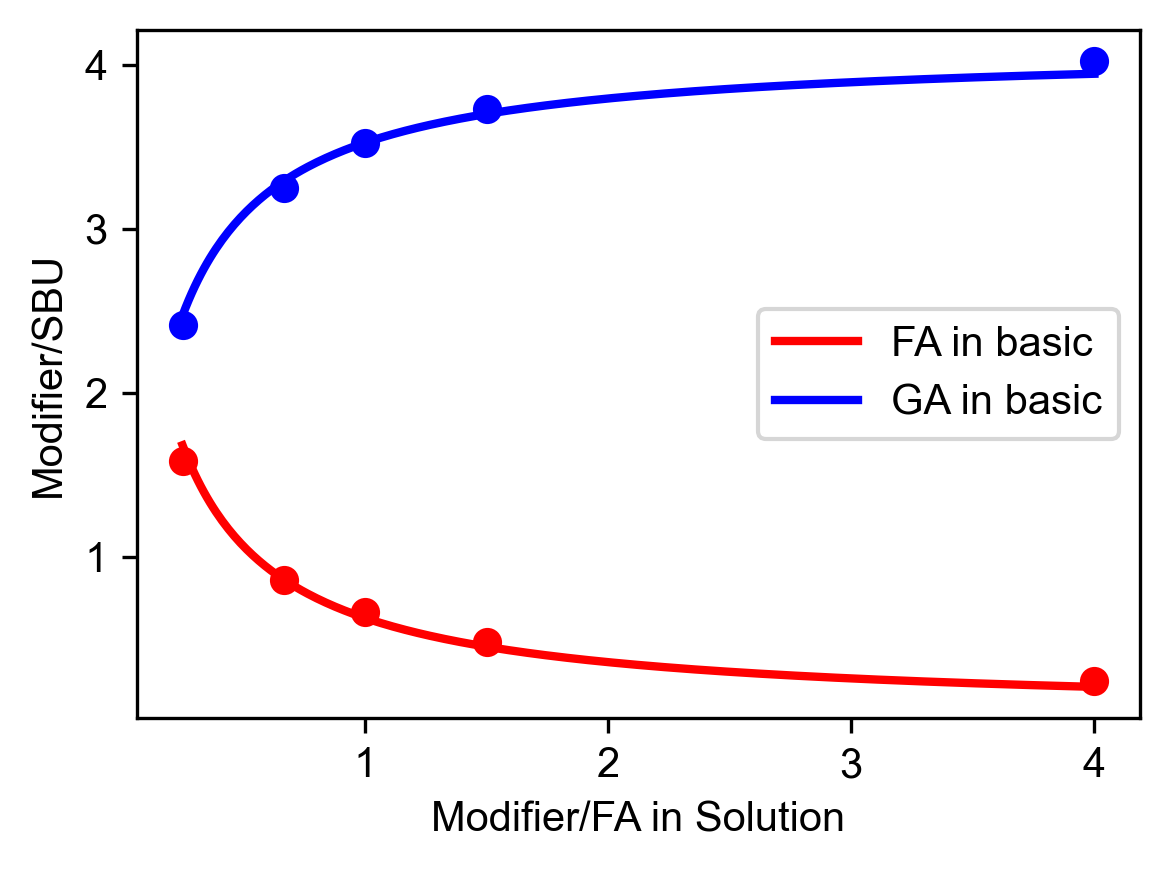

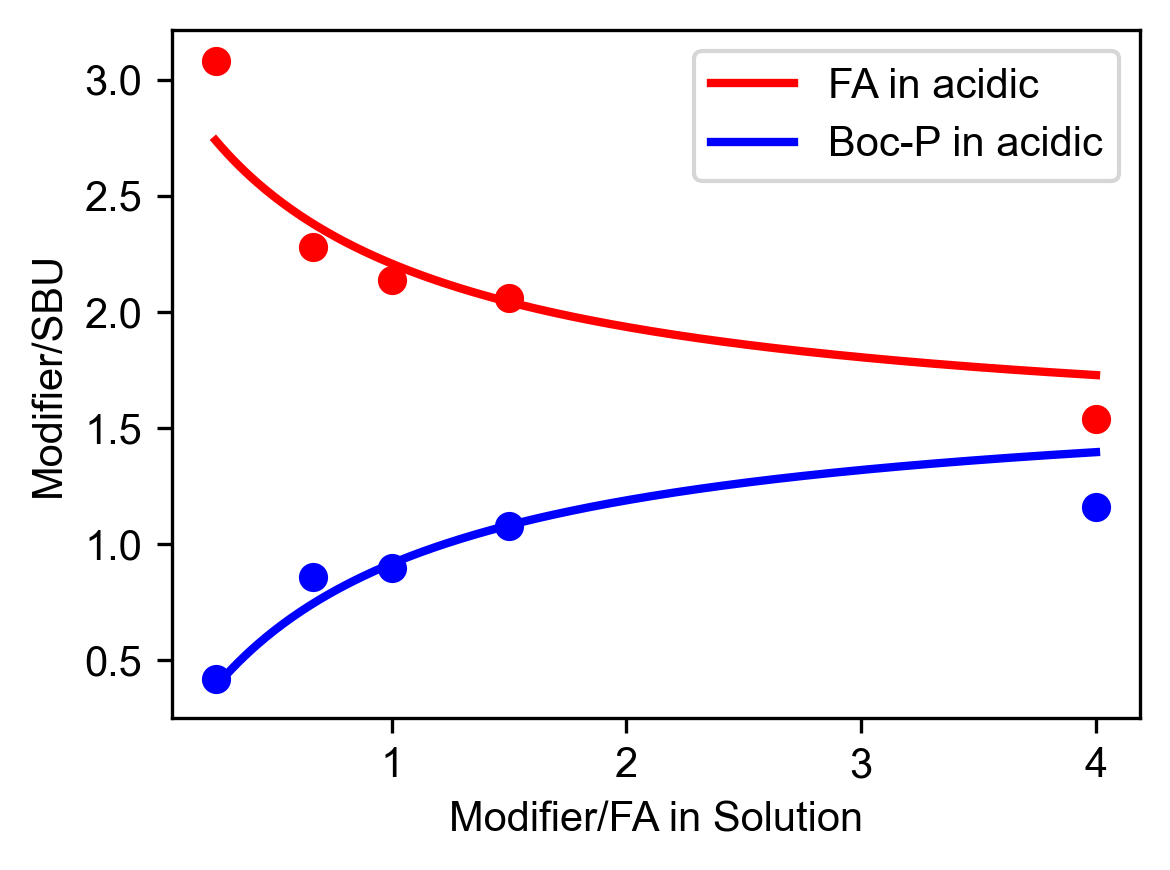

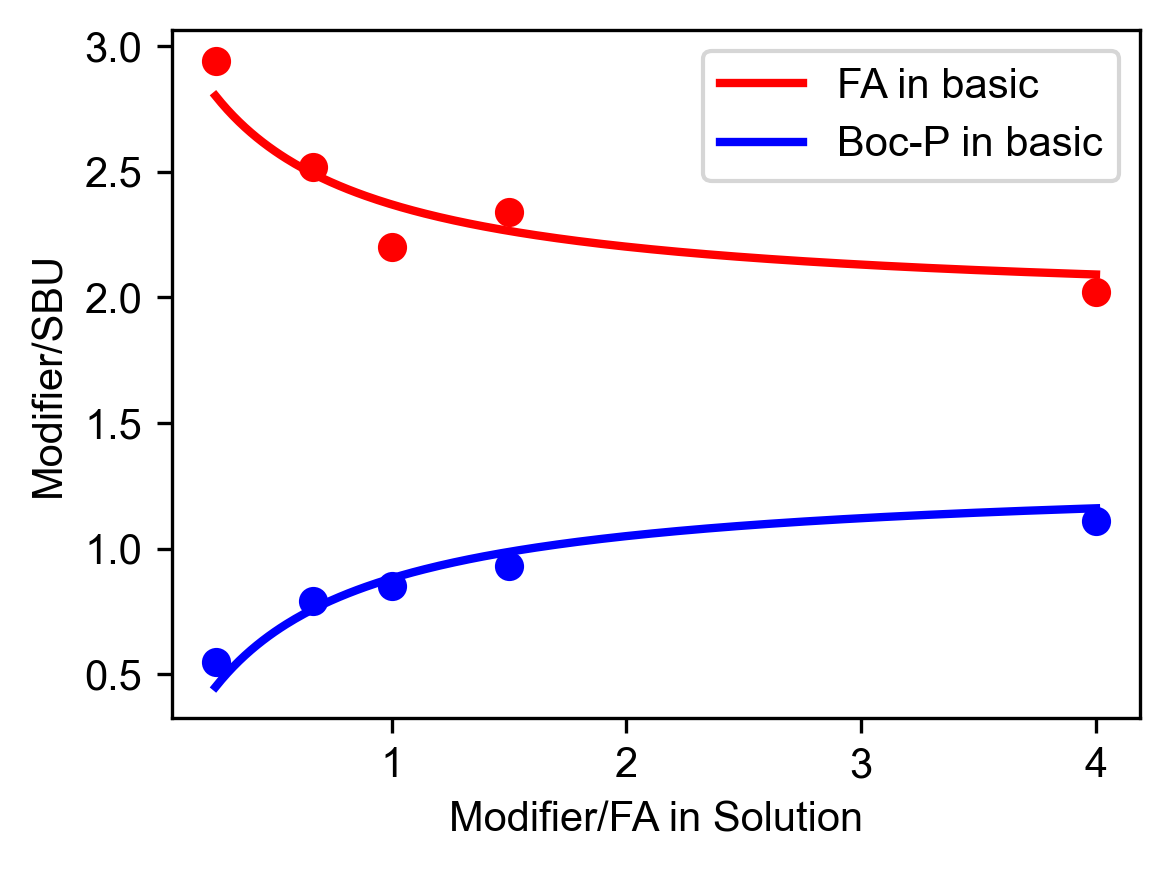

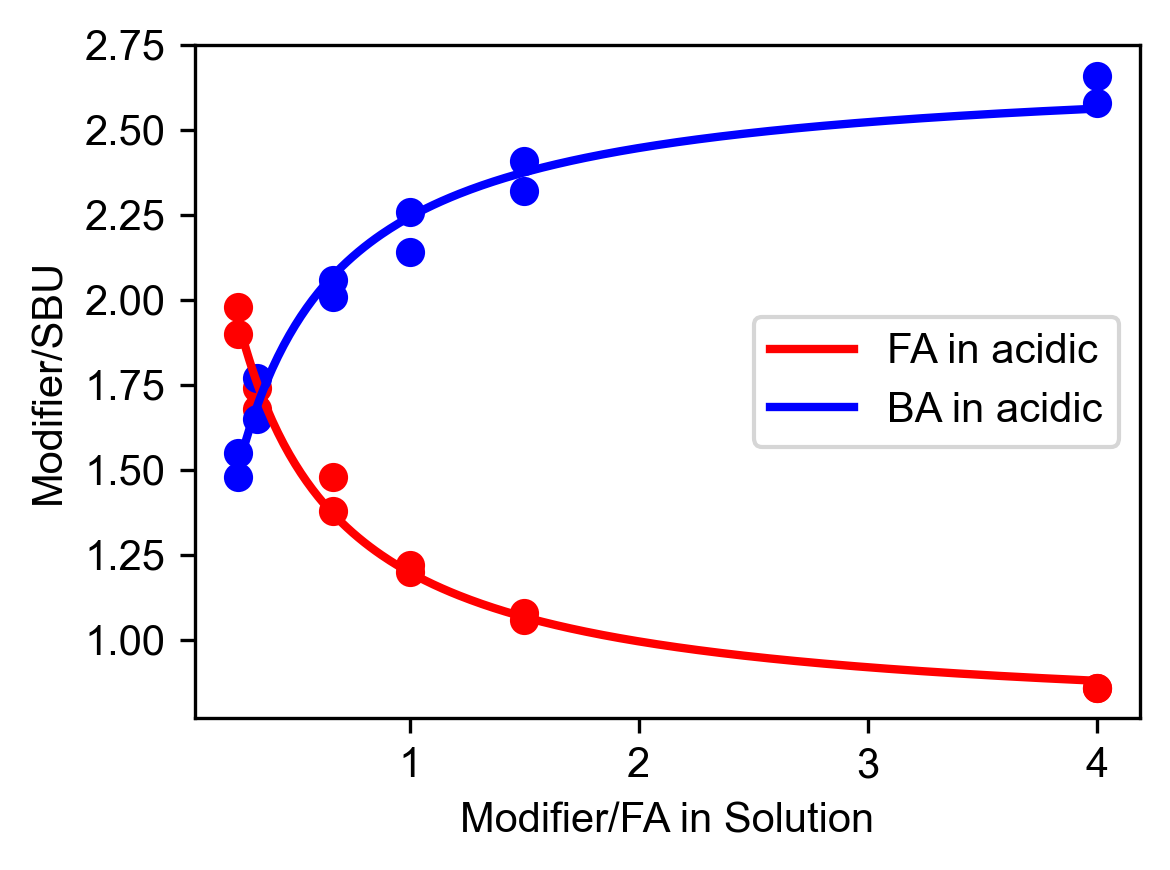

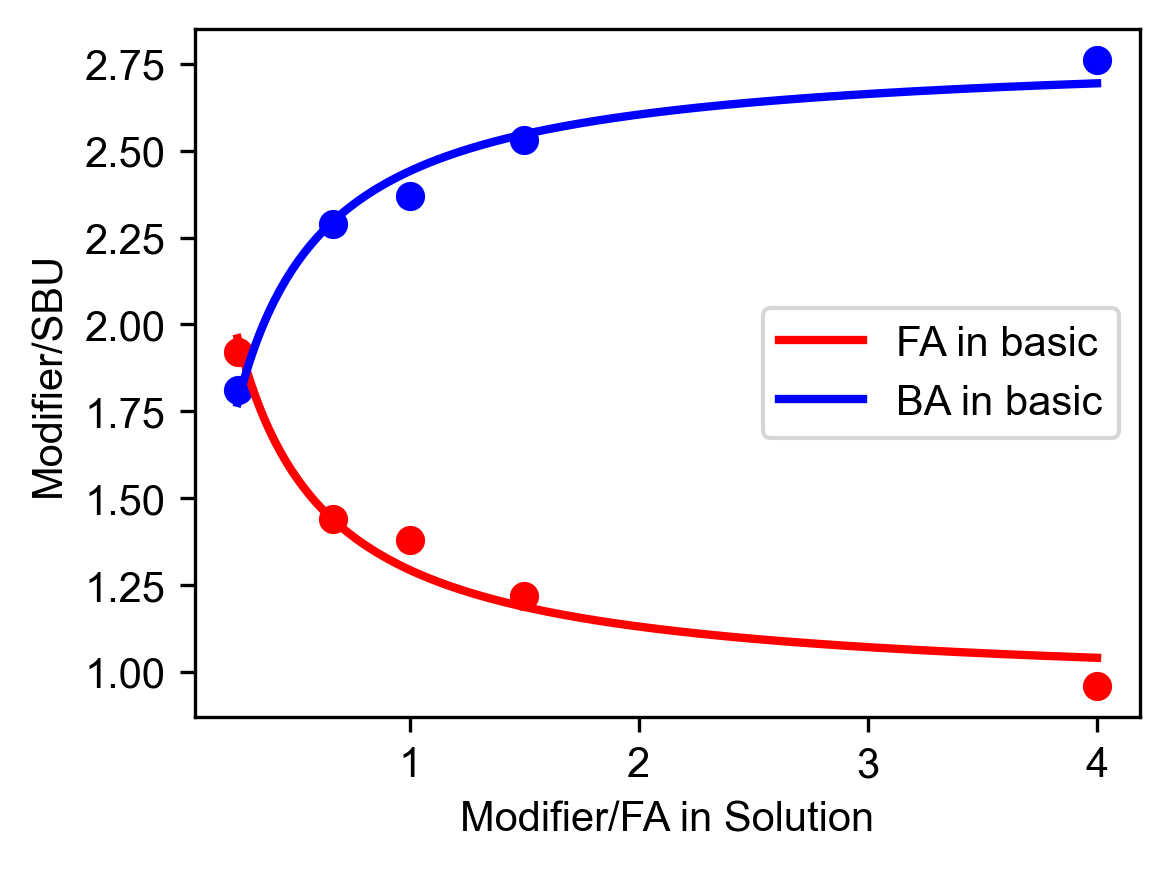

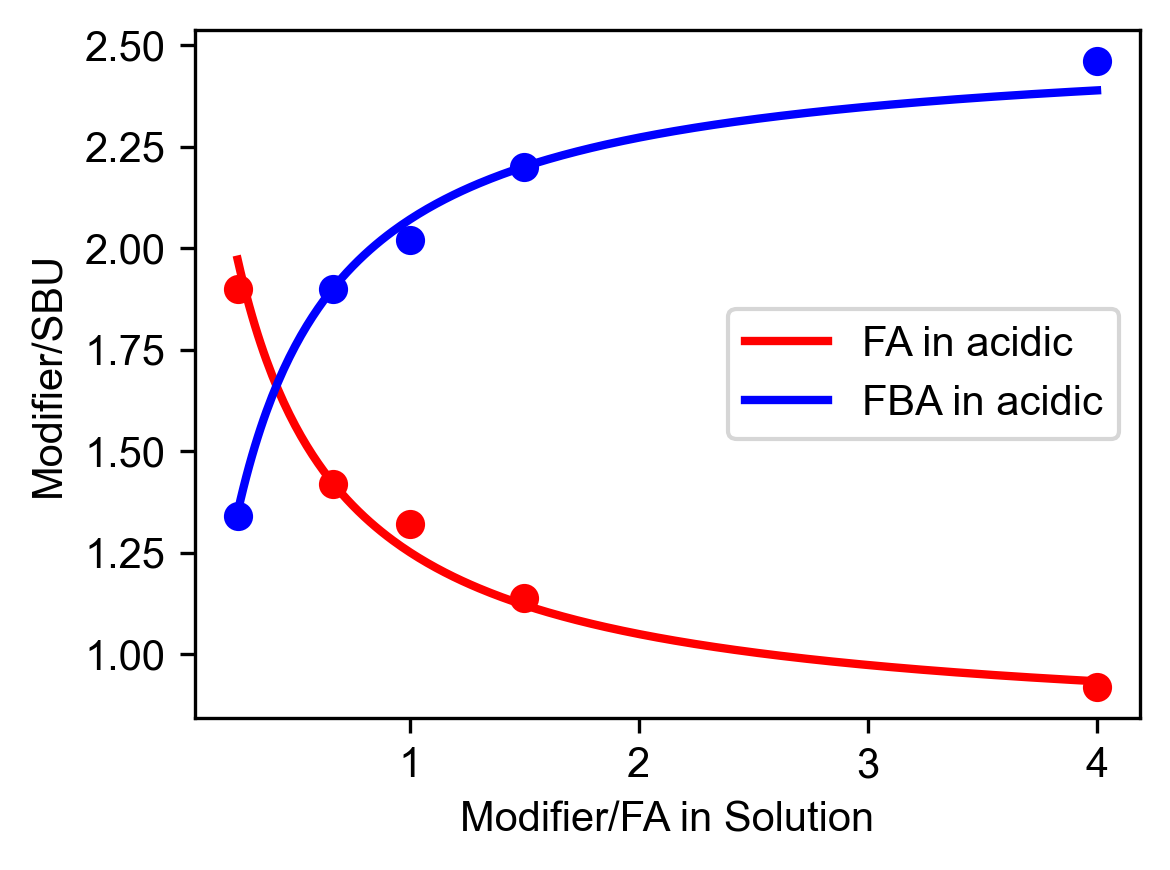

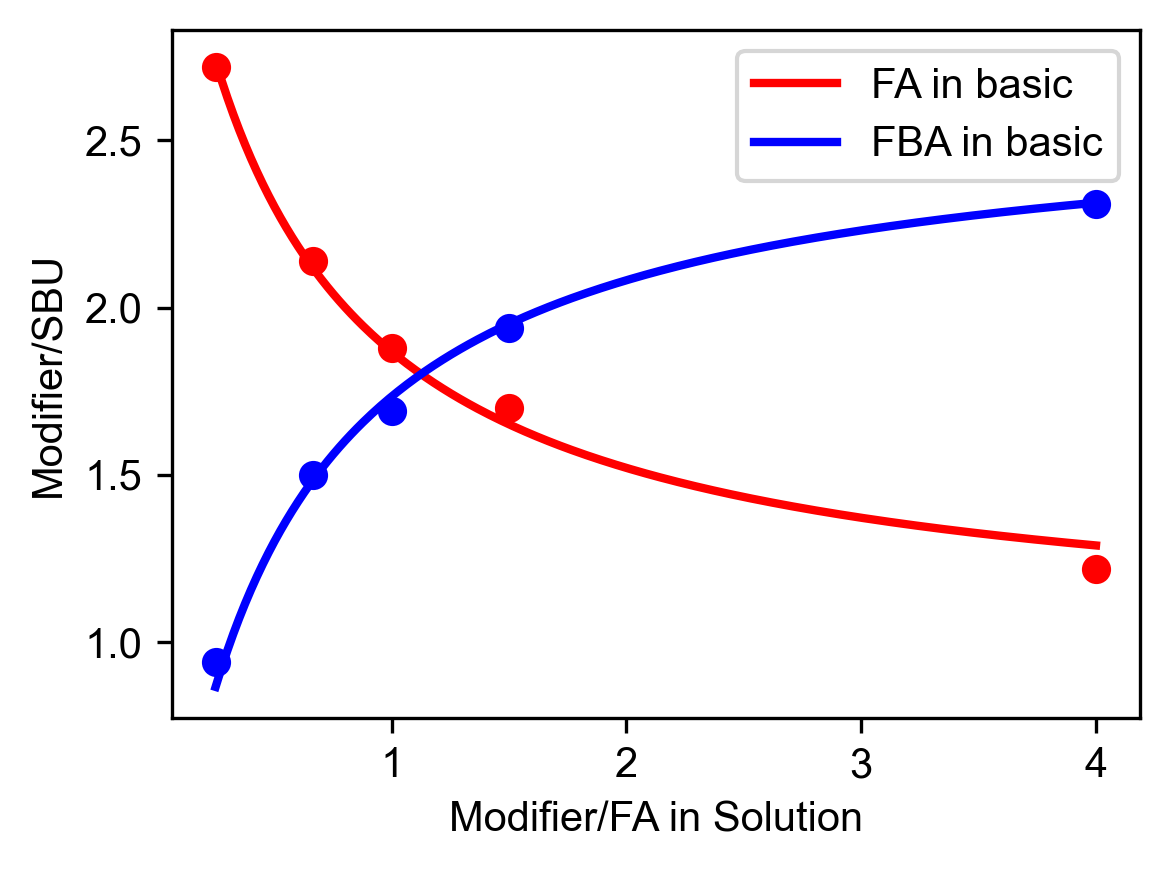

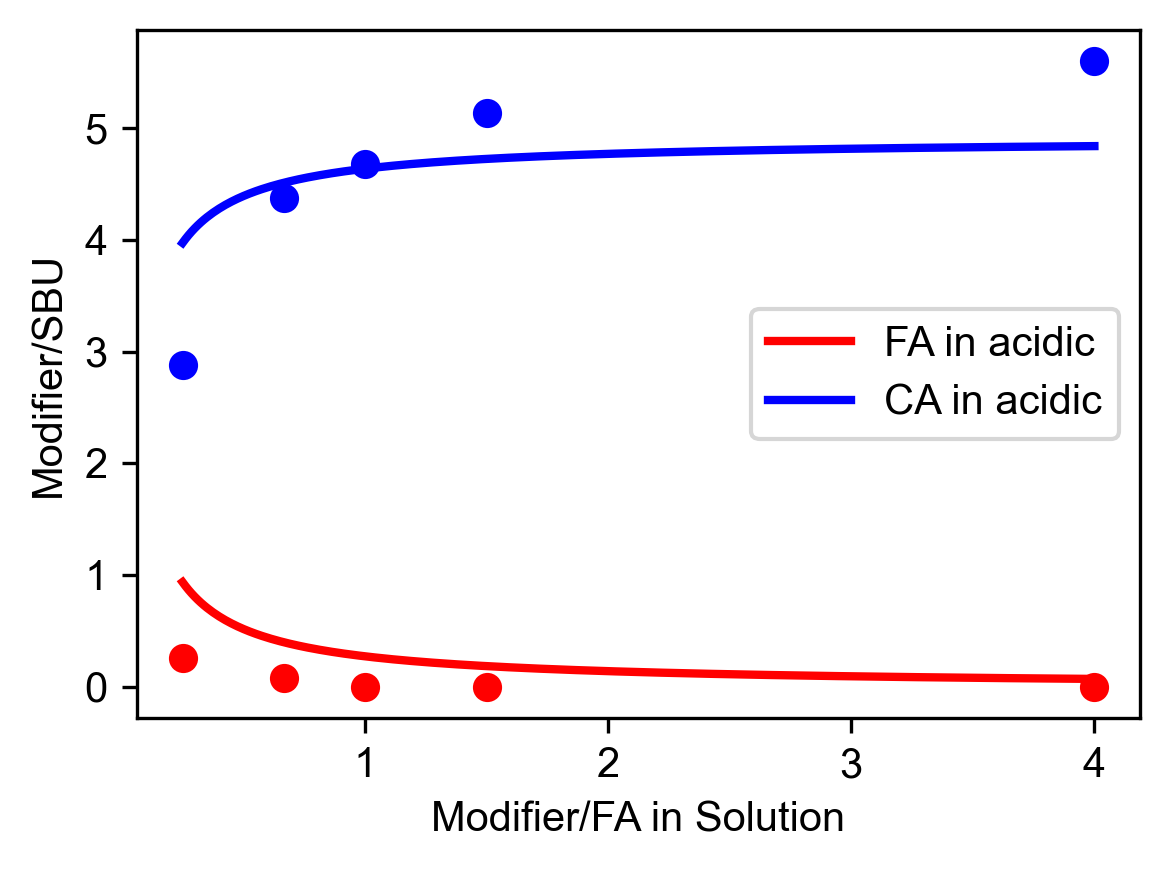

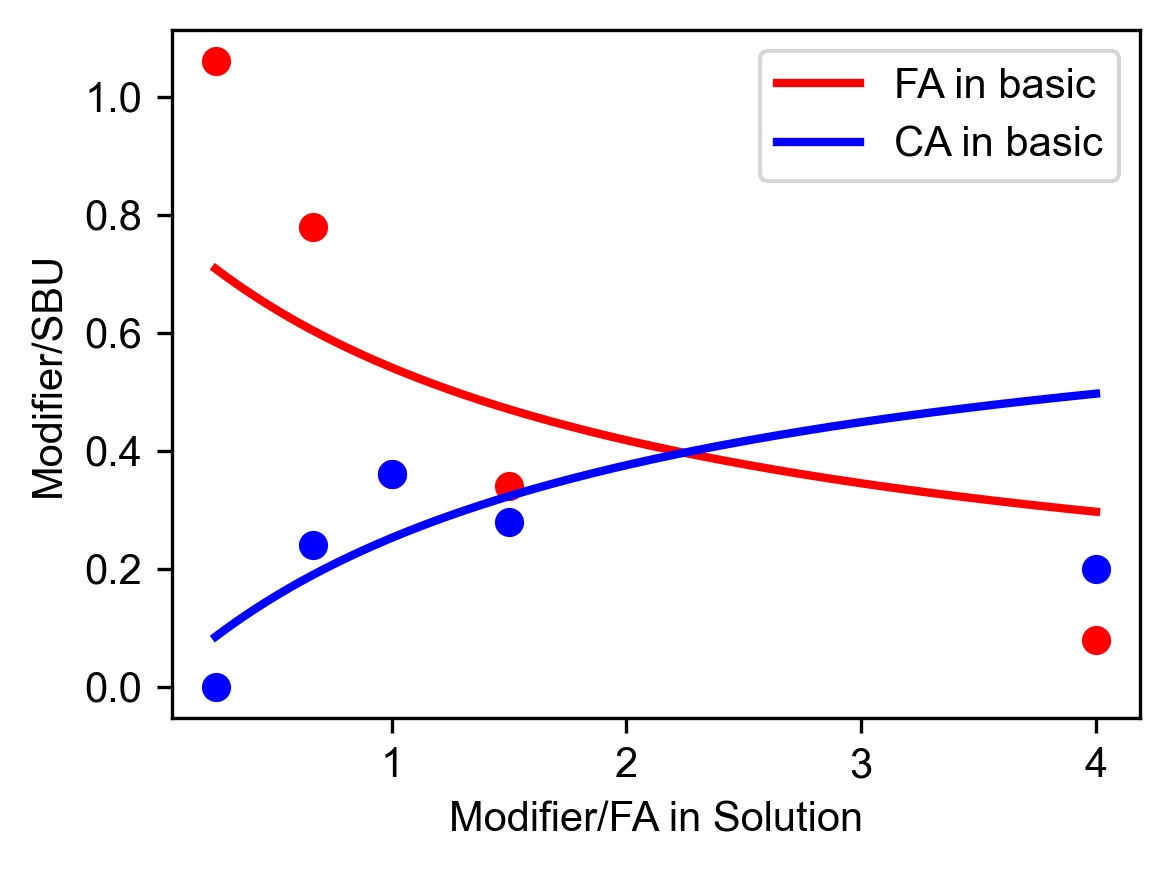

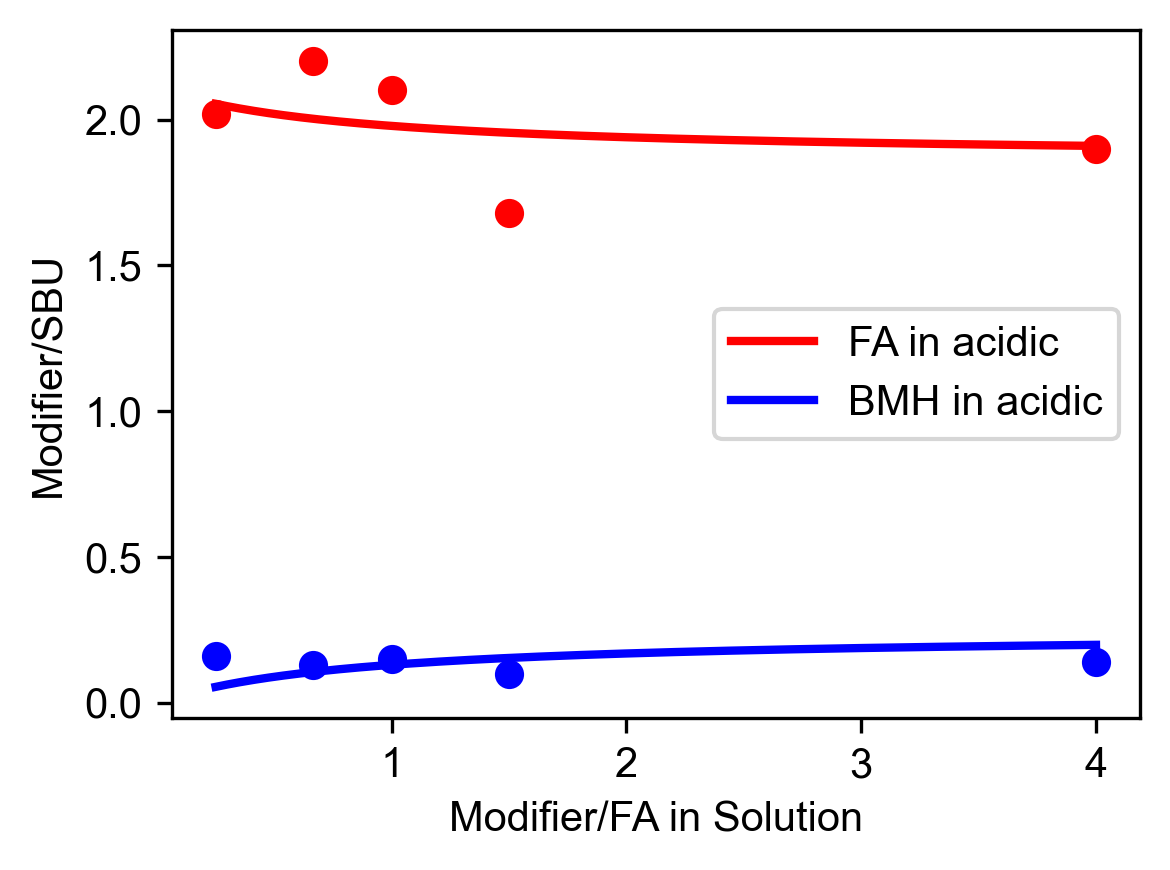

In [11]:
# -----------------------------
# Fit and collect summary
# -----------------------------
summary = []
unique_acid = df["Acid"].unique()

for acid_temp in unique_acid:
    df_by_acid = df[df["Acid"] == acid_temp]
    for experiment_type in df_by_acid["Experiment"].unique():
        try:
            this_curve = df_by_acid[df_by_acid["Experiment"] == experiment_type]
            x = this_curve["Acid conc (mM)"] / this_curve["FA conc (mM)"]
            y1 = this_curve["FA/SBU"].values
            y2 = this_curve["acid/SBU"].values

            popt, pcov = fit_two_curves_shared(x, y1, x, y2, p0=(3., 3.0, 10.), bounds=([0, 0, 0], [6, 6, np.inf]))

            x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 300)
            y_fit = _two_curve_model(np.concatenate((x_fit, x_fit)), len(x_fit), *popt)

            fig, ax = plt.subplots(figsize=(4, 3), dpi = 300)
            ax.plot(x_fit, y_fit[:len(x_fit)], label=f"FA in {experiment_type}", linewidth=2, color = "red")
            ax.plot(x_fit, y_fit[len(x_fit):], label=f"{acid_temp} in {experiment_type}", linewidth=2, color = "blue")
            
            ax.scatter(x, y1, color = "red")
            ax.scatter(x, y2, color = "blue")
            
            ax.set_xlabel(f'Modifier/FA in Solution')
            ax.set_ylabel(f'Modifier/SBU')
            ax.legend(loc='upper left')
            
            ax.legend()
            plt.tight_layout()
            plt.show()

            summary.append({
                "Acid": acid_temp,
                "Experiment": experiment_type,
                "A": popt[0],
                "B": popt[1],
                "k": popt[2]
            })

        except Exception as e:
            print(acid_temp, experiment_type)
            summary.append({
                "Acid": acid_temp,
                "Experiment": experiment_type,
                "Error": str(e)
            })

summary_df = pd.DataFrame(summary)

In [12]:
display(summary1)

,Acid,Experiment,A,mean_A,std_A,B,mean_B,std_B,percentage,k
0,TFA,acidic,"[3.03, 2.99, 2.94, 3.13, 3.08]",3.03,0.07,"[0.37, 0.37, 0.36, 0.39, 0.38]",0.38,0.01,8.898450e-01,2.986677e+01
1,TFA,basic,"[0.0, 0.0, 0.0, 0.0, 0.0]",0.00,0.00,"[3.46, 3.6, 3.58, 3.64, 3.74]",3.60,0.09,1.046124e-27,3.501839e-01
2,TA,acidic,"[2.61, 2.57, 2.59, 2.53, 2.55]",2.57,0.03,"[0.19, 0.19, 0.19, 0.19, 0.19]",0.19,0.00,9.312271e-01,2.197497e+01
3,TA,basic,"[2.34, 2.42, 2.49, 2.46, 2.42]",2.43,0.05,"[0.46, 0.48, 0.49, 0.48, 0.48]",0.48,0.01,8.357592e-01,2.331270e+00
4,SA,acidic,"[2.88, 2.88, 2.86, 2.94, 2.79]",2.87,0.05,"[0.56, 0.56, 0.56, 0.58, 0.55]",0.56,0.01,8.362885e-01,1.152656e+01
5,SA,basic,"[2.08, 2.11, 2.13, 2.07, 2.15]",2.11,0.03,"[1.67, 1.69, 1.7, 1.66, 1.72]",1.69,0.02,5.553972e-01,9.299314e-01
6,PA,acidic,"[1.78, 1.8, 1.85, 1.88, 1.69]",1.80,0.06,"[0.48, 0.48, 0.49, 0.5, 0.45]",0.48,0.02,7.893703e-01,3.021005e+00
7,NFA,acidic,"[3.72, 3.74, 3.56, 3.56, 3.61]",3.64,0.08,"[0.4, 0.4, 0.38, 0.38, 0.39]",0.39,0.01,9.026122e-01,3.812536e+01
8,NFA,basic,"[0.0, 0.0, 0.0, 0.0, 0.0]",0.00,0.00,"[3.42, 3.6, 3.5, 3.58, 3.6]",3.54,0.07,1.046124e-27,3.501839e-01
9,MA,acidic,"[2.2, 2.25, 2.05, 2.03, 2.3]",2.16,0.11,"[0.09, 0.09, 0.08, 0.08, 0.09]",0.09,0.00,9.609873e-01,2.150377e+01


In [13]:
display(summary_df)

,Acid,Experiment,A,B,k
0,TFA,acidic,2.999279,4.087069e-01,40.457771
1,TFA,basic,3.632548,3.016394e-08,0.005373
2,TA,acidic,2.558390,2.015369e-01,25.636687
3,TA,basic,2.264213,6.347594e-01,3.280415
4,SA,acidic,2.810547,6.211158e-01,16.158398
5,SA,basic,2.045675,1.737817e+00,1.001525
6,PA,acidic,1.721864,5.568682e-01,3.960420
7,NFA,acidic,3.635948,3.919866e-01,39.518879
8,NFA,basic,3.560157,1.613848e-10,0.003856
9,MA,acidic,2.161628,9.011570e-02,18.831399


In [14]:
# get rid of the last two messy points 

# summary_df = summary_df.iloc[:-2]
# summary1 = summary1.iloc[:-2]

In [15]:
# Save the summary dataframe to a CSV file
summary_df.to_csv('summary_data.csv', index=False)
print(f"Summary data saved to 'summary_data.csv'")


Summary data saved to 'summary_data.csv'


In [16]:
df[(df['Acid'] == "TFA") & (df['Experiment'] == "basic")]

,Acid,Experiment,Acid conc (mM),FA conc (mM),acid/SBU,FA/SBU
5,TFA,basic,180.0,45.0,0.0,3.46
6,TFA,basic,135.0,90.0,0.0,3.60
7,TFA,basic,112.5,112.5,0.0,3.58
8,TFA,basic,90.0,135.0,0.0,3.64
9,TFA,basic,45.0,180.0,0.0,3.74


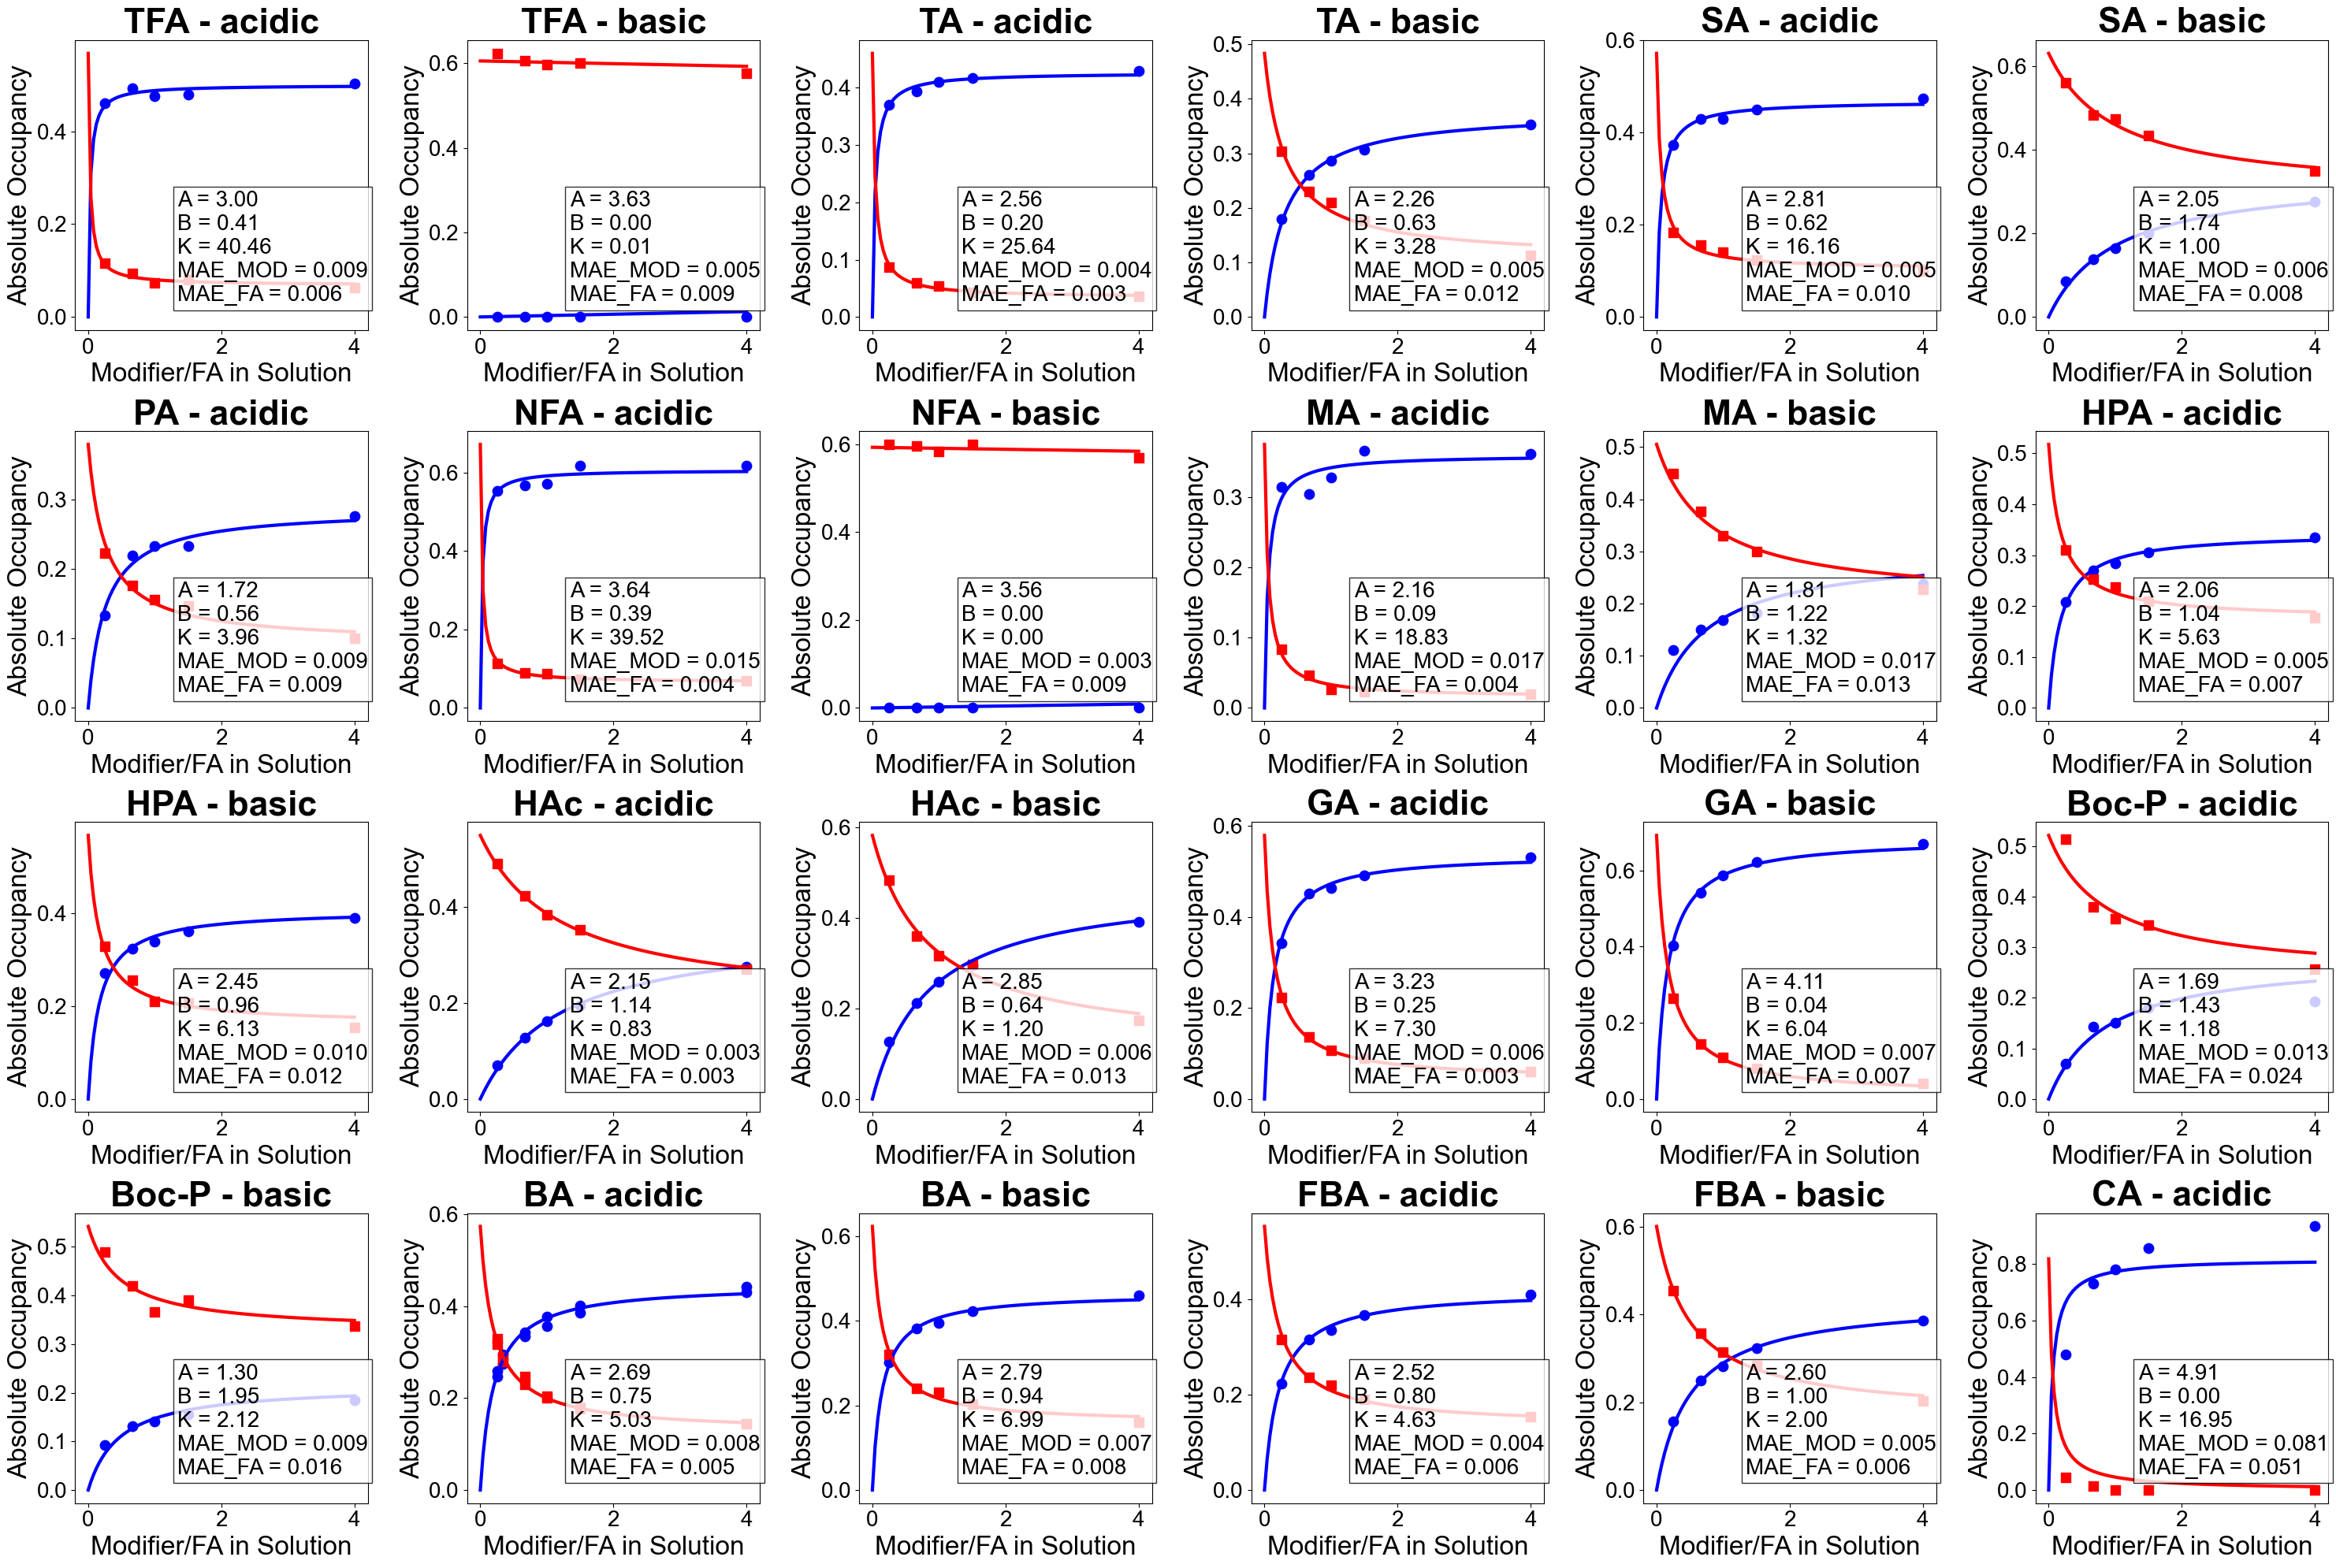

In [23]:
# Create a large plot of the two-curve fitting results for ratio fitting
fig, axes = plt.subplots(4, 6, figsize=(30, 20))
axes = axes.flatten()

# Get the data from summary_df
acids = summary_df['Acid'].unique()

# Counter for subplot position
plot_idx = 0

# Define legend elements for reuse across all subplots
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', label='Modifier Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='red', marker='s', label='Formate Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='blue', linestyle='-', label='Fitted Modifier', linewidth=3),
    plt.Line2D([0], [0], color='red', linestyle='-', label='Fitted Formate', linewidth=3)
]

for acid in acids:
    acid_data = summary_df[summary_df['Acid'] == acid]
    
    if acid == 'BMH':
        continue
        
    for _, row in acid_data.iterrows():
        if plot_idx >= len(axes):
            break
            
        ax = axes[plot_idx]
        
        try:
            A = row['A']
            B = row['B']
            k = row['k']
            experiment_type = row['Experiment']
            
            exp_data = df[(df['Acid'] == acid) & (df['Experiment'] == experiment_type)]
            
            if not exp_data.empty:
                x_exp = exp_data['Acid conc (mM)'].values / exp_data['FA conc (mM)'].values
                y_exp_modifier = exp_data['acid/SBU'].values / 6
                y_exp_formate  = exp_data['FA/SBU'].values / 6

                ax.scatter(x_exp, y_exp_modifier, color='blue', marker='o', s=80)
                ax.scatter(x_exp, y_exp_formate,  color='red', marker='s', s=80)
                
                x_fit = np.linspace(0, 4, 100)
                xcat = np.concatenate((x_fit, x_fit))
                n1 = len(x_fit)
                y_fit = _two_curve_model(xcat, n1, A, B, k) / 6
                y_fit_formate, y_fit_modifier = y_fit[:n1], y_fit[n1:]
                
                ax.plot(x_fit, y_fit_modifier, 'b-', linewidth=3.0)
                ax.plot(x_fit, y_fit_formate, 'r-', linewidth=3.0)
                
                # ---- Compute residuals and R² ----
                y_pred_modifier = np.interp(x_exp, x_fit, y_fit_modifier)
                y_pred_formate  = np.interp(x_exp, x_fit, y_fit_formate)

                residual_modifier = abs(y_exp_modifier - y_pred_modifier)
                residual_formate  = abs(y_exp_formate - y_pred_formate)

                ss_res_mod = np.sum(residual_modifier**2)
                ss_tot_mod = np.sum((y_exp_modifier - np.mean(y_exp_modifier))**2)
                r2_modifier = 1 - ss_res_mod/ss_tot_mod if ss_tot_mod != 0 else np.nan

                ss_res_for = np.sum(residual_formate**2)
                ss_tot_for = np.sum((y_exp_formate - np.mean(y_exp_formate))**2)
                r2_formate = 1 - ss_res_for/ss_tot_for if ss_tot_for != 0 else np.nan

                # ---- Store residuals and R² values in summary_df ----
                summary_df.loc[row.name, 'Residual Modifier'] = residual_modifier.mean()  # Store mean residuals
                summary_df.loc[row.name, 'Residual Formate'] = residual_formate.mean()      # Store mean residuals
                summary_df.loc[row.name, 'R² Modifier'] = r2_modifier
                summary_df.loc[row.name, 'R² Formate'] = r2_formate

                # ---- Add results as text on the plot ----
                k_text = f"{k:.2e}" if k > 1000 else f"{k:.2f}"
                param_text = (
                    f"A = {A:.2f}\n"
                    f"B = {B:.2f}\n"
                    f"K = {k_text}\n"
                    f"MAE_MOD = {residual_modifier.mean():.3f}\n"
                    f"MAE_FA = {residual_formate.mean():.3f}"
                )
                ax.text(0.35, 0.10, param_text, transform=ax.transAxes,
                        bbox=dict(facecolor='white', alpha=0.8), fontsize=20)
                
            ax.set_title(f"{acid} - {experiment_type}", fontsize=32, fontweight='bold')
            ax.set_xlabel('Modifier/FA in Solution', fontsize=24)
            ax.set_ylabel('Absolute Occupancy', fontsize=24)
            ax.tick_params(axis='both', which='major', labelsize=20)

            plot_idx += 1
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', transform=ax.transAxes, fontsize=14)
            plot_idx += 1

# Hide any unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [18]:
acids

array(['TFA', 'TA', 'SA', 'PA', 'NFA', 'MA', 'HPA', 'HAc', 'GA', 'Boc-P',
       'BA', 'FBA', 'CA', 'BMH'], dtype=object)

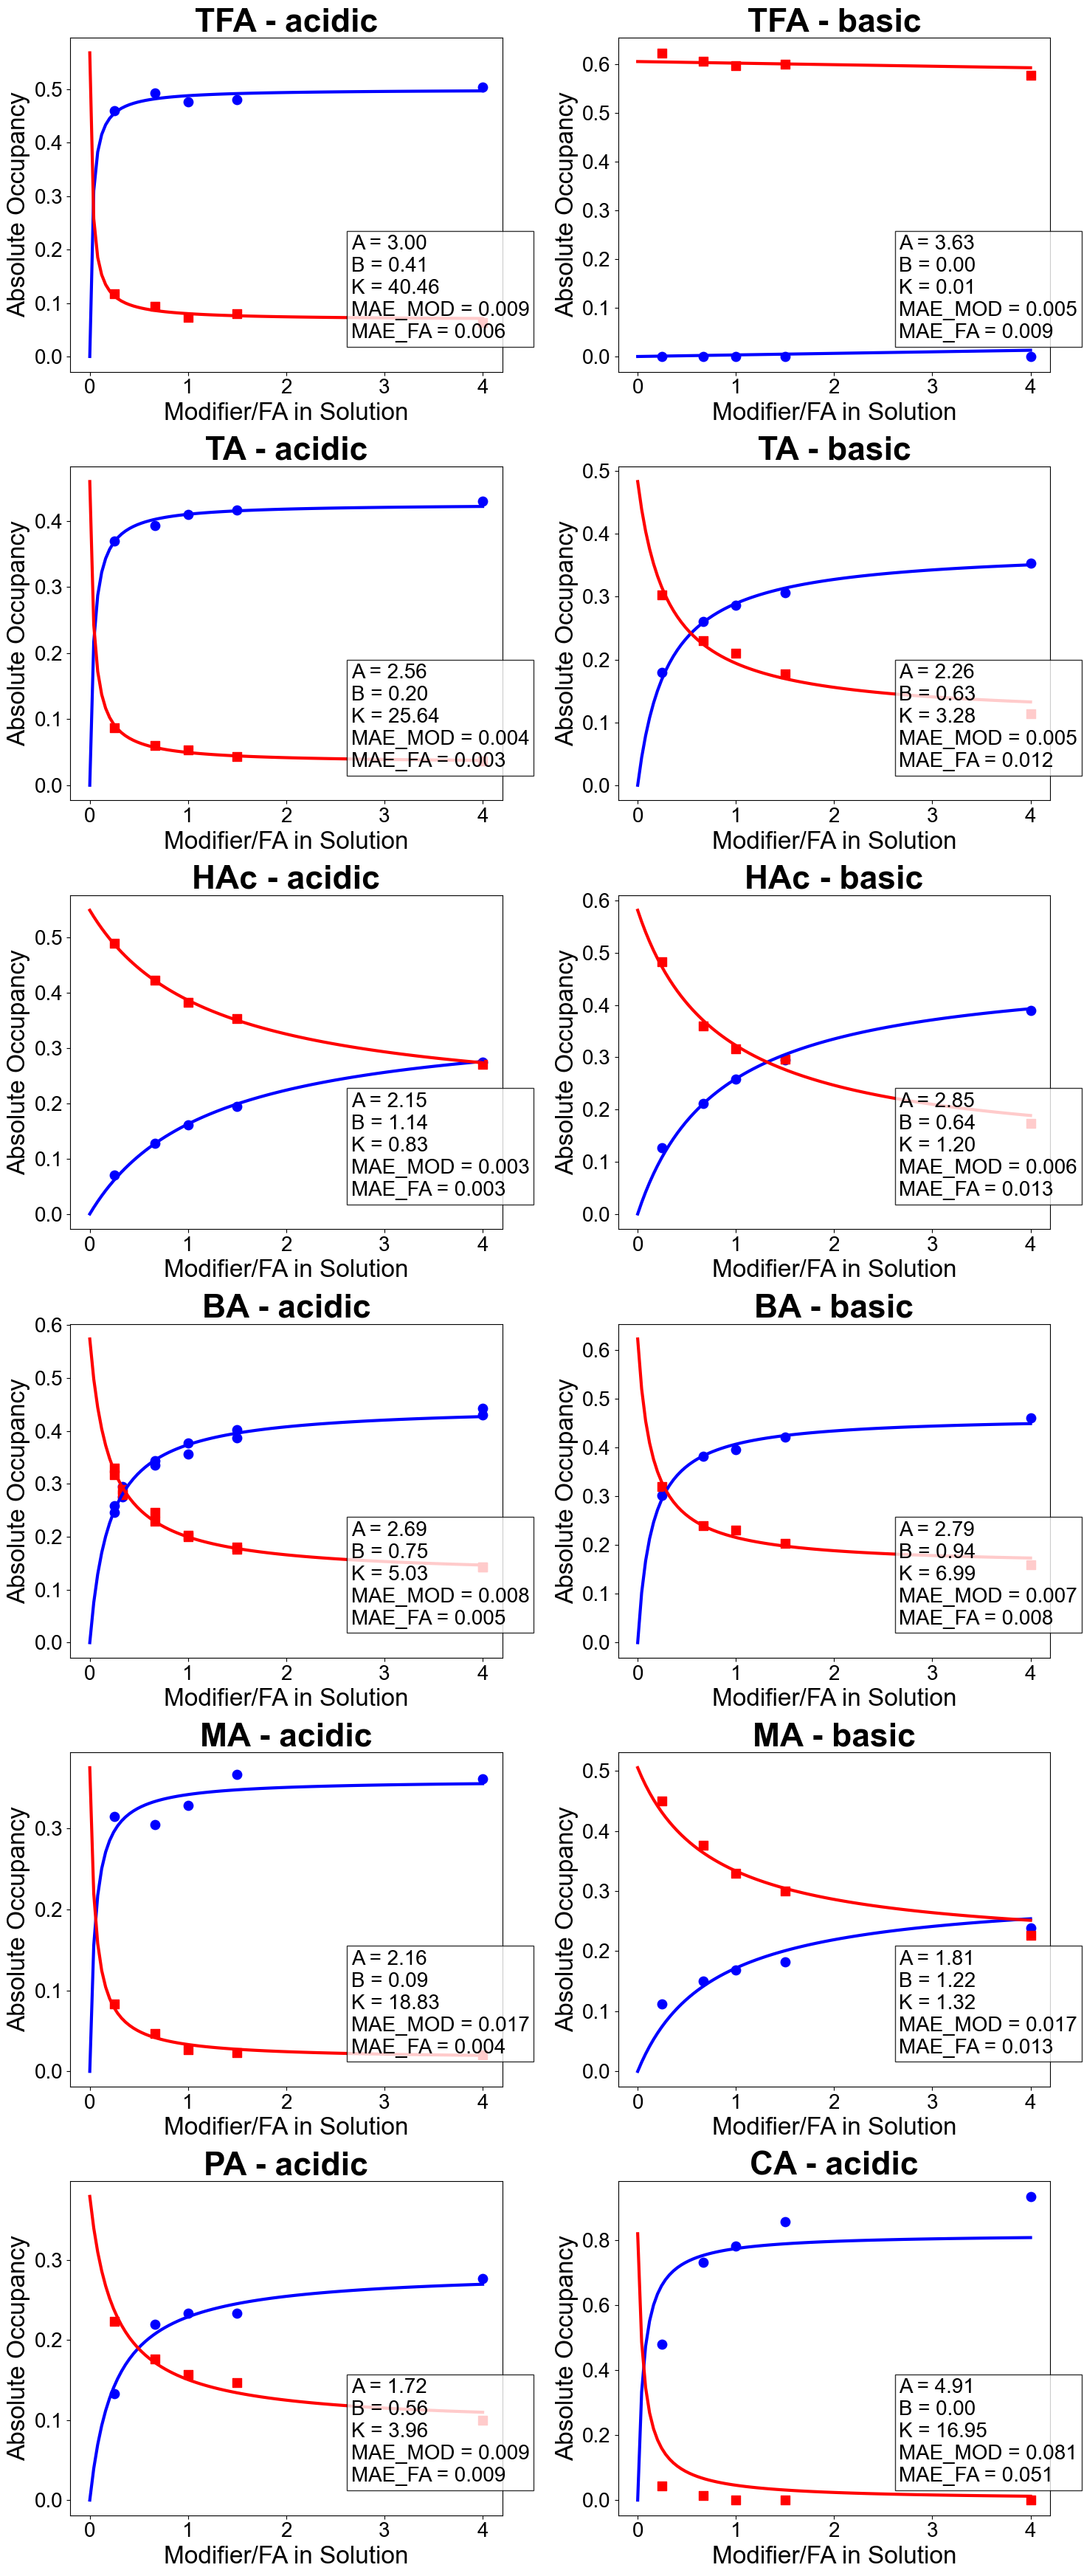

In [19]:
# Create a large plot of the two-curve fitting results for ratio fitting
fig, axes = plt.subplots(6, 2, figsize=(15, 35))
axes = axes.flatten()

# Get the data from summary_df
acids = ["TFA", "TA", "HAc", "BA", "MA", "PA", "CA"]

# Counter for subplot position
plot_idx = 0

# Define legend elements for reuse across all subplots
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', label='Modifier Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='red', marker='s', label='Formate Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='blue', linestyle='-', label='Fitted Modifier', linewidth=3),
    plt.Line2D([0], [0], color='red', linestyle='-', label='Fitted Formate', linewidth=3)
]

for acid in acids:
    acid_data = summary_df[summary_df['Acid'] == acid]
    
    if acid == 'BMH':
        continue
        
    for _, row in acid_data.iterrows():
        if plot_idx >= len(axes):
            break
            
        ax = axes[plot_idx]
        
        try:
            A = row['A']
            B = row['B']
            k = row['k']
            experiment_type = row['Experiment']
            
            exp_data = df[(df['Acid'] == acid) & (df['Experiment'] == experiment_type)]
            
            if not exp_data.empty:
                x_exp = exp_data['Acid conc (mM)'].values / exp_data['FA conc (mM)'].values
                y_exp_modifier = exp_data['acid/SBU'].values / 6
                y_exp_formate  = exp_data['FA/SBU'].values / 6

                ax.scatter(x_exp, y_exp_modifier, color='blue', marker='o', s=80)
                ax.scatter(x_exp, y_exp_formate,  color='red', marker='s', s=80)
                
                x_fit = np.linspace(0, 4, 100)
                xcat = np.concatenate((x_fit, x_fit))
                n1 = len(x_fit)
                y_fit = _two_curve_model(xcat, n1, A, B, k) / 6
                y_fit_formate, y_fit_modifier = y_fit[:n1], y_fit[n1:]
                
                ax.plot(x_fit, y_fit_modifier, 'b-', linewidth=3.0)
                ax.plot(x_fit, y_fit_formate, 'r-', linewidth=3.0)
                
                # ---- Compute residuals and R² ----
                y_pred_modifier = np.interp(x_exp, x_fit, y_fit_modifier)
                y_pred_formate  = np.interp(x_exp, x_fit, y_fit_formate)

                residual_modifier = abs(y_exp_modifier - y_pred_modifier)
                residual_formate  = abs(y_exp_formate - y_pred_formate)

                ss_res_mod = np.sum(residual_modifier**2)
                ss_tot_mod = np.sum((y_exp_modifier - np.mean(y_exp_modifier))**2)
                r2_modifier = 1 - ss_res_mod/ss_tot_mod if ss_tot_mod != 0 else np.nan

                ss_res_for = np.sum(residual_formate**2)
                ss_tot_for = np.sum((y_exp_formate - np.mean(y_exp_formate))**2)
                r2_formate = 1 - ss_res_for/ss_tot_for if ss_tot_for != 0 else np.nan

                # ---- Store residuals and R² values in summary_df ----
                summary_df.loc[row.name, 'Residual Modifier'] = residual_modifier.mean()  # Store mean residuals
                summary_df.loc[row.name, 'Residual Formate'] = residual_formate.mean()      # Store mean residuals
                summary_df.loc[row.name, 'R² Modifier'] = r2_modifier
                summary_df.loc[row.name, 'R² Formate'] = r2_formate

                # ---- Add results as text on the plot ----
                k_text = f"{k:.2e}" if k > 1000 else f"{k:.2f}"
                param_text = (
                    f"A = {A:.2f}\n"
                    f"B = {B:.2f}\n"
                    f"K = {k_text}\n"
                    f"MAE_MOD = {residual_modifier.mean():.3f}\n"
                    f"MAE_FA = {residual_formate.mean():.3f}"
                )
                ax.text(0.65, 0.10, param_text, transform=ax.transAxes,
                        bbox=dict(facecolor='white', alpha=0.8), fontsize=20)
                
            ax.set_title(f"{acid} - {experiment_type}", fontsize=32, fontweight='bold')
            ax.set_xlabel('Modifier/FA in Solution', fontsize=24)
            ax.set_ylabel('Absolute Occupancy', fontsize=24)
            ax.tick_params(axis='both', which='major', labelsize=20)

            plot_idx += 1
            
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center', transform=ax.transAxes, fontsize=14)
            plot_idx += 1

# Hide any unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


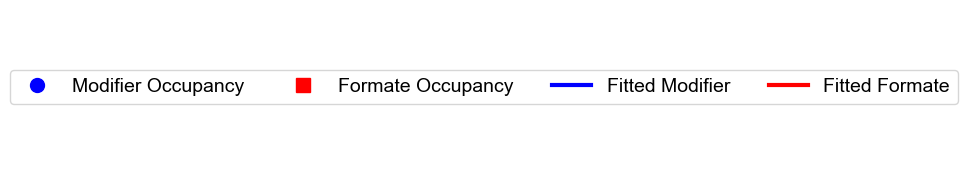

In [20]:
import matplotlib.pyplot as plt

# Define legend elements
legend_elements = [
    plt.Line2D([0], [0], color='blue', marker='o', label='Modifier Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='red', marker='s', label='Formate Occupancy', markersize=10, linestyle=''),
    plt.Line2D([0], [0], color='blue', linestyle='-', label='Fitted Modifier', linewidth=3),
    plt.Line2D([0], [0], color='red', linestyle='-', label='Fitted Formate', linewidth=3)
]

# Create a new figure for the legend
fig = plt.figure(figsize=(6, 2))

# Plot the legend alone
plt.legend(handles=legend_elements, loc='center', fontsize=14, ncol=4)

# Hide axes and ticks since it's just a legend
plt.axis('off')

# Display the figure with the legend
plt.show()


In [21]:
summary1 = summary1[summary1["Acid"] != "BMH"].reindex()
summary_df = summary_df[summary_df["Acid"] != "BMH"].reindex()

In [18]:
display(summary1)
display(summary_df)

,Acid,Experiment,A,mean_A,std_A,B,mean_B,std_B,percentage,k
0,TFA,acidic,"[3.03, 2.99, 2.94, 3.13, 3.08]",3.03,0.07,"[0.37, 0.37, 0.36, 0.39, 0.38]",0.38,0.01,8.898450e-01,29.866765
1,TFA,basic,"[0.0, 0.0, 0.0, 0.0, 0.0]",0.00,0.00,"[3.46, 3.6, 3.58, 3.64, 3.74]",3.60,0.09,1.046124e-27,0.350184
2,TA,acidic,"[2.61, 2.57, 2.59, 2.53, 2.55]",2.57,0.03,"[0.19, 0.19, 0.19, 0.19, 0.19]",0.19,0.00,9.312271e-01,21.974966
3,TA,basic,"[2.34, 2.42, 2.49, 2.46, 2.42]",2.43,0.05,"[0.46, 0.48, 0.49, 0.48, 0.48]",0.48,0.01,8.357592e-01,2.331270
4,SA,acidic,"[2.88, 2.88, 2.86, 2.94, 2.79]",2.87,0.05,"[0.56, 0.56, 0.56, 0.58, 0.55]",0.56,0.01,8.362885e-01,11.526557
5,SA,basic,"[2.08, 2.11, 2.13, 2.07, 2.15]",2.11,0.03,"[1.67, 1.69, 1.7, 1.66, 1.72]",1.69,0.02,5.553972e-01,0.929931
6,PA,acidic,"[1.78, 1.8, 1.85, 1.88, 1.69]",1.80,0.06,"[0.48, 0.48, 0.49, 0.5, 0.45]",0.48,0.02,7.893703e-01,3.021005
7,NFA,acidic,"[3.72, 3.74, 3.56, 3.56, 3.61]",3.64,0.08,"[0.4, 0.4, 0.38, 0.38, 0.39]",0.39,0.01,9.026122e-01,38.125363
8,NFA,basic,"[0.0, 0.0, 0.0, 0.0, 0.0]",0.00,0.00,"[3.42, 3.6, 3.5, 3.58, 3.6]",3.54,0.07,1.046124e-27,0.350184
9,MA,acidic,"[2.2, 2.25, 2.05, 2.03, 2.3]",2.16,0.11,"[0.09, 0.09, 0.08, 0.08, 0.09]",0.09,0.00,9.609873e-01,21.503766


,Acid,Experiment,A,B,k,Residual Modifier,Residual Formate,R² Modifier,R² Formate
0,TFA,acidic,2.999279,4.087069e-01,40.457771,0.000033,-3.112258e-05,0.579560,0.889344
1,TFA,basic,3.632548,3.016394e-08,0.005373,-0.004758,-2.318337e-07,NaN,0.431371
2,TA,acidic,2.558390,2.015369e-01,25.636687,0.000049,-3.655659e-05,0.928853,0.969591
3,TA,basic,2.264213,6.347594e-01,3.280415,0.000884,-4.621859e-05,0.989953,0.958596
4,SA,acidic,2.810547,6.211158e-01,16.158398,0.000108,-5.197406e-05,0.949936,0.862267
5,SA,basic,2.045675,1.737817e+00,1.001525,0.002103,-1.795758e-05,0.982991,0.982369
6,PA,acidic,1.721864,5.568682e-01,3.960420,0.000249,-3.745968e-05,0.960062,0.937463
7,NFA,acidic,3.635948,3.919866e-01,39.518879,0.000049,-3.840393e-05,0.611619,0.903506
8,NFA,basic,3.560157,1.613848e-10,0.003856,-0.003359,-1.654798e-07,NaN,0.358054
9,MA,acidic,2.161628,9.011570e-02,18.831399,0.000080,-3.701652e-05,0.436413,0.960573


3. plot comparison of these two models

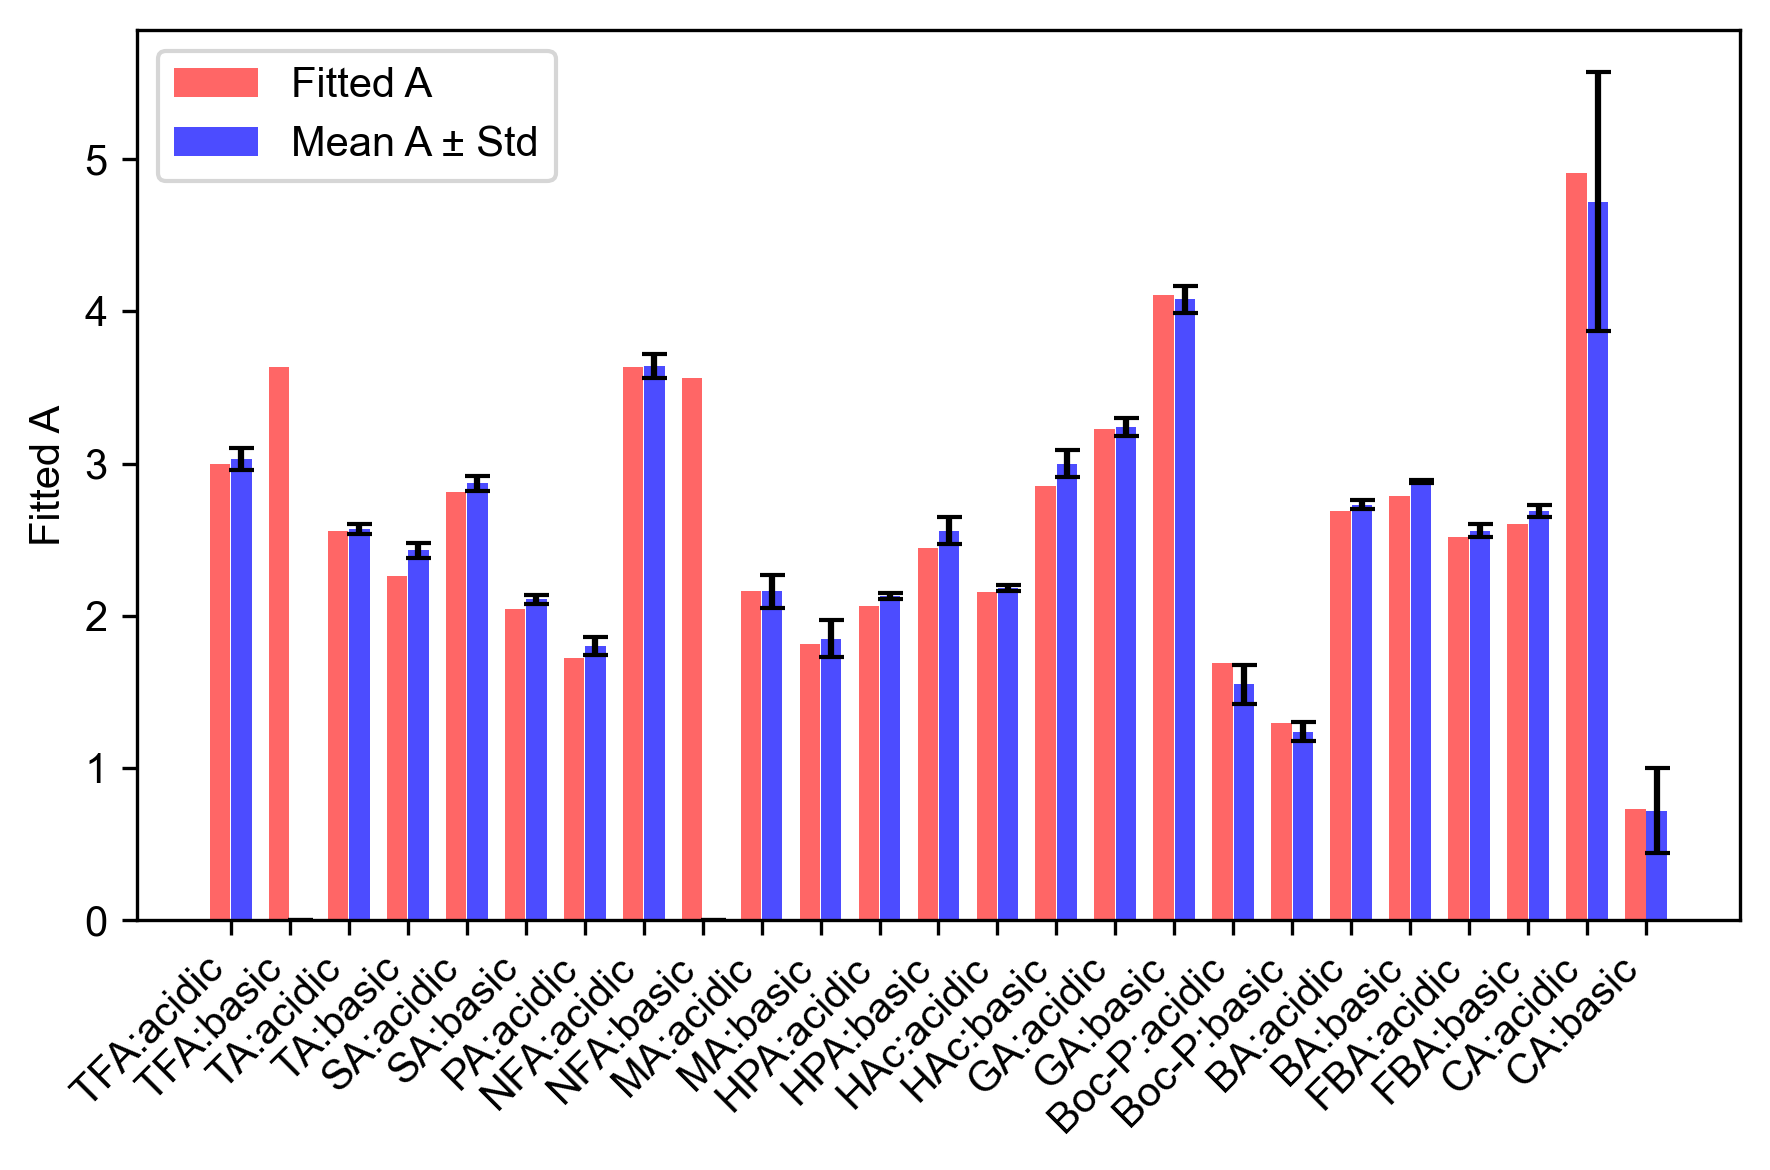

In [19]:
plt.figure(figsize=(6, 4), dpi=300)

# Filter summary_df to only include entries that are in summary1
filtered_df = summary_df[summary_df.index.isin(summary1.index)]

x_pos = np.arange(len(filtered_df))

# Set small offset
offset = 0.18
bar_width = 0.35

# Plot individual A values (red bars) slightly to the left
for i, (idx, row) in enumerate(filtered_df.iterrows()):
    if i < len(filtered_df) - 1:
        plt.bar(x=i - offset, height=row['A'], width=bar_width, color="red", alpha=0.6)
    else:
        plt.bar(x=i - offset, height=row['A'], width=bar_width, color="red", alpha=0.6, label="Fitted A")

# Plot mean A with std (blue bars) slightly to the right
plt.bar(
    x=x_pos + offset,
    height=summary1["mean_A"],
    yerr=summary1["std_A"],
    width=bar_width,
    color="blue",
    alpha=0.7,
    capsize=3,
    label="Mean A ± Std"
)

# Set x-axis labels
xtick_labels = filtered_df["Acid"] + ":" + filtered_df["Experiment"]
plt.xticks(ticks=x_pos, labels=xtick_labels, rotation=45, ha='right')
plt.ylabel("Fitted A")
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()

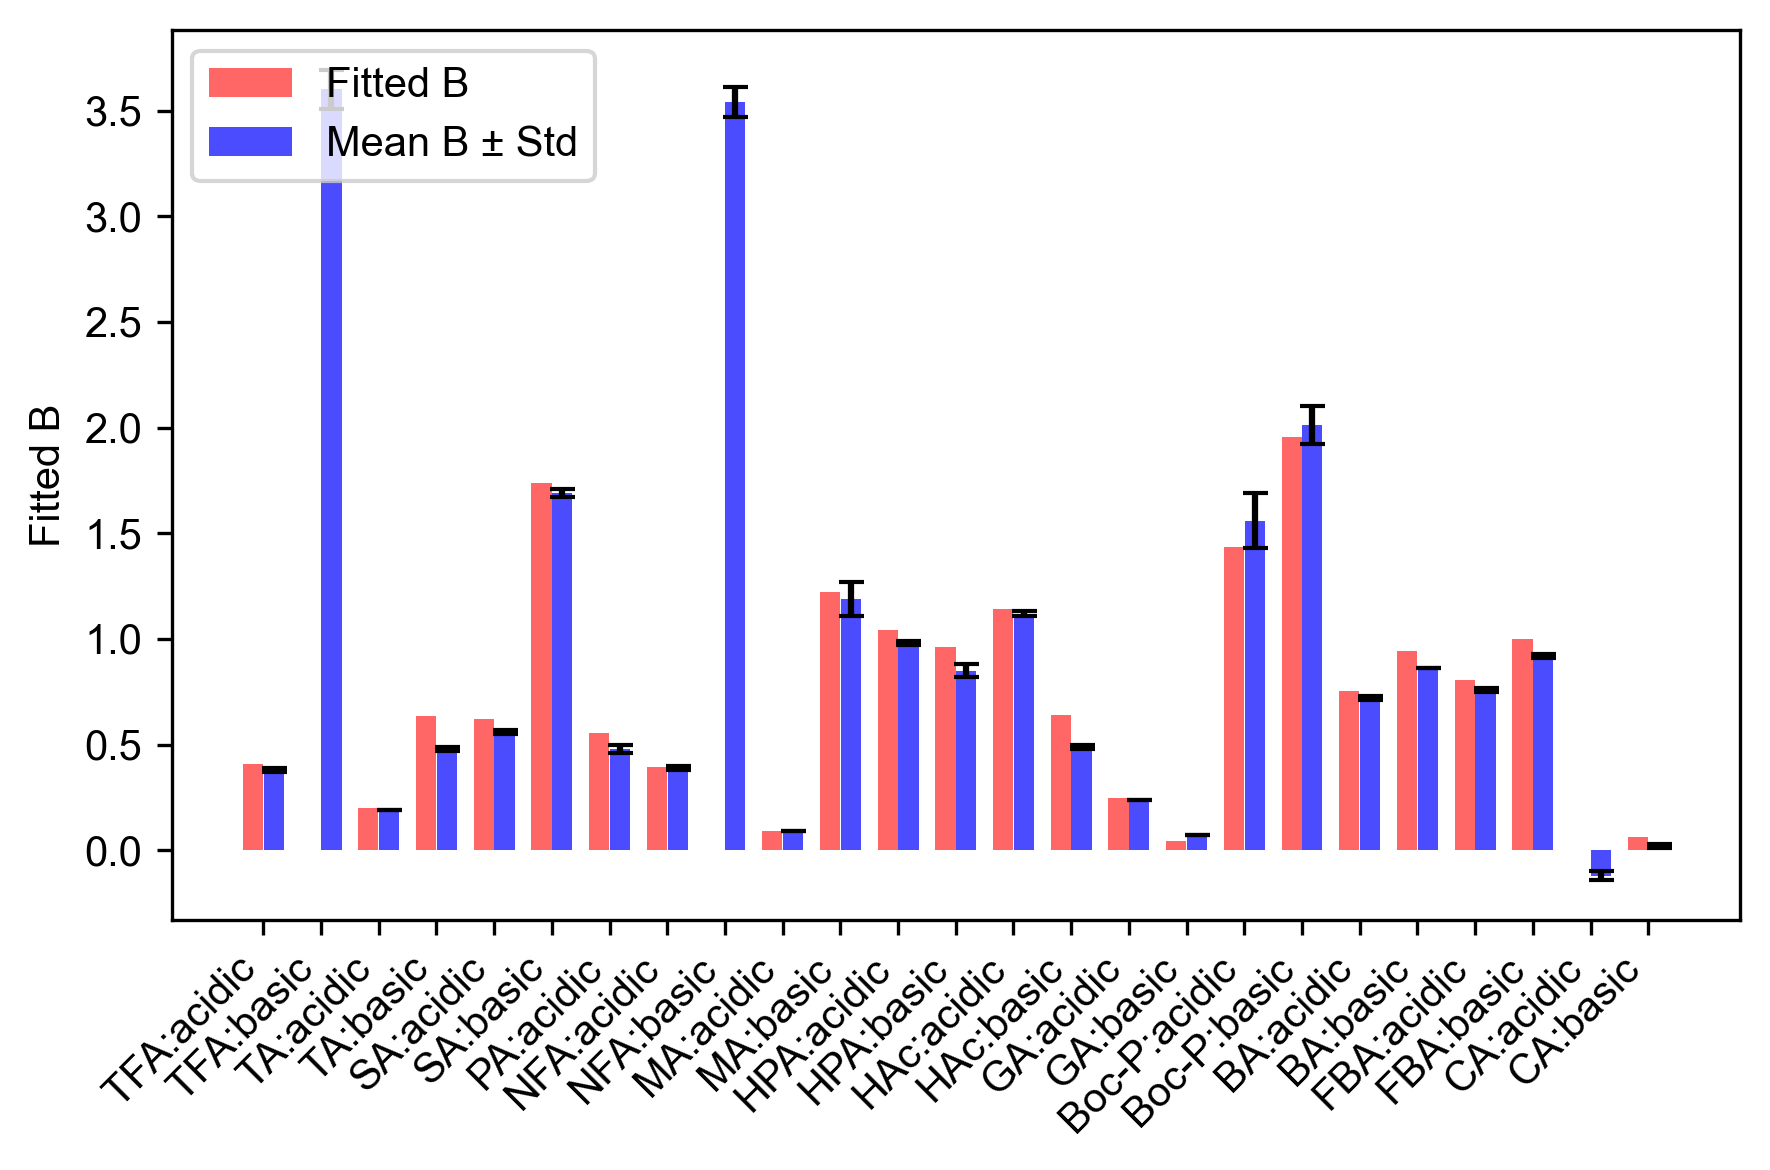

In [20]:
plt.figure(figsize=(6, 4), dpi=300)

# Filter summary_df to only include entries that are in summary1
filtered_df = summary_df[summary_df.index.isin(summary1.index)]

x_pos = np.arange(len(filtered_df))

# Set small offset
offset = 0.18
bar_width = 0.35

# Plot individual A values (red bars) slightly to the left
for i, (idx, row) in enumerate(filtered_df.iterrows()):
    if i < len(filtered_df) - 1:
        plt.bar(x=i - offset, height=row['B'], width=bar_width, color="red", alpha=0.6)
    else:
        plt.bar(x=i - offset, height=row['B'], width=bar_width, color="red", alpha=0.6, label="Fitted B")

# Plot mean A with std (blue bars) slightly to the right
plt.bar(
    x=x_pos + offset,
    height=summary1["mean_B"],
    yerr=summary1["std_B"],
    width=bar_width,
    color="blue",
    alpha=0.7,
    capsize=3,
    label="Mean B ± Std"
)

# Set x-axis labels
xtick_labels = filtered_df["Acid"] + ":" + filtered_df["Experiment"]
plt.xticks(ticks=x_pos, labels=xtick_labels, rotation=45, ha='right')
plt.ylabel("Fitted B")
plt.tight_layout()
plt.legend(loc="upper left")
plt.show()

In [21]:
summary_df

,Acid,Experiment,A,B,k
0,TFA,acidic,2.999279,4.087069e-01,40.457771
1,TFA,basic,3.632548,3.016394e-08,0.005373
2,TA,acidic,2.558390,2.015369e-01,25.636687
3,TA,basic,2.264213,6.347594e-01,3.280415
4,SA,acidic,2.810547,6.211158e-01,16.158398
5,SA,basic,2.045675,1.737817e+00,1.001525
6,PA,acidic,1.721864,5.568682e-01,3.960420
7,NFA,acidic,3.635948,3.919866e-01,39.518879
8,NFA,basic,3.560157,1.613848e-10,0.003856
9,MA,acidic,2.161628,9.011570e-02,18.831399


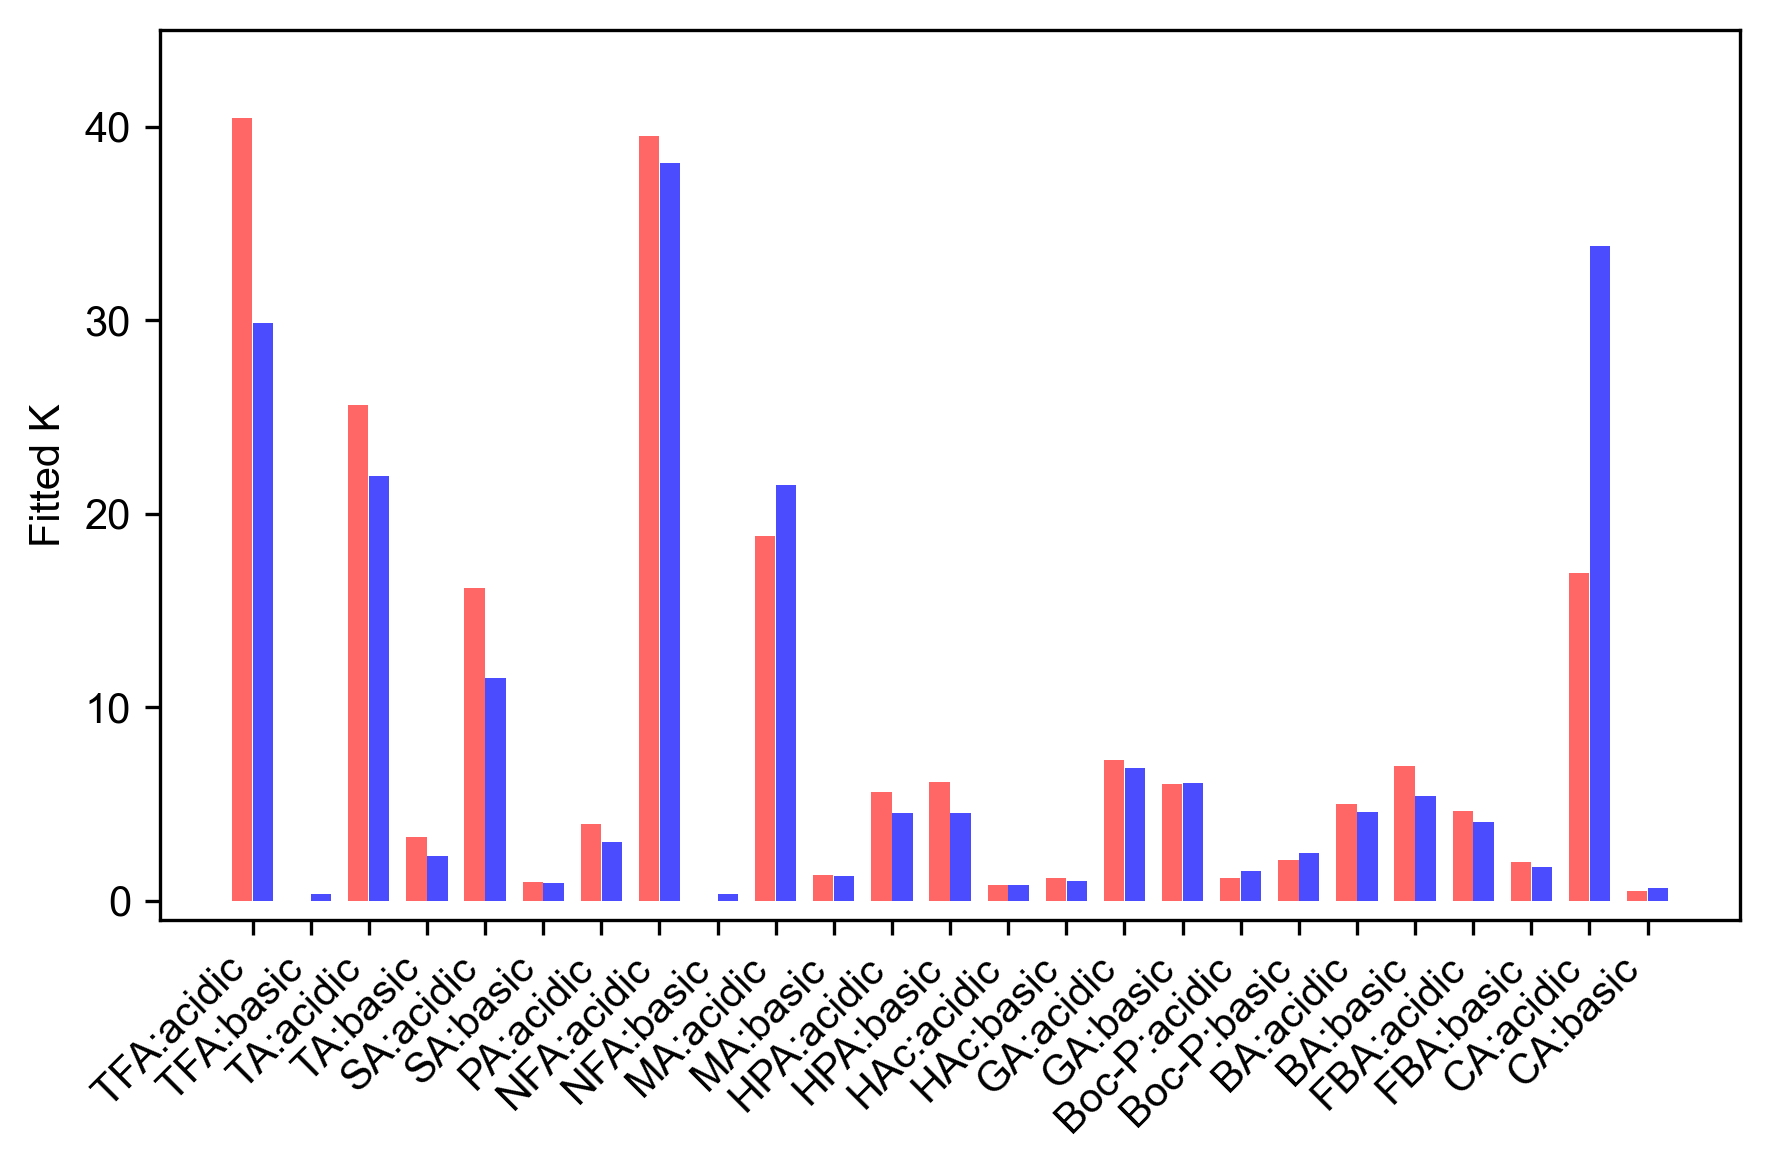

In [22]:
plt.figure(figsize=(6, 4), dpi=300)

x_pos = np.arange(len(summary_df))

# Set small offset
offset = 0.18
bar_width = 0.35

# Plot individual A values (red bars) slightly to the left
for i, A_list in enumerate(summary_df["k"].iloc[:-1]):
    a = A_list
    plt.bar(x= i - offset, height=a, width=bar_width, color="red", alpha=0.6)
    
for i, A_list in enumerate(summary_df["k"].iloc[-1:]):
    a = A_list
    i = len(summary_df["k"]) - 1
    plt.bar(x= i - offset, height=a, width=bar_width, color="red", alpha=0.6)

# Plot mean A with std (blue bars) slightly to the right
plt.bar(
    x=x_pos + offset,
    height=summary1["k"],
    width=bar_width,
    color="blue",
    alpha=0.7,
    capsize=3,
)

# Set x-axis labels
xtick_labels = summary_df["Acid"] + ":" + summary_df["Experiment"]
plt.xticks(ticks=x_pos, labels=xtick_labels, rotation=45, ha='right')

plt.ylabel("Fitted K")
plt.ylim(-1, 45)
plt.tight_layout()
plt.show()

In [23]:
modifiers = pd.read_excel("modifier.xlsx")

acids, cas = modifiers["Unnamed: 2"], modifiers["CAS"]

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# cas_to_smile = {}
# import cirpy
# for acid_temp in acids:
#     cas_num_temp = cas[acids == acid_temp].item()
#     smiles_temp = cirpy.resolve(cas_num_temp, 'smiles')
#     cas_to_smile[cas_num_temp] = smiles_temp

cas_to_smile = {
  '65-85-0': 'OC(=O)c1ccccc1',
 '445-29-4': 'OC(=O)c1ccccc1F',
 '79-14-1': 'OCC(O)=O',
 '64-19-7': 'CC(O)=O',
 '2706-90-3': 'OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F',
 '99-50-3': 'OC(=O)c1ccc(O)c(O)c1',
 '69-72-7': 'OC(=O)c1ccccc1O',
 '70-49-5': 'OC(=O)CC(S)C(O)=O',
 '76-05-1': 'OC(=O)C(F)(F)F',
 '4654-08-4': None,
 '59433-50-0': None,
 '141-82-2': 'OC(=O)CC(O)=O',
 '590-47-6': '[OH-].C[N+](C)(C)CC(O)=O',
 '498-40-8': 'NC(C[S](O)(=O)=O)C(O)=O'
 }

cas_to_smile["59433-50-0"] = 'CC(C)(C)OC(=O)N1CCCC1C(O)=O'
cas_to_smile["4654-08-4"]= 'OC(=O)CCCCc1ccc(O)cc1'

In [ ]:
cas_to_smile

{'65-85-0': 'OC(=O)c1ccccc1',
 '445-29-4': 'OC(=O)c1ccccc1F',
 '79-14-1': 'OCC(O)=O',
 '64-19-7': 'CC(O)=O',
 '2706-90-3': 'OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F',
 '99-50-3': 'OC(=O)c1ccc(O)c(O)c1',
 '69-72-7': 'OC(=O)c1ccccc1O',
 '70-49-5': 'OC(=O)CC(S)C(O)=O',
 '76-05-1': 'OC(=O)C(F)(F)F',
 '4654-08-4': 'OC(=O)CCCCc1ccc(O)cc1',
 '59433-50-0': 'CC(C)(C)OC(=O)N1CCCC1C(O)=O',
 '141-82-2': 'OC(=O)CC(O)=O',
 '590-47-6': '[OH-].C[N+](C)(C)CC(O)=O',
 '498-40-8': 'NC(C[S](O)(=O)=O)C(O)=O'}

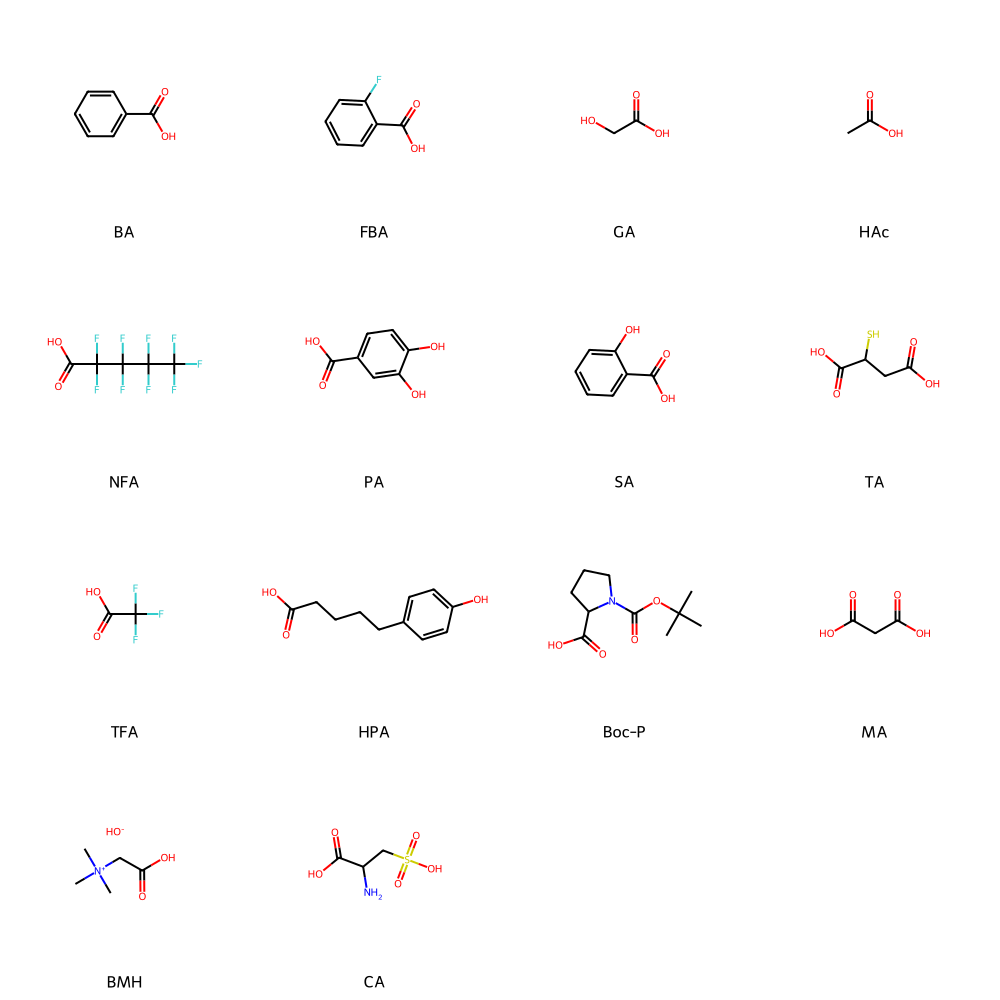

In [ ]:
# --- build a list of RDKit molecules ---
mols = []
labels = []           # optional, if you want captions
for acid in acids:    # your `acids` list
    smiles = cas_to_smile[cas[acids == acid].item()]
    if smiles is not None:
        mol = Chem.MolFromSmiles(smiles)
        Chem.rdDepictor.Compute2DCoords(mol)
        mols.append(mol)
        labels.append(acid)          # e.g. use the acid name as a label
        # img = Draw.MolToImage(mol, size=(300, 300), dpi=300)
        # display(img)  # dpi is already set inside MolToImage
        
# --- make one big image (4 × 4 grid here) ---
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,        # change grid layout as you like
    subImgSize=(250, 250),
    legends=labels       # omit if you don’t need captions
)

display(img)
# img.show()              # displays inline / opens default viewer
# img.save("all_acids.png")

In [ ]:
# searched pKa values 

cas_to_pKa = {
 '65-85-0': 4.20,
 '445-29-4': 3.27,
 '79-14-1': 3.83,
 '64-19-7': 4.76,
 '2706-90-3': 0.40,
 '99-50-3': 4.48,
 '69-72-7': 2.97,
 '70-49-5': 3.49,
 '76-05-1': 0.23,
 '4654-08-4': 4.75,
 '59433-50-0': 4.01,
 '141-82-2': 2.83,
 '590-47-6': 1.83,
 '498-40-8': 1.3
 }

In [ ]:
pKa_total = []
for acid_temp in summary_df["Acid"]:
    cas_temp = cas[acids == acid_temp].item()
    pKa_total.append((cas_to_pKa[cas_temp]))
summary_df["pKa"] = pKa_total

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Descriptors3D import PMI1  # any 3‑D descriptor import sets up 3‑D code

cas_to_volume = {}
cas_to_heavy_atoms = {}
volume_total = [] 
heavy_atom_total = []

for cas_temp, smile_temp in cas_to_smile.items():
    mol = Chem.MolFromSmiles(smile_temp)
    mol = Chem.AddHs(mol)

    # 1. Build a low‑energy conformer
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.UFFOptimizeMolecule(mol)

    # 2. Compute van der Waals volume (Å³)
    vol = AllChem.ComputeMolVolume(mol)   # defaults: vdW radii of Alvarez (2008), grid=0.2 Å
    heavy_atom_count = mol.GetNumHeavyAtoms()
    
    cas_to_volume[cas_temp] = vol
    cas_to_heavy_atoms[cas_temp] = heavy_atom_count

for acid_temp in summary_df["Acid"]:
    cas_temp = cas[acids == acid_temp].item()
    volume_total.append(cas_to_volume[cas_temp])
    heavy_atom_total.append(cas_to_heavy_atoms[cas_temp])
    
summary_df["volume"] = volume_total
summary_df["heavy_atom"] = heavy_atom_total
summary_df["f"] = summary_df["A"]/(summary_df["A"] + summary_df["B"])

summary_df["L"] = None
summary_df["B1"] = None
summary_df["B5"] = None

In [ ]:
summary_df

,Acid,Experiment,A,B,k,pKa,volume,heavy_atom,f,L,B1,B5
0,TFA,acidic,2.999279,4.087069e-01,40.457770,0.23,74.016,7,0.880074,None,None,None
1,TFA,basic,3.632548,3.008171e-08,0.005373,0.23,74.016,7,1.000000,None,None,None
2,TA,acidic,2.558390,2.015369e-01,25.636687,3.49,122.528,9,0.926977,None,None,None
3,TA,basic,2.264213,6.347594e-01,3.280415,3.49,122.528,9,0.781040,None,None,None
4,SA,acidic,2.810547,6.211158e-01,16.158399,2.97,121.536,10,0.819004,None,None,None
5,SA,basic,2.045675,1.737817e+00,1.001525,2.97,121.536,10,0.540684,None,None,None
6,PA,acidic,1.721864,5.568682e-01,3.960420,4.48,130.672,11,0.755624,None,None,None
7,NFA,acidic,3.635948,3.919866e-01,39.518878,0.40,156.632,16,0.902683,None,None,None
8,NFA,basic,3.560157,1.703961e-10,0.003856,0.40,156.632,16,1.000000,None,None,None
9,MA,acidic,2.161628,9.011571e-02,18.831399,2.83,86.840,7,0.959980,None,None,None


  COOH 1:  L=6.87  B1=1.70  B5=3.26


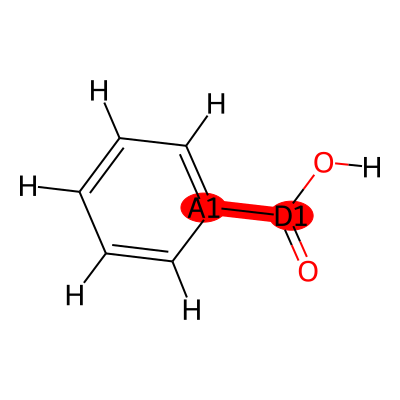

  COOH 1:  L=6.88  B1=1.70  B5=3.88


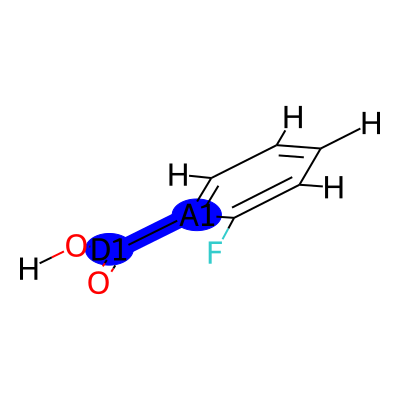

  COOH 1:  L=3.89  B1=1.70  B5=3.00


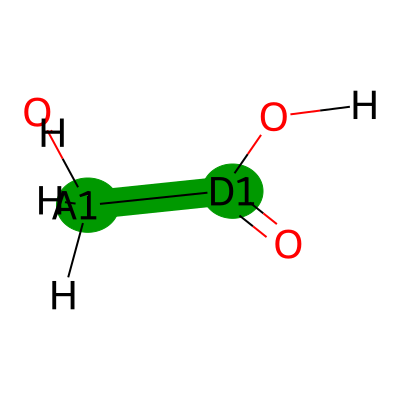

  COOH 1:  L=3.59  B1=1.70  B5=2.73


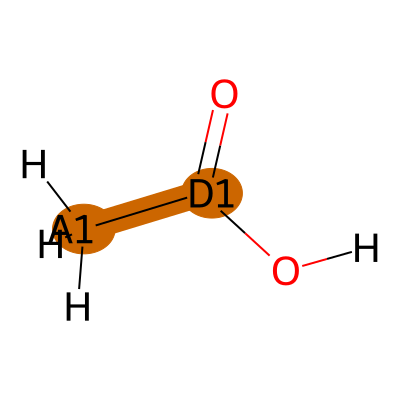

  COOH 1:  L=5.66  B1=2.15  B5=6.43


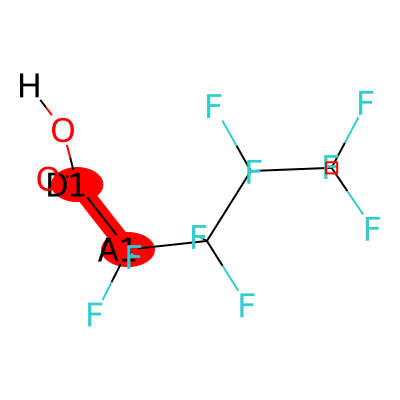

  COOH 1:  L=7.72  B1=1.70  B5=4.40


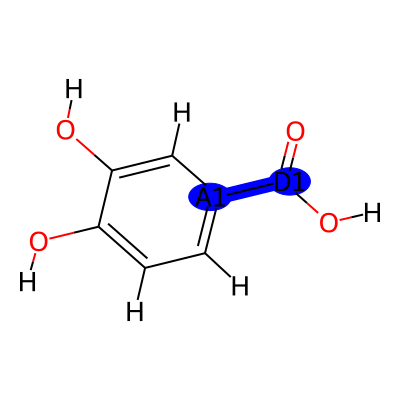

  COOH 1:  L=6.87  B1=1.98  B5=3.98


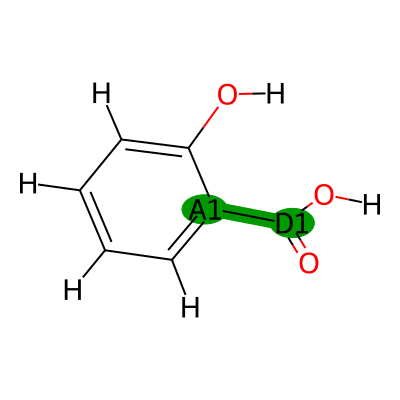

  COOH 1:  L=6.62  B1=1.70  B5=4.58
  COOH 2:  L=6.88  B1=2.40  B5=3.52


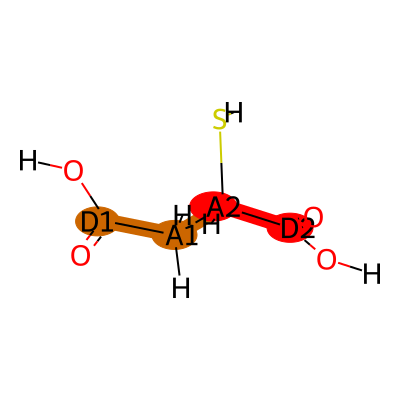

  COOH 1:  L=3.84  B1=2.12  B5=2.77


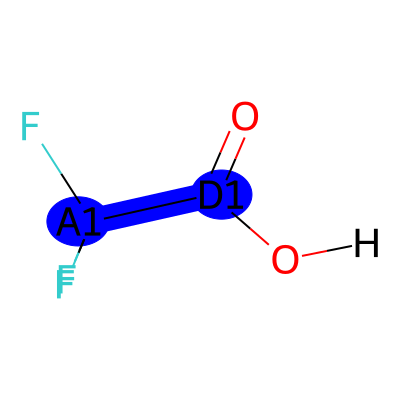

  COOH 1:  L=5.33  B1=1.70  B5=10.17


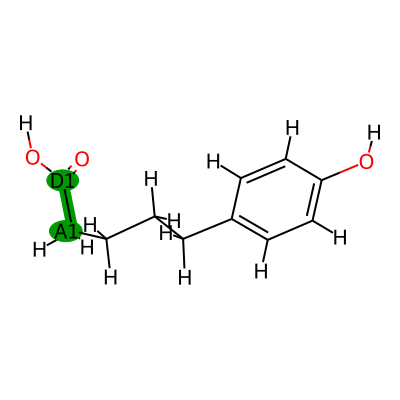

  COOH 1:  L=5.78  B1=2.36  B5=8.06


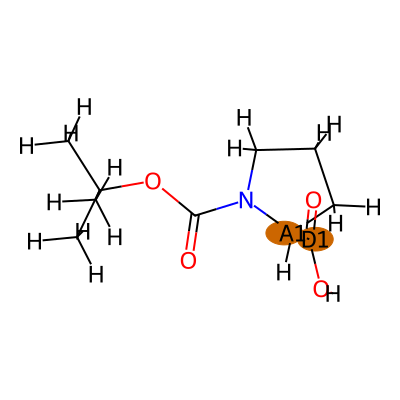

  COOH 1:  L=4.14  B1=1.70  B5=4.37
  COOH 2:  L=4.14  B1=1.70  B5=4.37


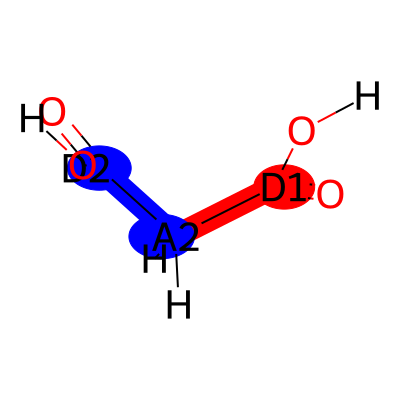

  COOH 1:  L=5.69  B1=1.70  B5=4.45


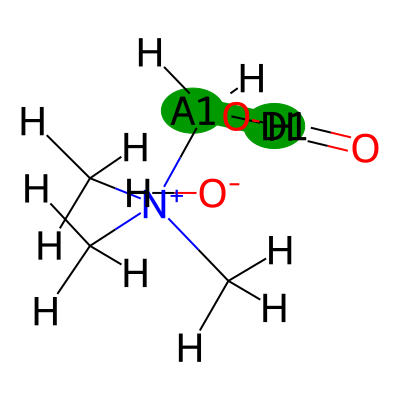

  COOH 1:  L=4.67  B1=2.02  B5=5.47


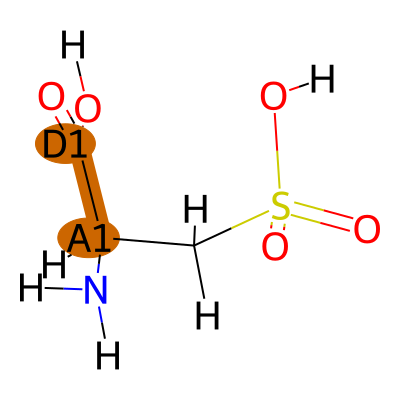

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import numpy as np
from morfeus import Sterimol
from IPython.display import Image, display
import itertools

acid_smarts = Chem.MolFromSmarts("C(=O)[O;H1]")          # –COOH pattern
color_cycle = itertools.cycle([(1,0,0), (0,0,1), (0,0.6,0), (0.8,0.4,0)])  # red, blue, green, orange
sterimol_records = {}

for cas_temp, smile_temp in cas_to_smile.items():
    mol = Chem.AddHs(Chem.MolFromSmiles(smile_temp))
    matches = mol.GetSubstructMatches(acid_smarts)
    if not matches:
        print(f"{cas_temp}: no COOH found, skipping\n")
        continue

    # build 3-D coordinates once
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.UFFOptimizeMolecule(mol)
    conf     = mol.GetConformer()
    elements = [a.GetAtomicNum() for a in mol.GetAtoms()]
    coords   = np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])

    # containers for drawing and printing
    highlight_atoms, atom_colors, atom_labels = [], {}, {}
    sterimol_records[cas_temp] = None 
    
    for idx, match in enumerate(matches, start=1):
        carbonyl_c = match[0]                               # C in C(=O)
        alpha_c = next(nbr.GetIdx() for nbr in mol.GetAtomWithIdx(carbonyl_c).GetNeighbors()
                       if nbr.GetAtomicNum() == 6 and nbr.GetIdx() != carbonyl_c)

        ster = Sterimol(elements, coords,
                        dummy_index    = carbonyl_c + 1,   # 1-based for Morfeus
                        attached_index = alpha_c    + 1)

        if sterimol_records[cas_temp]:
            sterimol_records[cas_temp].append([ster.L_value, ster.B_1_value, ster.B_5_value])
        else:
            sterimol_records[cas_temp] = [[ster.L_value, ster.B_1_value, ster.B_5_value]]

        print(           
             f"  COOH {idx}:  L={ster.L_value:.2f}  "
            f"B1={ster.B_1_value:.2f}  B5={ster.B_5_value:.2f}")
        # drawing helpers
        col = next(color_cycle)
        for at, tag in ((carbonyl_c, f"D{idx}"), (alpha_c, f"A{idx}")):
            highlight_atoms.append(at)
            atom_colors[at] = col
            atom_labels[at] = tag

    # ---- draw once per molecule ----
    drawer = Draw.MolDraw2DCairo(400, 400)
    opts = drawer.drawOptions()
    for at, lbl in atom_labels.items():      # assign labels individually
        opts.atomLabels[at] = lbl
    drawer.DrawMolecule(mol,
                        highlightAtoms=highlight_atoms,
                        highlightAtomColors=atom_colors)
    drawer.FinishDrawing()
    display(Image(data=drawer.GetDrawingText()))

In [ ]:
for key_,value_ in sterimol_records.items():
    sterimol_records[key_] = np.array(value_).mean(axis = 0)
display(summary_df)

,Acid,Experiment,A,B,k,pKa,volume,heavy_atom,f,L,B1,B5
0,TFA,acidic,2.999279,4.087069e-01,40.457770,0.23,74.016,7,0.880074,None,None,None
1,TFA,basic,3.632548,3.008171e-08,0.005373,0.23,74.016,7,1.000000,None,None,None
2,TA,acidic,2.558390,2.015369e-01,25.636687,3.49,122.528,9,0.926977,None,None,None
3,TA,basic,2.264213,6.347594e-01,3.280415,3.49,122.528,9,0.781040,None,None,None
4,SA,acidic,2.810547,6.211158e-01,16.158399,2.97,121.536,10,0.819004,None,None,None
5,SA,basic,2.045675,1.737817e+00,1.001525,2.97,121.536,10,0.540684,None,None,None
6,PA,acidic,1.721864,5.568682e-01,3.960420,4.48,130.672,11,0.755624,None,None,None
7,NFA,acidic,3.635948,3.919866e-01,39.518878,0.40,156.632,16,0.902683,None,None,None
8,NFA,basic,3.560157,1.703961e-10,0.003856,0.40,156.632,16,1.000000,None,None,None
9,MA,acidic,2.161628,9.011571e-02,18.831399,2.83,86.840,7,0.959980,None,None,None


In [ ]:
# add the sterimol parameters to the dataframe
Ls = []
B1s = []
B5s = []

for acid_temp in summary_df["Acid"]:
    cas_temp = cas[acids == acid_temp].item()
    # assign the sterimol parameters to the dataframe
    Ls.append(sterimol_records[cas_temp][0])
    B1s.append(sterimol_records[cas_temp][1])
    B5s.append(sterimol_records[cas_temp][2])

# assign the sterimol parameters to the dataframe
summary_df["L"] = Ls
summary_df["B1"] = B1s
summary_df["B5"] = B5s
summary_df["A+B"] = summary_df["A"] + summary_df["B"]

display(summary_df)

,Acid,Experiment,A,B,k,pKa,volume,heavy_atom,f,L,B1,B5,A+B
0,TFA,acidic,2.999279,4.087069e-01,40.457770,0.23,74.016,7,0.880074,3.837161,2.119826,2.773729,3.407986
1,TFA,basic,3.632548,3.008171e-08,0.005373,0.23,74.016,7,1.000000,3.837161,2.119826,2.773729,3.632548
2,TA,acidic,2.558390,2.015369e-01,25.636687,3.49,122.528,9,0.926977,6.750535,2.050676,4.053448,2.759927
3,TA,basic,2.264213,6.347594e-01,3.280415,3.49,122.528,9,0.781040,6.750535,2.050676,4.053448,2.898973
4,SA,acidic,2.810547,6.211158e-01,16.158399,2.97,121.536,10,0.819004,6.865941,1.976705,3.982123,3.431663
5,SA,basic,2.045675,1.737817e+00,1.001525,2.97,121.536,10,0.540684,6.865941,1.976705,3.982123,3.783492
6,PA,acidic,1.721864,5.568682e-01,3.960420,4.48,130.672,11,0.755624,7.719435,1.700061,4.401963,2.278732
7,NFA,acidic,3.635948,3.919866e-01,39.518878,0.40,156.632,16,0.902683,5.662479,2.153604,6.426410,4.027935
8,NFA,basic,3.560157,1.703961e-10,0.003856,0.40,156.632,16,1.000000,5.662479,2.153604,6.426410,3.560157
9,MA,acidic,2.161628,9.011571e-02,18.831399,2.83,86.840,7,0.959980,4.138747,1.700000,4.365556,2.251744


### Deal with acid conditions

,Acid,Experiment,A,B,k,pKa,volume,heavy_atom,f,L,B1,B5,A+B
0,TFA,acidic,2.999279,4.087069e-01,40.457770,0.23,74.016,7,0.880074,3.837161,2.119826,2.773729,3.407986
2,TA,acidic,2.558390,2.015369e-01,25.636687,3.49,122.528,9,0.926977,6.750535,2.050676,4.053448,2.759927
4,SA,acidic,2.810547,6.211158e-01,16.158399,2.97,121.536,10,0.819004,6.865941,1.976705,3.982123,3.431663
6,PA,acidic,1.721864,5.568682e-01,3.960420,4.48,130.672,11,0.755624,7.719435,1.700061,4.401963,2.278732
7,NFA,acidic,3.635948,3.919866e-01,39.518878,0.40,156.632,16,0.902683,5.662479,2.153604,6.426410,4.027935
9,MA,acidic,2.161628,9.011571e-02,18.831399,2.83,86.840,7,0.959980,4.138747,1.700000,4.365556,2.251744
11,HPA,acidic,2.061486,1.042598e+00,5.629201,4.75,189.648,14,0.664121,5.328644,1.700000,10.166941,3.104084
13,HAc,acidic,2.154912,1.141143e+00,0.827734,4.76,57.728,4,0.653785,3.591054,1.700000,2.725687,3.296055
15,GA,acidic,3.229689,2.478370e-01,7.297228,3.83,66.624,5,0.928732,3.894526,1.700000,2.998439,3.477526
17,Boc-P,acidic,1.692154,1.433684e+00,1.183433,4.01,207.376,15,0.541344,5.783335,2.360542,8.064018,3.125838


,pKa,volume,heavy_atom,L,B1,B5,A+B,k,f
pKa,0.000000,0.752618,0.654725,0.383489,5.574507e-02,0.704964,6.675238e-02,0.000068,0.025829
volume,0.752618,0.000000,0.000002,0.109828,1.166251e-01,0.000038,8.393236e-01,0.680718,0.124154
heavy_atom,0.654725,0.000002,0.000000,0.090340,8.699575e-02,0.000782,6.623386e-01,0.733269,0.309952
L,0.383489,0.109828,0.090340,0.000000,9.865606e-01,0.714921,4.306317e-01,0.520472,0.494674
B1,0.055745,0.116625,0.086996,0.986561,8.559986e-86,0.352021,2.694781e-01,0.081752,0.935136
B5,0.704964,0.000038,0.000782,0.714921,3.520209e-01,0.000000,8.546069e-01,0.696052,0.173947
A+B,0.066752,0.839324,0.662339,0.430632,2.694781e-01,0.854607,8.559986e-86,0.439056,0.365612
k,0.000068,0.680718,0.733269,0.520472,8.175217e-02,0.696052,4.390560e-01,0.000000,0.021498
f,0.025829,0.124154,0.309952,0.494674,9.351360e-01,0.173947,3.656121e-01,0.021498,0.000000


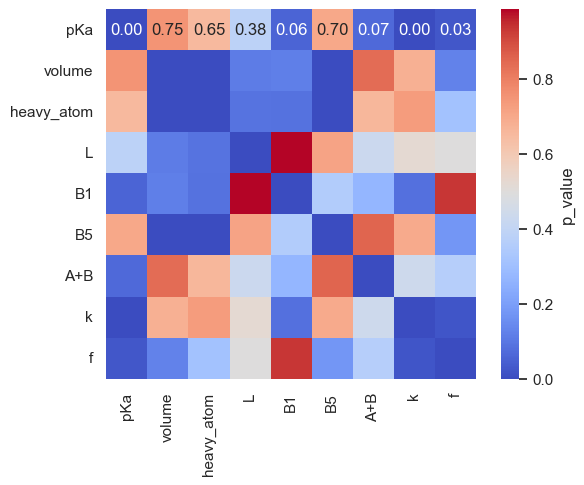

In [ ]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import seaborn as sns

sns.set(font="Arial")

mask = (summary_df["Experiment"] == "acidic")

cols = ["pKa", "volume", "heavy_atom", "L", "B1", "B5", "A+B", "k", "f"]
corr_P  = (summary_df.loc[mask])[cols].corr(method="pearson")    # linear    (–1 … +1)
corr_S  =  (summary_df.loc[mask])[cols].corr(method="spearman")   # monotonic (–1 … +1)

display(summary_df.loc[mask])

# Optional: p‑values for the Pearson coefficients
pvals = pd.DataFrame(
    [[stats.pearsonr((summary_df.loc[mask])[a],  (summary_df.loc[mask])[b]).pvalue for b in cols] for a in cols],
    columns=cols, index=cols
)

sns.heatmap(pvals, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"label": "p_value"})
display(pvals)
plt.show()

### deal with A + B

[[3.40798637]
 [2.75992663]
 [3.431663  ]
 [2.27873207]
 [4.02793458]
 [2.25174357]
 [3.10408412]
 [3.29605522]
 [3.47752647]
 [3.12583834]
 [3.44285206]
 [3.32212931]
 [4.91206751]]


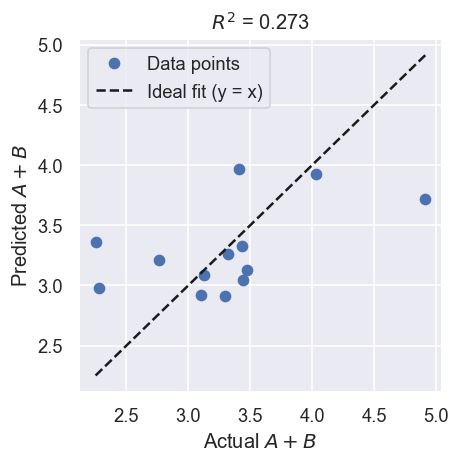

In [ ]:
X = (summary_df.loc[mask])[["pKa"]].values
y = (summary_df.loc[mask])[["A+B"]].values

print(y)
# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict using the trained model
y_pred = model.predict(X)

# Plot: predicted vs actual
r2 = r2_score(y, y_pred)
plt.figure(figsize=(4, 4), dpi=120)
plt.plot(y, y_pred, 'o', label="Data points")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label="Ideal fit (y = x)")
plt.xlabel("Actual $A+B$")
plt.ylabel("Predicted $A+B$")
plt.title("Prediction vs Actual")
plt.legend()
plt.tight_layout()
plt.title(f"$R^2$ = {r2:.3f}")
plt.show()

### deal with K vs pKa, or B1

[[40.45776999]
 [25.63668728]
 [16.15839855]
 [ 3.96042016]
 [39.51887831]
 [18.83139934]
 [ 5.62920138]
 [ 0.82773358]
 [ 7.29722799]
 [ 1.18343333]
 [ 5.0260026 ]
 [ 4.62866233]
 [16.94733388]]


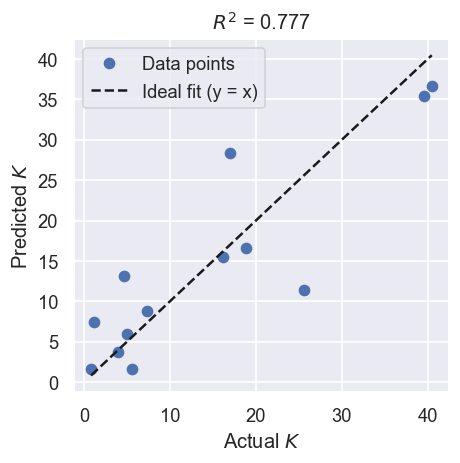

In [ ]:
X = (summary_df.loc[mask])[["pKa"]].values
y = (summary_df.loc[mask])[["k"]].values

print(y)
# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict using the trained model
y_pred = model.predict(X)

# Plot: predicted vs actual
r2 = r2_score(y, y_pred)
plt.figure(figsize=(4, 4), dpi=120)
plt.plot(y, y_pred, 'o', label="Data points")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label="Ideal fit (y = x)")
plt.xlabel("Actual $K$")
plt.ylabel("Predicted $K$")
plt.title("Prediction vs Actual")
plt.legend()
plt.tight_layout()
plt.title(f"$R^2$ = {r2:.3f}")
plt.show()

### deal with f

[[0.88007378]
 [0.92697745]
 [0.81900443]
 [0.75562368]
 [0.90268298]
 [0.95997959]
 [0.66412053]
 [0.65378512]
 [0.92873181]
 [0.54134404]
 [0.78144765]
 [0.75776389]
 [1.        ]]


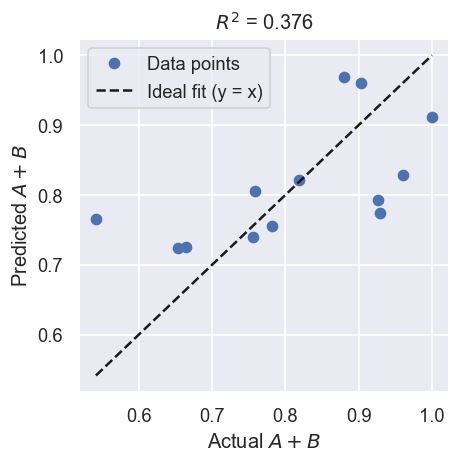

In [ ]:
X = (summary_df.loc[mask])[["pKa"]].values
y = (summary_df.loc[mask])[["f"]].values

print(y)
# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict using the trained model
y_pred = model.predict(X)

# Plot: predicted vs actual
r2 = r2_score(y, y_pred)
plt.figure(figsize=(4, 4), dpi=120)
plt.plot(y, y_pred, 'o', label="Data points")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label="Ideal fit (y = x)")
plt.xlabel("Actual $A+B$")
plt.ylabel("Predicted $A+B$")
plt.title("Prediction vs Actual")
plt.legend()
plt.tight_layout()
plt.title(f"$R^2$ = {r2:.3f}")
plt.show()

### Deal with basic conditions

,Acid,Experiment,A,B,k,pKa,volume,heavy_atom,f,L,B1,B5,A+B
1,TFA,basic,3.632548,3.008171e-08,0.005373,0.23,74.016,7,1.000000,3.837161,2.119826,2.773729,3.632548
3,TA,basic,2.264213,6.347594e-01,3.280415,3.49,122.528,9,0.781040,6.750535,2.050676,4.053448,2.898973
5,SA,basic,2.045675,1.737817e+00,1.001525,2.97,121.536,10,0.540684,6.865941,1.976705,3.982123,3.783492
8,NFA,basic,3.560157,1.703961e-10,0.003856,0.40,156.632,16,1.000000,5.662479,2.153604,6.426410,3.560157
10,MA,basic,1.811833,1.219893e+00,1.322078,2.83,86.840,7,0.597624,4.138747,1.700000,4.365556,3.031726
12,HPA,basic,2.447286,9.627896e-01,6.132335,4.75,189.648,14,0.717663,5.328644,1.700000,10.166941,3.410076
14,HAc,basic,2.850119,6.382662e-01,1.196755,4.76,57.728,4,0.817031,3.591054,1.700000,2.725687,3.488385
16,GA,basic,4.107251,4.197356e-02,6.036039,3.83,66.624,5,0.989884,3.894526,1.700000,2.998439,4.149225
18,Boc-P,basic,1.297312,1.954441e+00,2.121178,4.01,207.376,15,0.398958,5.783335,2.360542,8.064018,3.251752
20,BA,basic,2.790146,9.444301e-01,6.986317,4.20,112.648,9,0.747112,6.873292,1.700428,3.262468,3.734576


,pKa,volume,heavy_atom,L,B1,B5,A+B,k
pKa,0.000000,0.796880,0.595150,0.607196,0.090212,0.673231,0.357065,0.014880
volume,0.796880,0.000000,0.000006,0.103995,0.106979,0.000065,0.558098,0.771745
heavy_atom,0.595150,0.000006,0.000000,0.097123,0.071533,0.001047,0.730771,0.852259
L,0.607196,0.103995,0.097123,0.000000,0.663886,0.627271,0.740872,0.510103
B1,0.090212,0.106979,0.071533,0.663886,0.000000,0.384482,0.451030,0.085866
B5,0.673231,0.000065,0.001047,0.627271,0.384482,0.000000,0.532425,0.662062
A+B,0.357065,0.558098,0.730771,0.740872,0.451030,0.532425,0.000000,0.293224
k,0.014880,0.771745,0.852259,0.510103,0.085866,0.662062,0.293224,0.000000


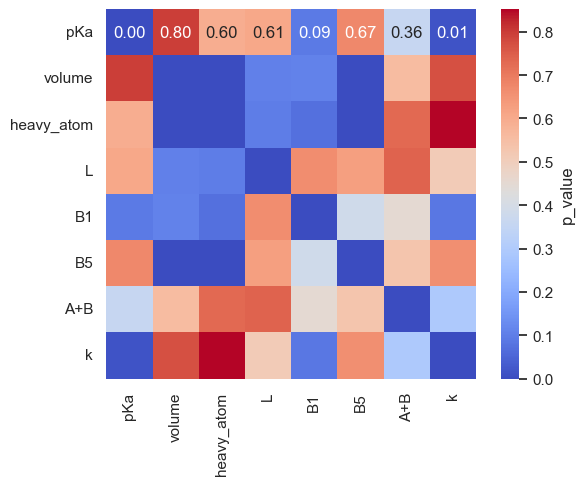

In [ ]:
mask = (summary_df["Experiment"] == "basic")
# mask = mask * (summary_df["k"] >0.1) # ensure the f is sensible
cols = ["pKa", "volume", "heavy_atom", "L", "B1", "B5", "A+B", "k"]
corr_P  = (summary_df.loc[mask])[cols].corr(method="pearson")    # linear    (–1 … +1)
corr_S  =  (summary_df.loc[mask])[cols].corr(method="spearman")   # monotonic (–1 … +1)

display(summary_df.loc[mask])

# Optional: p‑values for the Pearson coefficients
pvals = pd.DataFrame(
    [[stats.pearsonr((summary_df.loc[mask])[a],  (summary_df.loc[mask])[b]).pvalue for b in cols] for a in cols],
    columns=cols, index=cols
)

sns.heatmap(pvals, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"label": "p_value"})
display(pvals)
plt.show()

[[5.37335070e-03]
 [3.28041523e+00]
 [1.00152524e+00]
 [3.85588628e-03]
 [1.32207757e+00]
 [6.13233516e+00]
 [1.19675538e+00]
 [6.03603928e+00]
 [2.12117816e+00]
 [6.98631681e+00]
 [1.99704213e+00]
 [5.25359621e-01]]


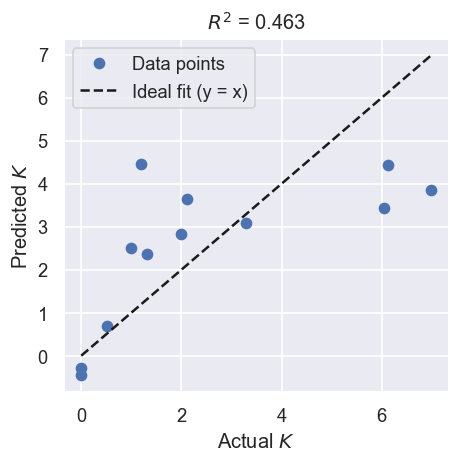

In [ ]:
X = (summary_df.loc[mask])[["pKa"]].values
y = (summary_df.loc[mask])[["k"]].values

print(y)
# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict using the trained model
y_pred = model.predict(X)

# Plot: predicted vs actual
r2 = r2_score(y, y_pred)
plt.figure(figsize=(4, 4), dpi=120)
plt.plot(y, y_pred, 'o', label="Data points")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label="Ideal fit (y = x)")
plt.xlabel("Actual $K$")
plt.ylabel("Predicted $K$")
plt.title("Prediction vs Actual")
plt.legend()
plt.tight_layout()
plt.title(f"$R^2$ = {r2:.3f}")
plt.show()

# # Predict using the trained model
# y_pred = model.predict(X)

# # Step 3: Create grid
# pKa_range = np.linspace(X[:,0].min()*0.9, X[:,0].max()*1.1, 100)
# vol_range = np.linspace(X[:,1].min()*0.9, X[:,1].max()*1.1, 100)
# pKa_grid, vol_grid = np.meshgrid(pKa_range, vol_range)
# X_grid = np.c_[pKa_grid.ravel(), vol_grid.ravel()]

# # Step 4: Predict on grid
# f_grid = model.predict(X_grid).reshape(pKa_grid.shape)

# # Step 5: Plot
# plt.figure(figsize=(5, 4), dpi=150)
# contour = plt.contourf(pKa_grid, vol_grid, f_grid, levels=15, cmap='coolwarm')
# plt.colorbar(contour, label="$f$")
# plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', alpha =1, s=50)
# plt.xlabel("pKa")
# plt.ylabel("B1")
# plt.tight_layout()
# plt.show()


### deal with f

,Acid,Experiment,A,B,k,pKa,volume,heavy_atom,f,L,B1,B5,A+B
3,TA,basic,2.264213,0.634759,3.280415,3.49,122.528,9,0.781040,6.750535,2.050676,4.053448,2.898973
5,SA,basic,2.045675,1.737817,1.001525,2.97,121.536,10,0.540684,6.865941,1.976705,3.982123,3.783492
10,MA,basic,1.811833,1.219893,1.322078,2.83,86.840,7,0.597624,4.138747,1.700000,4.365556,3.031726
12,HPA,basic,2.447286,0.962790,6.132335,4.75,189.648,14,0.717663,5.328644,1.700000,10.166941,3.410076
14,HAc,basic,2.850119,0.638266,1.196755,4.76,57.728,4,0.817031,3.591054,1.700000,2.725687,3.488385
16,GA,basic,4.107251,0.041974,6.036039,3.83,66.624,5,0.989884,3.894526,1.700000,2.998439,4.149225
18,Boc-P,basic,1.297312,1.954441,2.121178,4.01,207.376,15,0.398958,5.783335,2.360542,8.064018,3.251752
20,BA,basic,2.790146,0.944430,6.986317,4.20,112.648,9,0.747112,6.873292,1.700428,3.262468,3.734576
22,FBA,basic,2.602636,0.999670,1.997042,3.27,117.992,10,0.722492,6.879204,1.700134,3.880429,3.602306
24,CA,basic,0.733207,0.060349,0.525360,1.30,131.088,10,0.923951,4.674520,2.020445,5.472956,0.793556


,pKa,volume,heavy_atom,L,B1,B5,A+B,f
pKa,0.000000,8.660828e-01,9.964039e-01,9.367146e-01,0.447248,6.647350e-01,0.015278,0.722917
volume,0.866083,1.701606e-61,9.012838e-08,2.162660e-01,0.061882,6.307406e-04,0.600082,0.088276
heavy_atom,0.996404,9.012838e-08,0.000000e+00,1.266984e-01,0.087886,1.976536e-03,0.632318,0.072025
L,0.936715,2.162660e-01,1.266984e-01,1.063504e-62,0.434704,8.880139e-01,0.649933,0.257177
B1,0.447248,6.188151e-02,8.788612e-02,4.347038e-01,0.000000,3.278521e-01,0.298774,0.146070
B5,0.664735,6.307406e-04,1.976536e-03,8.880139e-01,0.327852,1.063504e-62,0.578809,0.258183
A+B,0.015278,6.000816e-01,6.323178e-01,6.499329e-01,0.298774,5.788092e-01,0.000000,0.556212
f,0.722917,8.827578e-02,7.202465e-02,2.571769e-01,0.146070,2.581831e-01,0.556212,0.000000


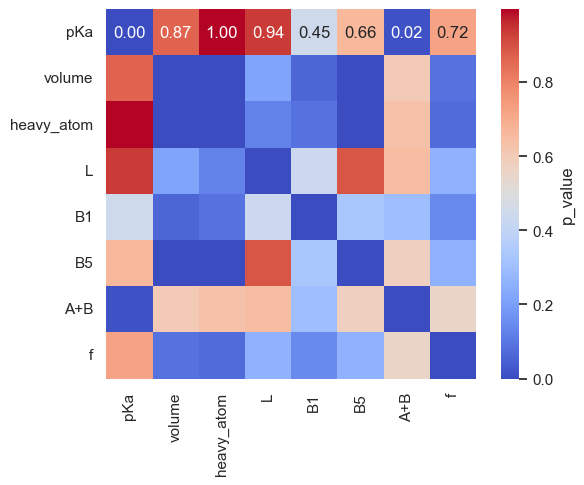

In [ ]:
mask = (summary_df["Experiment"] == "basic")
mask = mask * (summary_df["k"] >0.1) # ensure the f is sensible
cols = ["pKa", "volume", "heavy_atom", "L", "B1", "B5", "A+B", "f"]
corr_P  = (summary_df.loc[mask])[cols].corr(method="pearson")    # linear    (–1 … +1)
corr_S  =  (summary_df.loc[mask])[cols].corr(method="spearman")   # monotonic (–1 … +1)

display(summary_df.loc[mask])

# Optional: p‑values for the Pearson coefficients
pvals = pd.DataFrame(
    [[stats.pearsonr((summary_df.loc[mask])[a],  (summary_df.loc[mask])[b]).pvalue for b in cols] for a in cols],
    columns=cols, index=cols
)

sns.heatmap(pvals, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"label": "p_value"})
display(pvals)
plt.show()

[[0.78103989]
 [0.54068431]
 [0.59762423]
 [0.71766328]
 [0.81703104]
 [0.989884  ]
 [0.39895766]
 [0.74711181]
 [0.72249164]
 [0.92395111]]


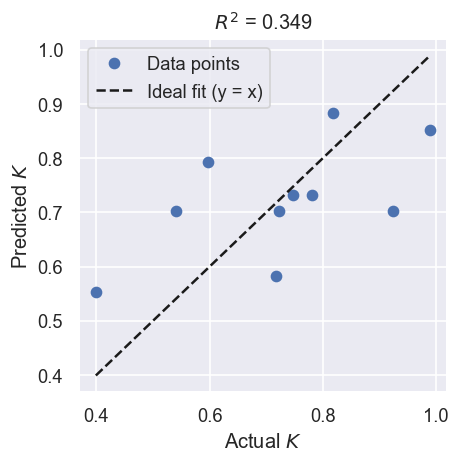

In [ ]:
X = (summary_df.loc[mask])[["heavy_atom"]].values
y = (summary_df.loc[mask])[["f"]].values

print(y)
# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict using the trained model
y_pred = model.predict(X)

# Plot: predicted vs actual
r2 = r2_score(y, y_pred)
plt.figure(figsize=(4, 4), dpi=120)
plt.plot(y, y_pred, 'o', label="Data points")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label="Ideal fit (y = x)")
plt.xlabel("Actual $K$")
plt.ylabel("Predicted $K$")
plt.title("Prediction vs Actual")
plt.legend()
plt.tight_layout()
plt.title(f"$R^2$ = {r2:.3f}")
plt.show()

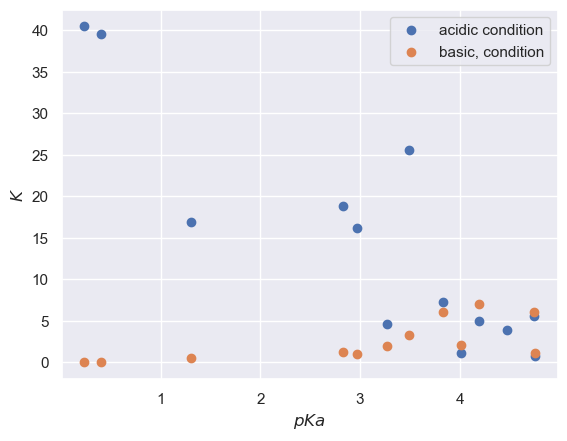

In [ ]:
mask = (summary_df["Experiment"] == "acidic")

plt.scatter(summary_df.loc[mask]["pKa"], summary_df.loc[mask]["k"], label = "acidic condition")
plt.scatter(summary_df.loc[~mask]["pKa"], summary_df.loc[~mask]["k"], label = "basic, condition")
plt.xlabel("$pKa$")
plt.ylabel("$K$")
plt.legend()

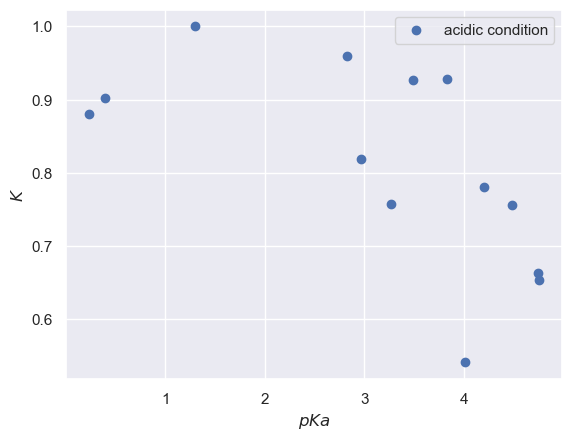

In [ ]:
mask = (summary_df["Experiment"] == "acidic")
plt.scatter(summary_df.loc[mask]["pKa"], summary_df.loc[mask]["f"], label = "acidic condition")
plt.xlabel("$pKa$")
plt.ylabel("$K$")
plt.legend()
plt.show()

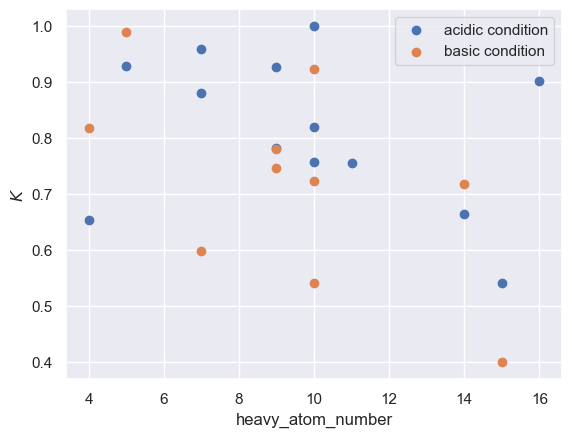

In [ ]:

mask = (summary_df["Experiment"] == "acidic")
plt.scatter(summary_df.loc[mask]["heavy_atom"], summary_df.loc[mask]["f"], label = "acidic condition")
plt.xlabel("$pKa$")
plt.ylabel("$K$")
plt.legend()


mask = (summary_df["Experiment"] == "basic")
mask = mask * (summary_df["k"] >0.1) # ensure the f is sensible
plt.scatter(summary_df.loc[mask]["heavy_atom"], summary_df.loc[mask]["f"], label = "basic condition")
plt.xlabel("heavy_atom_number")
plt.ylabel("$K$")
plt.legend()

In [ ]:
summary_df.to_csv("summary_df.csv")